# 1 — Single spin thermal protocol

Caso mínimo del protocolo de Lloyd–Abanin: un qubit de sistema acoplado cíclicamente a un qubit de baño reseteable. Es el banco metodológico, donde sí podemos diagonalizar el canal entero, leer su segundo autovalor y separar limpiamente poblaciones y coherencias en la base de energía — cosas que dejan de ser viables en sistemas más grandes.

Estructura en cuatro capas:

- **A.** Canal exacto y punto fijo vía superoperador. Operadores de acoplo, ventana temporal del filtro, resonancias, randomización, rewind, escalado $\theta^2$ y termodinámica.
- **B.** Implementación en Qiskit ideal, transpilación a puertas nativas y validación frente al exacto.
- **C.** Circuitos dinámicos compilados contra `FakeSherbrooke`, con medida y reset mid-circuit, observables reconstruidos por shots.
- **D.** Misma pipeline ISA con modelos depolarizantes y con el ruido calibrado del backend, para localizar la ventana operativa y evaluar hasta qué punto la implementación sigue siendo físicamente interpretable en un marco NISQ.


Observables que seguimos a lo largo del notebook: energía, distancia traza a Gibbs, fidelidad, poblaciones y coherencias en base de energía, y la excitación del baño antes del reset.

In [ ]:
# Add the project source tree to Python's import path
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", PROJECT_ROOT)
print("Source:", SRC)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, FixedFormatter

from IPython.display import display, Markdown

from tfm_shared.core import *
from tfm_shared.plots import *
from tfm_shared.qiskit_impl import *
from tfm_single_spin.model import *

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 120

Project root: C:\Users\paula\Desktop\tfm
sys.path[0]: C:\Users\paula\Desktop\tfm
Funciones Qiskit cargadas.


## 1. Introducción física

Estudiamos el caso mínimo del protocolo de preparación térmica: un qubit de sistema acoplado cíclicamente a un qubit auxiliar que actúa como baño reseteable.

Los Hamiltonianos del sistema y del baño son

$$
H_S = -\frac{g}{2} Z,
\qquad
H_B = -\frac{h}{2} Z.
$$

Durante cada ciclo, sistema y baño evolucionan conjuntamente bajo una interacción local

$$
V(\tau) = \theta f_\tau A_S \otimes A_B,
$$

donde $f_\tau$ es un filtro temporal gaussiano que modula el acoplo. Después de la evolución, el baño se mide o se descarta y se reinicializa. El efecto neto sobre el sistema es un canal discreto

$$
\rho_{r+1} = \Phi(\rho_r),
$$

cuyo punto fijo \(\rho_{\rm fp}\) debe aproximar el estado de Gibbs

$$
\rho_\beta = \frac{e^{-\beta H_S}}{\operatorname{Tr}(e^{-\beta H_S})}.
$$

En este notebook se usa el single spin como banco de pruebas para:

1. comprobar que el canal converge al mismo atractor desde estados iniciales muy distintos (mezcla y $|+\rangle$);
2. caracterizar el papel de $A_S$ y $A_B$, separando thermalización, dephasing puro y dinámica no disipativa;
3. localizar las resonancias $T\omega = k\pi$ y ver cómo las suprime la randomización (y, comparativamente, el rewind del paper de Hahn);
4. verificar el escalado $\|\rho_{\rm fp}-\rho_\beta\| \sim \theta^2$;
5. recorrer los regímenes de $\theta$ — perturbativo, intermedio, fuerte — vía $n^*(\theta,\beta)$, junto con la capacidad calorífica;
6. trasladar a Qiskit: circuito explícito, validación frente al exacto, coste en puertas nativas, shots con circuitos dinámicos en `FakeSherbrooke` y degradación bajo ruido.

La capa exacta da los resultados físicos. La capa Qiskit valida implementabilidad y mide recursos.

In [3]:
# ------------------------------------------------------------------
# Parámetros base del notebook
# ------------------------------------------------------------------
base_single_params = dict(
    g=1.0,
    h=1.0,
    beta=1.0,
    theta=0.15,
    delta=0.08,
    MT=30,
    n_cycles=150,
    sys_A= "ZYmix",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    seed=1234,
    rewind=False,
)

# Estados iniciales típicos
ket_0  = np.array([1, 0], dtype=complex)
ket_1  = np.array([0, 1], dtype=complex)
ket_p  = np.array([1, 1], dtype=complex) / np.sqrt(2)
ket_m  = np.array([1, -1], dtype=complex) / np.sqrt(2)
ket_pi = np.array([1, 1j], dtype=complex) / np.sqrt(2)
ket_mi = np.array([1, -1j], dtype=complex) / np.sqrt(2)

initial_states = {
    "|0><0|":   pure_dm(ket_0),
    "|1><1|":   pure_dm(ket_1),
    "|+><+|":   pure_dm(ket_p),
    "I/2":      maximally_mixed(1),
}

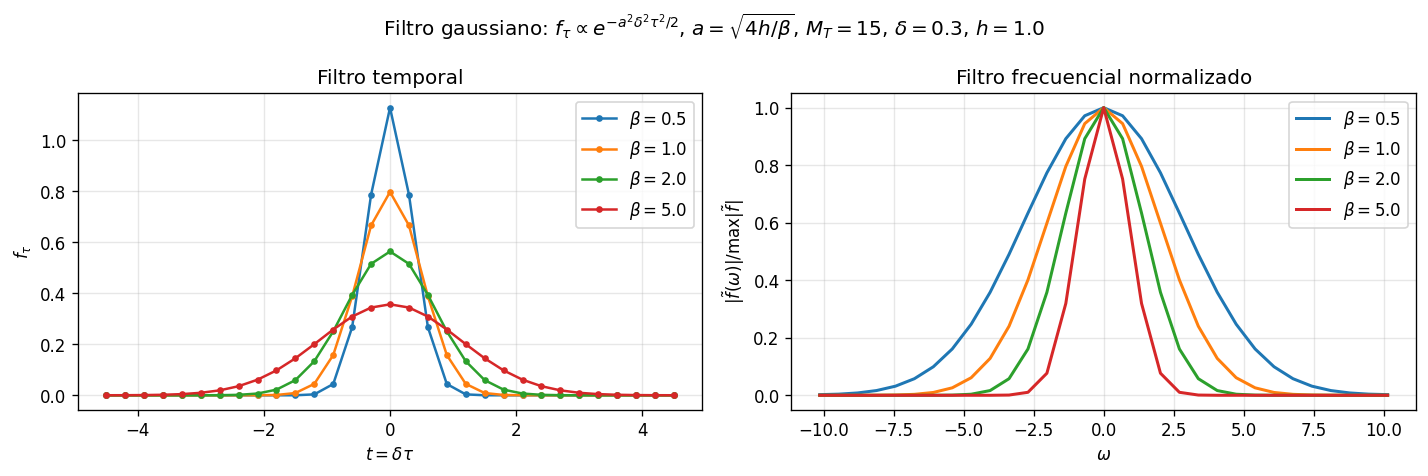

In [3]:
plot_filter_time_frequency_from_cfg(
    base_single_params,
    betas=(0.5, 1.0, 2.0, 5.0),
    MT=15,
    delta=0.3,
    h_filter=1.0,
)

Al aumentar $\beta$, disminuye $a=\sqrt{4h/\beta}$. Por tanto, el filtro se ensancha en tiempo y se estrecha en frecuencia. Físicamente, temperaturas más bajas requieren mayor resolución energética, lo que exige ventanas temporales más largas.

### Caso de referencia y objetos básicos

Antes de entrar en los barridos y comparaciones, fijamos un caso de referencia y construimos explícitamente el Hamiltoniano del sistema, el estado de Gibbs y el punto fijo del canal. Esta celda sirve como ancla para todo el notebook.

In [3]:
rho0_mm = maximally_mixed(1)

out_single = run_single_spin_case(
    base_single_params,
    rho0=rho0_mm,
    compute_fp=True,
    fp_mode="superop",
)

compiled_single = out_single["compiled"]
cfg_single = out_single["cfg"]
Hs_single = out_single["Hs"]
rho_g_single = out_single["rho_g"]
rho_fp_single = out_single["rho_fp"]


print("\nE_Gibbs =", out_single["Eg"])
print("E_fp    =", out_single["Efp"])
print("E_final =", out_single["Efinal"])
print("|E_fp - E_Gibbs| =", abs(out_single["Efp"] - out_single["Eg"]))
print("|E_final - E_Gibbs| =", abs(out_single["Efinal"] - out_single["Eg"]))


E_Gibbs = -0.23105857863000492
E_fp    = -0.23163649839125167
E_final = -0.20887455604634872
|E_fp - E_Gibbs| = 0.0005779197612467424
|E_final - E_Gibbs| = 0.022184022583656204


# A. Capa exacta

## A.1 Dashboards del canal exacto

### A.1.1 Visión global desde varios estados iniciales

Antes de mirar coherencias en detalle, lanzamos el canal desde varios $\rho_0$ y comparamos energía y distancia traza a Gibbs en una sola figura. Esto contesta tres cosas a la vez: cuánto depende la trayectoria del estado inicial, si todos los $\rho_0$ caen en el mismo atractor, y cuáles arrastran coherencias visibles en el transitorio. 

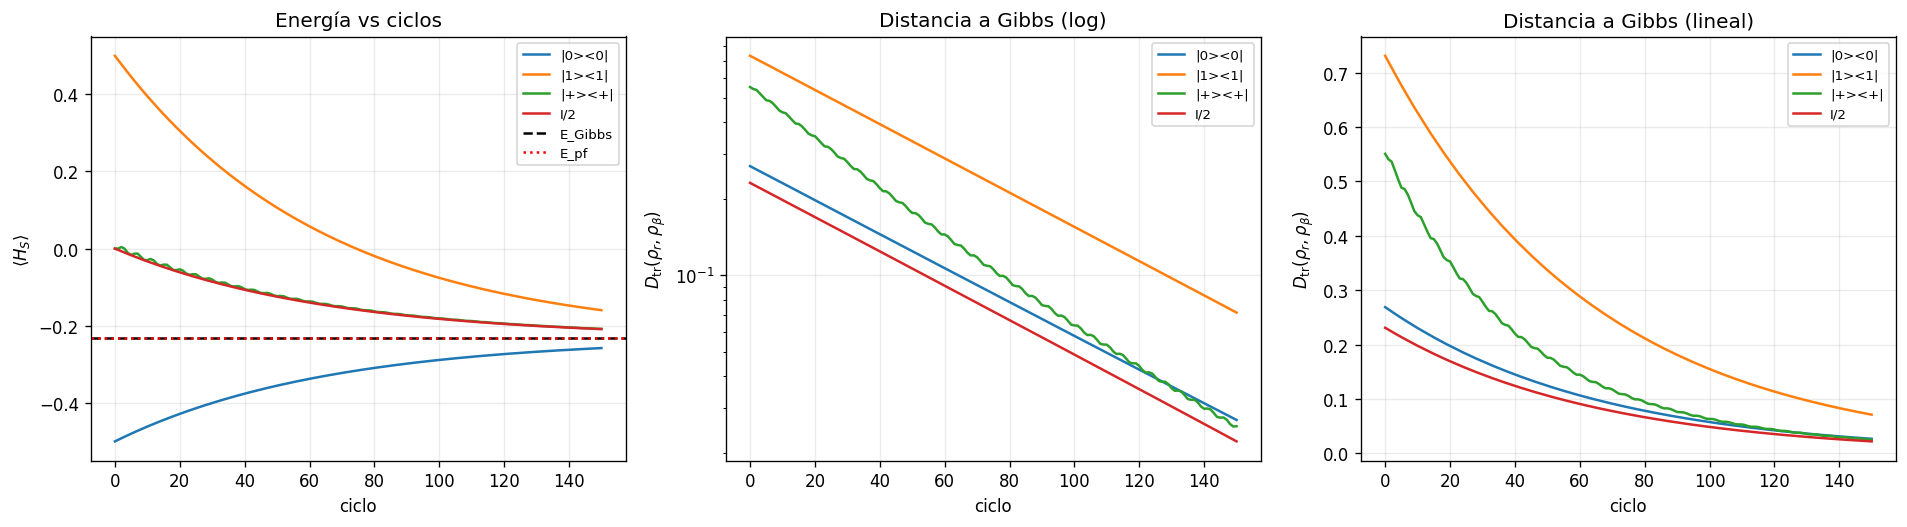

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
steps = np.arange(base_single_params["n_cycles"] + 1)

for name, rho0 in initial_states.items():
    out = run_single_spin_case(base_single_params, rho0=rho0, compute_fp=True, fp_mode="superop")
    res = out["res"]
    dists = [trace_distance_dm(rho, out["rho_g"]) for rho in res["rhos"]]

    axes[0].plot(steps, res["energies"], label=name)
    axes[1].plot(steps, dists, label=name)
    axes[2].plot(steps, dists, label=name)

axes[0].axhline(expect(Hs_single, rho_g_single), ls="--", color="k", label="E_Gibbs")
axes[0].axhline(expect(Hs_single, rho_fp_single), ls=":", color="red", label="E_pf")

axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$\langle H_S\rangle$")
axes[0].set_title("Energía vs ciclos")

axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho_r,\rho_\beta)$")
axes[1].set_title("Distancia a Gibbs (log)")
axes[1].set_yscale("log")

axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$D_{\rm tr}(\rho_r,\rho_\beta)$")
axes[2].set_title("Distancia a Gibbs (lineal)")

for ax in axes:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### A.1.2 Caso detallado desde $\rho_0 = I/2$

Caso estándar para seguir la parte poblacional. Como $I/2$ no tiene coherencias en la base computacional, la trayectoria muestra de forma limpia el enfriamiento energético, la cercanía a Gibbs, el sesgo entre punto fijo y Gibbs y la lectura del baño justo antes del reset. Funciona como dashboard exacto principal del notebook.

En la base propia de $H_S$, $\rho^{(E)} = U_E^\dagger \rho\, U_E$ separa explícitamente poblaciones y coherencias. 

REPORTE: single spin desde I/2
Hs terms     : [(-0.5, {0: 'Z'})]
beta         : 1.0
theta        : 0.15
delta        : 0.08
MT           : 30
n_cycles     : 150
fp method    : superop
--------------------------------------------------------------------------------


,label,n_sys,n_bath,beta,theta,delta,MT,n_cycles,E0,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)",PopErr(fp),CohErr(fp)
0,single spin desde I/2,1,1,1.0,0.15,0.08,30,150,0.0,-0.208875,-0.231059,-0.231636,0.022184,0.000578,0.999389,0.022196,0.999999,0.000853,0.001156,0.000888


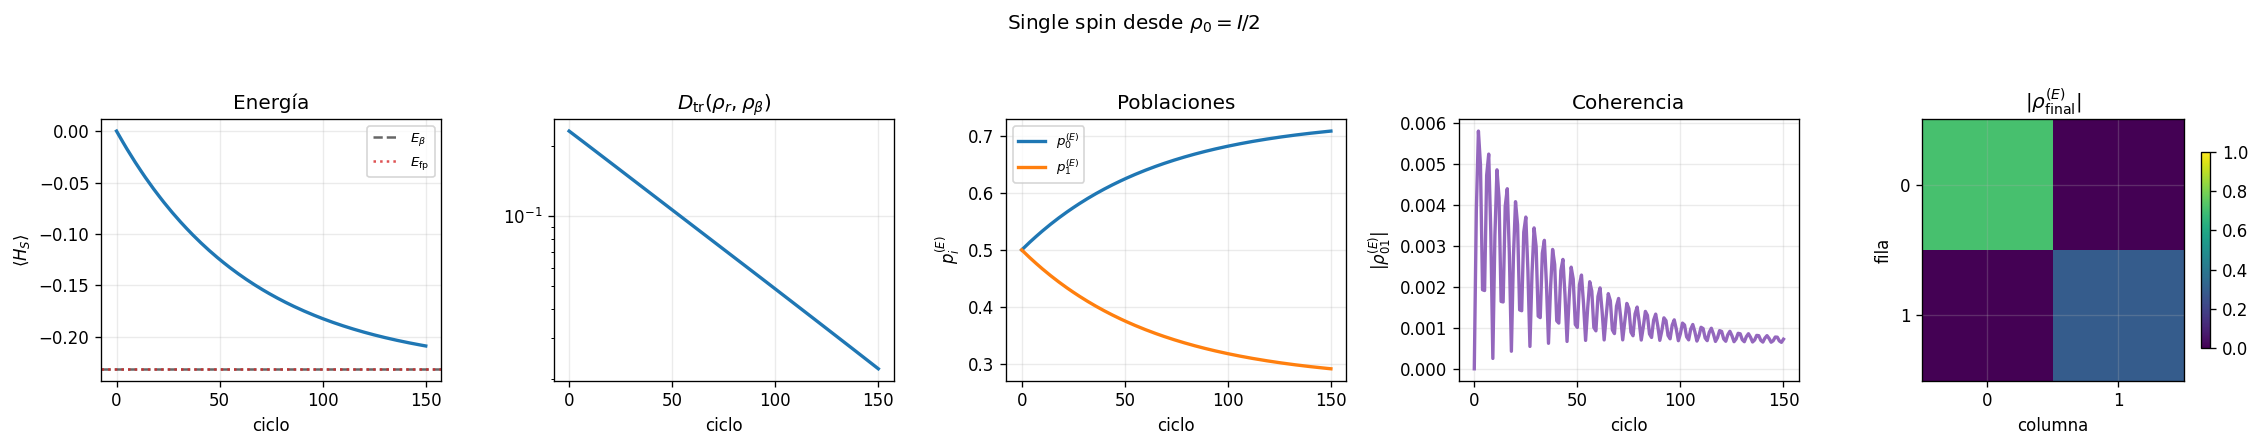

max coherencia = 5.812e-03
coherencia final = 7.231e-04
poblaciones finales = [0.708875, 0.291125]


In [6]:
rho0_mm = maximally_mixed(1)

out_mm = run_single_spin_case(
    base_single_params,
    rho0=rho0_mm,
    compute_fp=True,
    fp_mode="superop",
)

print_case_report(out_mm, label="single spin desde I/2")

plot_single_spin_compact_dashboard(
    out_mm,
    title=r"Single spin desde $\rho_0=I/2$",
)

stats_mm = single_spin_dashboard_stats(out_mm)

print(f"max coherencia = {stats_mm['max_coherence']:.3e}")
print(f"coherencia final = {stats_mm['final_coherence']:.3e}")
print(
    "poblaciones finales = "
    f"[{stats_mm['final_pop_0']:.6f}, {stats_mm['final_pop_1']:.6f}]"
)

### A.1.3 Caso detallado desde $\rho_0 = |+\rangle\langle +|$

Para analizar la dinámica de las coherencias, se considera como estado inicial el estado superposición

$$
|+\rangle = \frac{1}{\sqrt{2}} (|0\rangle + |1\rangle),
$$

que presenta coherencias máximas en la base computacional y, como $H_S \propto Z$, también en la base de energía.

A diferencia del caso anterior, donde la dinámica era puramente poblacional, este estado permite estudiar de forma directa el carácter del canal inducido por el protocolo: si actúa como un mecanismo de thermalización completa o si introduce principalmente dephasing.

En esta sección se sigue la evolución de la coherencia en la base de energía,
$$
\rho_{01}^{(E)} = \langle E_0 | \rho | E_1 \rangle,
$$
junto con la energía y la distancia al estado de Gibbs. Este análisis permite distinguir entre distintos regímenes del protocolo y entender el papel del operador de acoplo en la supresión o preservación de coherencias. Aquí vemos limpiamente el **dephasing** del protocolo sobre la
parte coherente y su relación con el filtro y la resonancia T = π/ω.

REPORTE: single spin desde |+><+|
Hs terms     : [(-0.5, {0: 'Z'})]
beta         : 1.0
theta        : 0.15
delta        : 0.08
MT           : 30
n_cycles     : 150
fp method    : superop
--------------------------------------------------------------------------------


,label,n_sys,n_bath,beta,theta,delta,MT,n_cycles,E0,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)",PopErr(fp),CohErr(fp)
0,single spin desde |+><+|,1,1,1.0,0.15,0.08,30,150,0.0,-0.208168,-0.231059,-0.231636,0.022891,0.000578,0.999229,0.025476,0.999999,0.000853,0.001156,0.000888


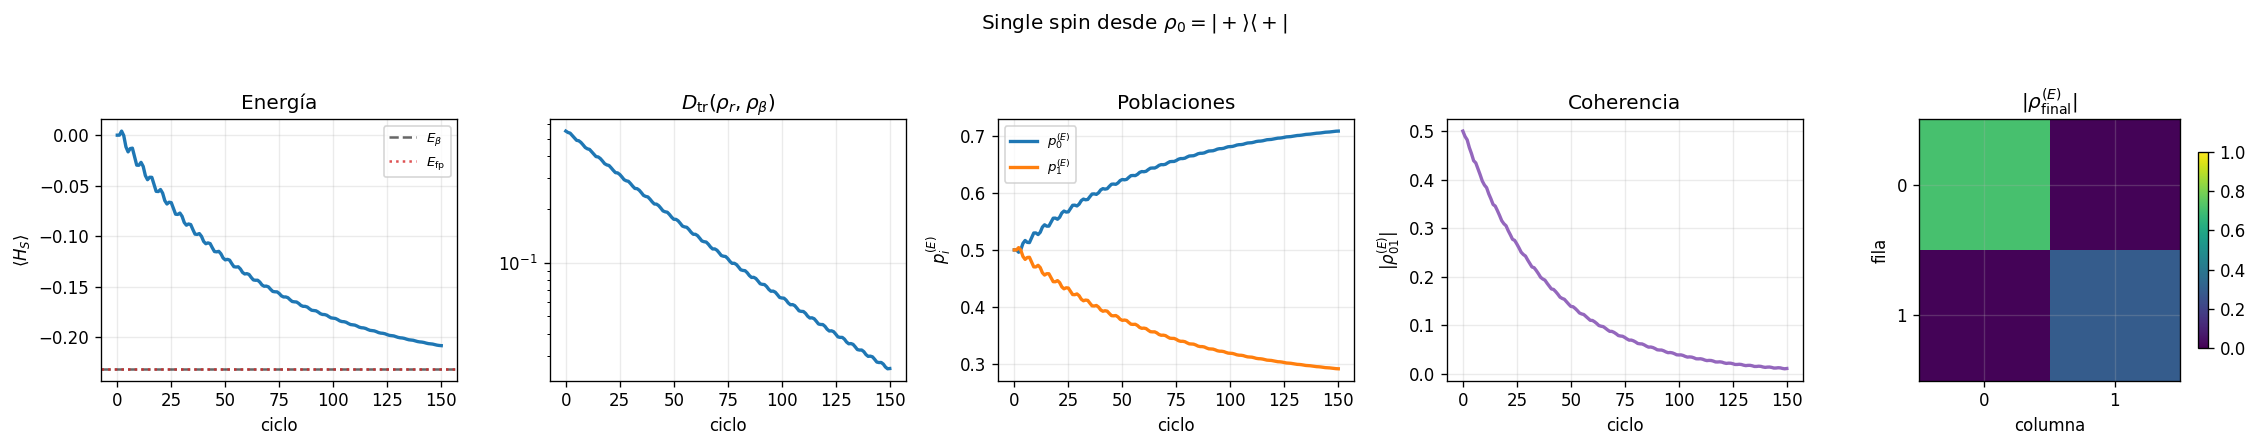

,col 0,col 1
fila 0,0.70817,0.01118
fila 1,0.01118,0.29183


max coherencia = 5.000e-01
coherencia final = 1.118e-02
poblaciones finales = [0.708168, 0.291832]


In [7]:
out_plus = run_single_spin_case(
    base_single_params,
    rho0=all_plus(1),
    compute_fp=True,
    fp_mode="superop",
)

print_case_report(out_plus, label="single spin desde |+><+|")

plot_single_spin_compact_dashboard(
    out_plus,
    title=r"Single spin desde $\rho_0=|+\rangle\langle+|$",
)

_, rho_final_e = energy_basis_matrix(out_plus["res"]["rhos"][-1], out_plus["Hs"])

display(pd.DataFrame(
    np.abs(rho_final_e),
    index=["fila 0", "fila 1"],
    columns=["col 0", "col 1"],
).round(5))

stats_plus = single_spin_dashboard_stats(out_plus)

print(f"max coherencia = {stats_plus['max_coherence']:.3e}")
print(f"coherencia final = {stats_plus['final_coherence']:.3e}")
print(
    "poblaciones finales = "
    f"[{stats_plus['final_pop_0']:.6f}, {stats_plus['final_pop_1']:.6f}]"
)

Desde $|+\rangle$ el protocolo hace dos cosas a la vez: empuja las poblaciones hacia las del estado térmico y elimina la coherencia en base de energía. La matriz final es prácticamente diagonal, con poblaciones de Gibbs y coherencia residual pequeña. Combinado con A.1.2, queda claro que el atractor es el mismo desde ambos $\rho_0$: lo único que cambia es el transitorio. Desde $I/2$ apenas aparecen coherencias intermedias; desde $|+\rangle$ se ve limpiamente su decaimiento.

### A.1.4 Validación cruzada del punto fijo

Antes de seguir con barridos y variantes del protocolo, validamos que las tres representaciones del estado estacionario coinciden en el régimen de acoplo débil y protocolo determinista (OFF):

1. **Estado de Gibbs exacto**
$$
\rho_\beta = \frac{e^{-\beta H_S}}{Z}, \qquad Z=\operatorname{Tr}(e^{-\beta H_S}).
$$
Es el objetivo termodinámico, independiente del protocolo.

2. **Punto fijo exacto del canal** $\rho_{\rm fp}$, obtenido por diagonalización del superoperador $\mathcal{E}$: resolvemos $\mathcal{E}(\rho_{\rm fp}) = \rho_{\rm fp}$ extrayendo el autovector de autovalor $\lambda=1$. Es el estado estacionario **exacto** del canal discreto, incluyendo todos los errores por acoplo finito $\theta$ y Trotter $\delta$.

3. **Promedio temporal tardío** $\bar\rho_{\rm late}$, calculado como media de los últimos $N_{\rm keep}$ estados de la trayectoria tras un burn-in de $N_{\rm burn}$ ciclos. Es la única vía viable en sistemas grandes donde el superoperador no cabe en memoria.

El resultado esperado:

- $\|\rho_{\rm fp} - \bar\rho_{\rm late}\|_1 \to 0$ al aumentar $N_{\rm keep}$: los dos métodos numéricos tienen que coincidir entre sí.
- $\|\rho_{\rm fp} - \rho_\beta\|_1 \sim \theta^2$: es la desviación física predicha por el paper.

Este bloque sirve como referencia para los notebooks posteriores, donde `fixed_point_via_superop` dejará de ser viable (a partir de $\sim\!4$ qubits) y trabajaremos solo con $\bar\rho_{\rm late}$.

,par,D_tr,F
0,fp_superop vs Gibbs,0.000853,0.999999
1,late_time vs Gibbs,0.000849,0.999999
2,fp_superop vs late_time,0.000007,1.000000


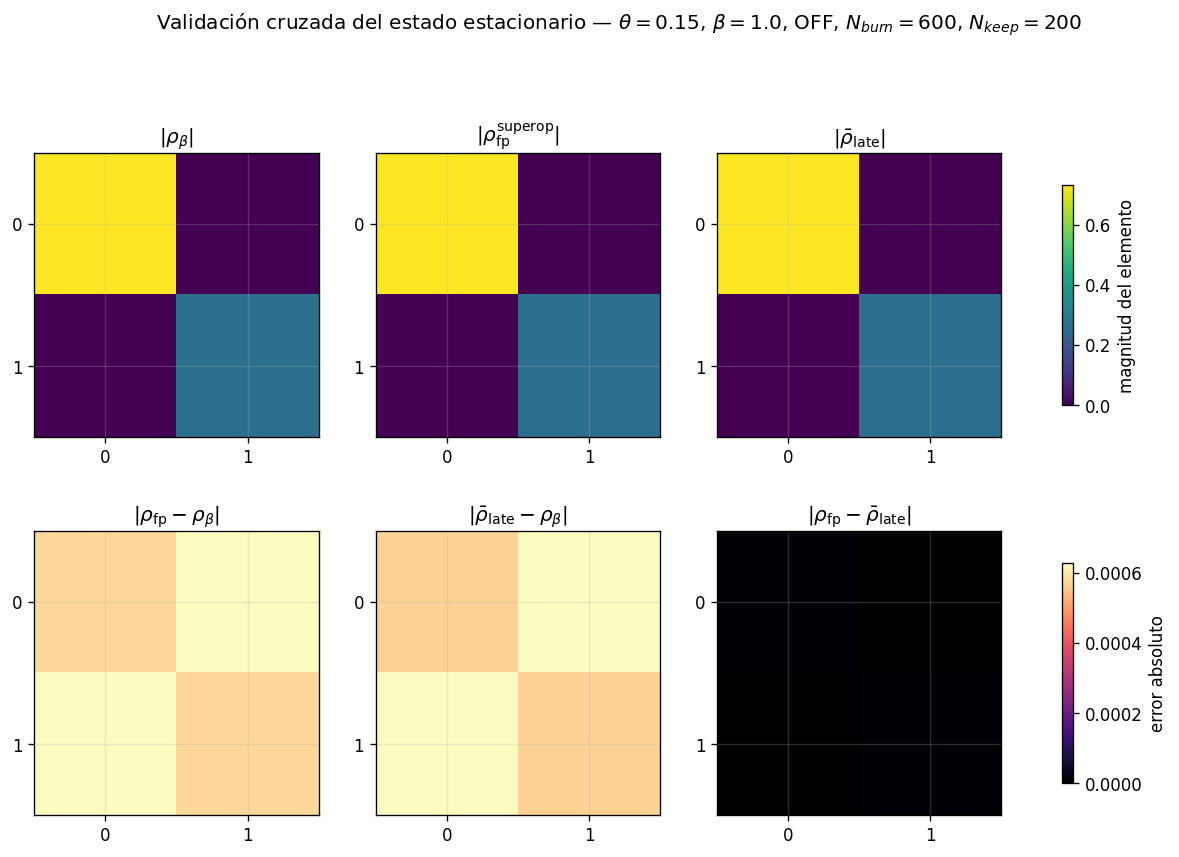


D(fp_superop, late_time) = 6.61e-06   [consistencia numérica entre métodos]
D(fp_superop, Gibbs)     = 8.53e-04   [esperado ~ θ² = 2.25e-02]


In [12]:
# A.1.4 — Validación cruzada: rho_Gibbs vs rho_fp (superop) vs rho_late (promedio tardío)
# Protocolo OFF, para que el canal sea determinista y los dos métodos numéricos
# tengan derecho a coincidir exactamente.

params_check = dict(base_single_params)
params_check.update({
    "randomize": False,
    "randomization_lambda": 0.0,
})

# --- 1) y 2): Gibbs + punto fijo exacto vía superoperador ---
out_check = run_single_spin_case(
    params_check,
    rho0=maximally_mixed(1),
    compute_fp=True,
    fp_mode="superop",
)
Hs         = out_check["Hs"]
rho_gibbs  = out_check["rho_g"]
rho_fp     = out_check["rho_fp"]
compiled   = out_check["compiled"]

# --- 3): promedio temporal tardío ---
N_BURN, N_KEEP = 600, 200
rho_late, _ = late_time_fixed_point(
    compiled,
    rho0_s=maximally_mixed(1),
    n_burn=N_BURN,
    n_keep=N_KEEP,
    sample_randomization=False,
)

# --- Distancias y fidelidades pareadas ---
pairs = [
    ("fp_superop  vs  Gibbs",     rho_fp,   rho_gibbs),
    ("late_time   vs  Gibbs",     rho_late, rho_gibbs),
    ("fp_superop  vs  late_time", rho_fp,   rho_late),
]
df_check = pd.DataFrame([
    {"par": name,
     "D_tr": trace_distance_dm(rA, rB),
     "F":    fidelity_dm(rA, rB)}
    for name, rA, rB in pairs
])
display(df_check.round(10))

# --- Visualización: 3 matrices + 3 diferencias, en base de energía ---
_, rho_gibbs_e = energy_basis_matrix(rho_gibbs, Hs)
_, rho_fp_e    = energy_basis_matrix(rho_fp,    Hs)
_, rho_late_e  = energy_basis_matrix(rho_late,  Hs)

mains  = [np.abs(rho_gibbs_e), np.abs(rho_fp_e), np.abs(rho_late_e)]
diffs  = [np.abs(rho_fp_e   - rho_gibbs_e),
          np.abs(rho_late_e - rho_gibbs_e),
          np.abs(rho_fp_e   - rho_late_e)]

titles_main = [r"$|\rho_\beta|$",
               r"$|\rho_{\rm fp}^{\rm superop}|$",
               r"$|\bar\rho_{\rm late}|$"]
titles_diff = [r"$|\rho_{\rm fp}-\rho_\beta|$",
               r"$|\bar\rho_{\rm late}-\rho_\beta|$",
               r"$|\rho_{\rm fp}-\bar\rho_{\rm late}|$"]

vmax_main = max(M.max() for M in mains)
vmax_diff = max(D.max() for D in diffs) + 1e-16   # evita vmax=0 si coinciden

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, M, t in zip(axes[0], mains, titles_main):
    im = ax.imshow(M, vmin=0, vmax=vmax_main, cmap="viridis")
    ax.set_title(t)
    ax.set_xticks(range(M.shape[0])); ax.set_yticks(range(M.shape[0]))
fig.colorbar(im, ax=axes[0, :].ravel().tolist(), shrink=0.7,
             label="magnitud del elemento")

for ax, D, t in zip(axes[1], diffs, titles_diff):
    im2 = ax.imshow(D, vmin=0, vmax=vmax_diff, cmap="magma")
    ax.set_title(t)
    ax.set_xticks(range(D.shape[0])); ax.set_yticks(range(D.shape[0]))
fig.colorbar(im2, ax=axes[1, :].ravel().tolist(), shrink=0.7,
             label="error absoluto")

fig.suptitle(
    f"Validación cruzada del estado estacionario — "
    rf"$\theta={params_check['theta']}$, $\beta={params_check['beta']}$, "
    f"OFF, $N_{{burn}}={N_BURN}$, $N_{{keep}}={N_KEEP}$",
    y=1.02,
)
plt.show()

# --- Interpretación numérica rápida ---
D_fp_late  = df_check.iloc[2]["D_tr"]
D_fp_gibbs = df_check.iloc[0]["D_tr"]
print(f"\nD(fp_superop, late_time) = {D_fp_late:.2e}   "
      "[consistencia numérica entre métodos]")
print(f"D(fp_superop, Gibbs)     = {D_fp_gibbs:.2e}   "
      f"[esperado ~ θ² = {params_check['theta']**2:.2e}]")

## A.2 Operadores de acoplo $A_S, A_B$ y schedules temporales



### A.2.1 $A_S \in \{X,Y,Z\} \times A_B \in \{Y,Z\}$: thermalización, dephasing y caso no disipativo

El acoplo es $V = A_S \otimes A_B$. Aunque $A_S$ y $A_B$ entran simétricamente, su papel físico no lo es: $A_S$ decide qué componentes del estado del sistema se ven afectadas; $A_B$ controla cómo el baño media la disipación bajo medida y reset. Comparamos cuatro combinaciones:

- $A_S=Y,\ A_B=Y$ — caso thermalizante de referencia.
- $A_S=X,\ A_B=Y$ — thermalización con eje distinto en el sistema.
- $A_S=Z,\ A_B=Y$ — dephasing puro: $A_S$ conmuta con $H_S \propto Z$ y no genera transiciones de Bohr.
- $A_S=Y,\ A_B=Z$ — caso no disipativo: $A_B$ diagonal en la base de medida del baño elimina la disipación efectiva, y el baño actúa más como campo clásico que como canal térmico.

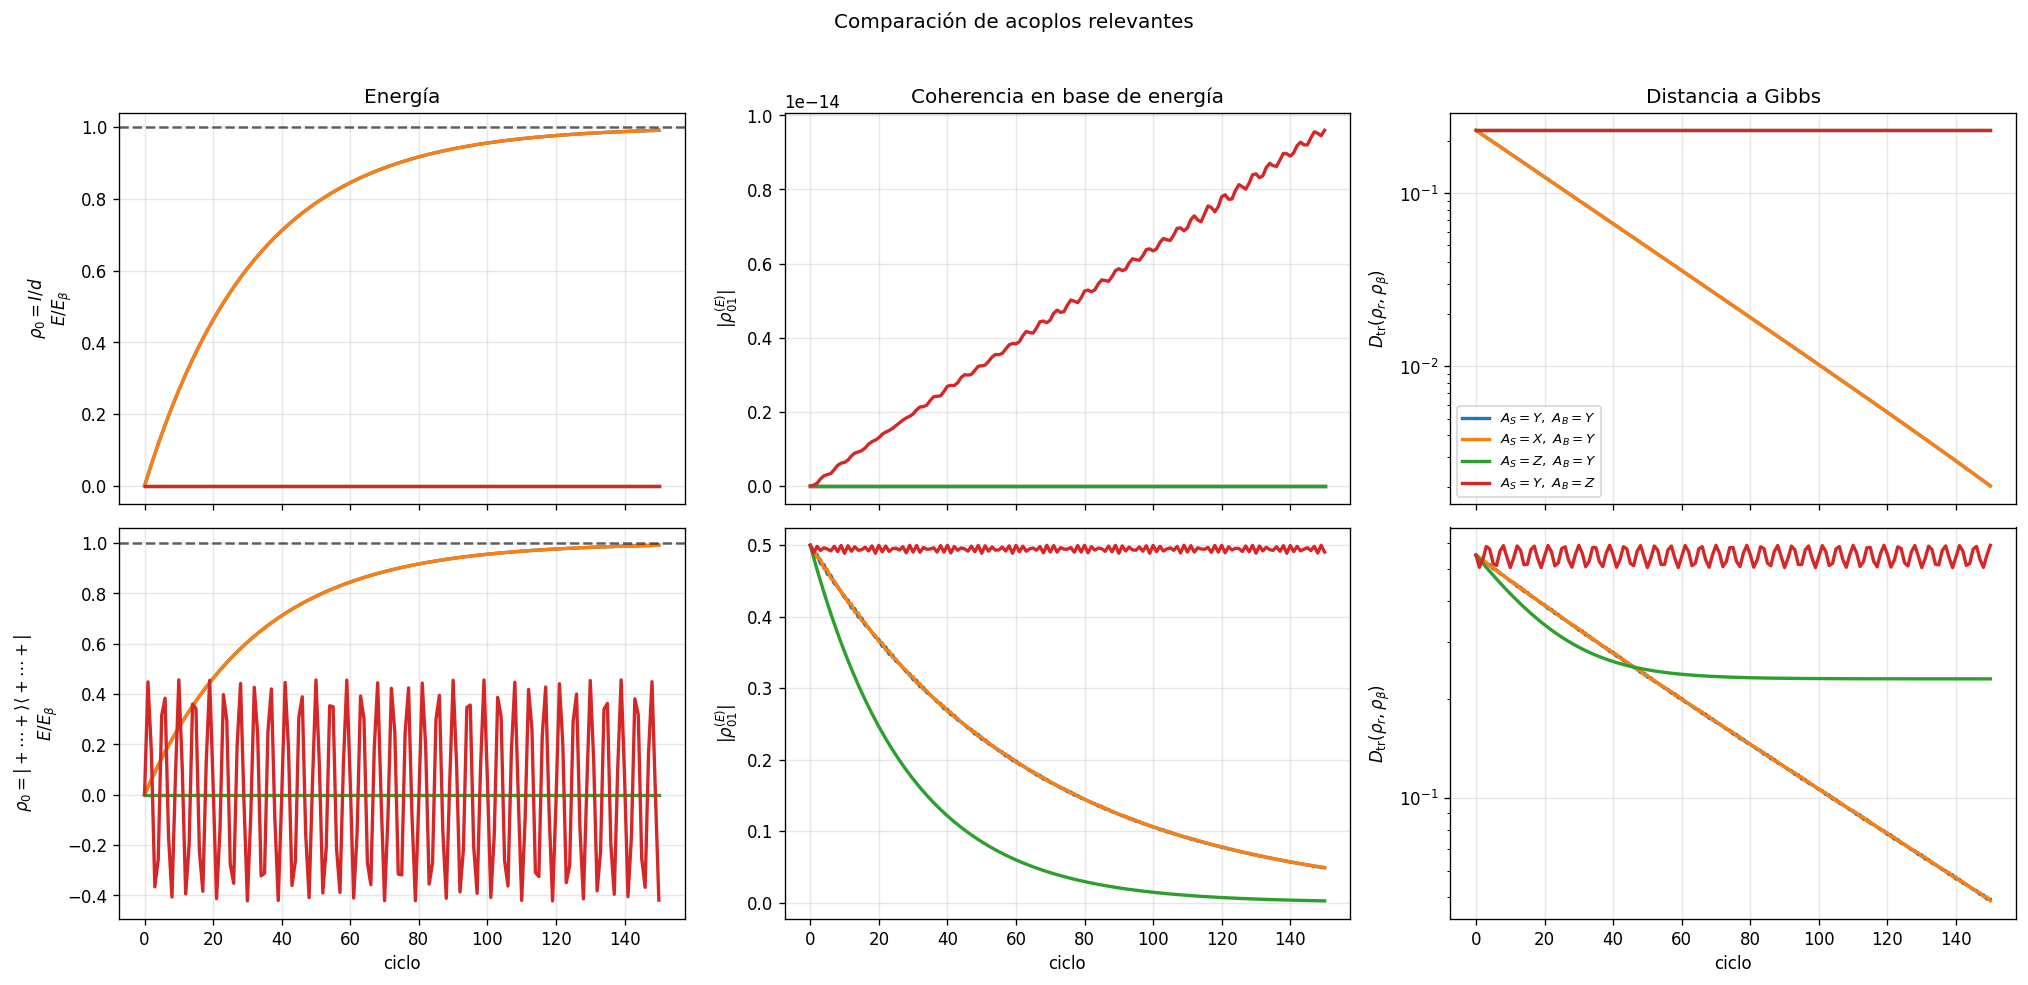

,rho0,case,Efinal,Egibbs,Efinal/Eg,|Efinal-Eg|,"Dtr(final,Gibbs)","F(final,Gibbs)","Dtr(fp,Gibbs)","F(fp,Gibbs)",coh_max,coh_final
0,$\rho_0=I/d$,"$A_S=Y,\ A_B=Y$",-0.229017,-0.231059,0.991163,0.002042,0.002042,0.999995,0.000164,1.000000,0.0,0.000000
1,$\rho_0=I/d$,"$A_S=X,\ A_B=Y$",-0.229017,-0.231059,0.991163,0.002042,0.002042,0.999995,0.000164,1.000000,0.0,0.000000
2,$\rho_0=I/d$,"$A_S=Z,\ A_B=Y$",-0.000000,-0.231059,0.000000,0.231059,0.231059,0.943409,0.268941,0.731059,0.0,0.000000
3,$\rho_0=I/d$,"$A_S=Y,\ A_B=Z$",-0.000000,-0.231059,0.000000,0.231059,0.231059,0.943409,0.267485,0.811589,0.0,0.000000
4,$\rho_0=|+\cdots+\rangle\langle+\cdots+|$,"$A_S=Y,\ A_B=Y$",-0.229017,-0.231059,0.991163,0.002042,0.049138,0.997583,0.000164,1.000000,0.5,0.049096
5,$\rho_0=|+\cdots+\rangle\langle+\cdots+|$,"$A_S=X,\ A_B=Y$",-0.229017,-0.231059,0.991163,0.002042,0.048623,0.997633,0.000164,1.000000,0.5,0.048580
6,$\rho_0=|+\cdots+\rangle\langle+\cdots+|$,"$A_S=Z,\ A_B=Y$",-0.000000,-0.231059,0.000000,0.231059,0.231072,0.943404,0.268941,0.731059,0.5,0.002472
7,$\rho_0=|+\cdots+\rangle\langle+\cdots+|$,"$A_S=Y,\ A_B=Z$",0.096742,-0.231059,-0.418690,0.327800,0.589995,0.455294,0.267485,0.811589,0.5,0.490552


In [5]:
df_couplings = compare_system_couplings(
    runner=run_single_spin_case,
    base_params=base_single_params,
    coupling_cases={
        r"$A_S=Y,\ A_B=Y$": {"sys_A": "Y", "bath_A": "Y"},
        r"$A_S=X,\ A_B=Y$": {"sys_A": "X", "bath_A": "Y"},
        r"$A_S=Z,\ A_B=Y$": {"sys_A": "Z", "bath_A": "Y"},
        r"$A_S=Y,\ A_B=Z$": {"sys_A": "Y", "bath_A": "Z"},
    },
    n_sys=1,
    rho0_energy=maximally_mixed(1),
    rho0_coh=all_plus(1),
    coherence_mode="abs01",   # para single spin queda más intuitivo
)

Las tres familias quedan claramente separadas. $A_S=Y, A_B=Y$ y $A_S=X, A_B=Y$ son thermalizantes: relajan la energía, bajan la distancia a Gibbs y suprimen coherencias. $A_S=Z, A_B=Y$ conserva poblaciones y solo elimina coherencias — dephasing puro. $A_S=Y, A_B=Z$ produce una dinámica oscilatoria sin relajación: al ser $A_B$ diagonal en la base de medida, el baño no llega a actuar como canal disipativo.

###     A.2.2  Combinaciones lineales normalizadas ($XY, YZ, XZ, XYZ$)

**¿Qué operador elegir?** Paulis puros ($X$, $Y$, $Z$) y combinaciones
  lineales normalizadas ($X{+}Y$, $Y{+}Z$, $X{+}Z$, $X{+}Y{+}Z$). El caso
  $A_S=Z$ es el patológico: conmuta con $H_S\propto Z$ y por tanto no
  genera jumps de energía (no thermaliza, solo dephasea).

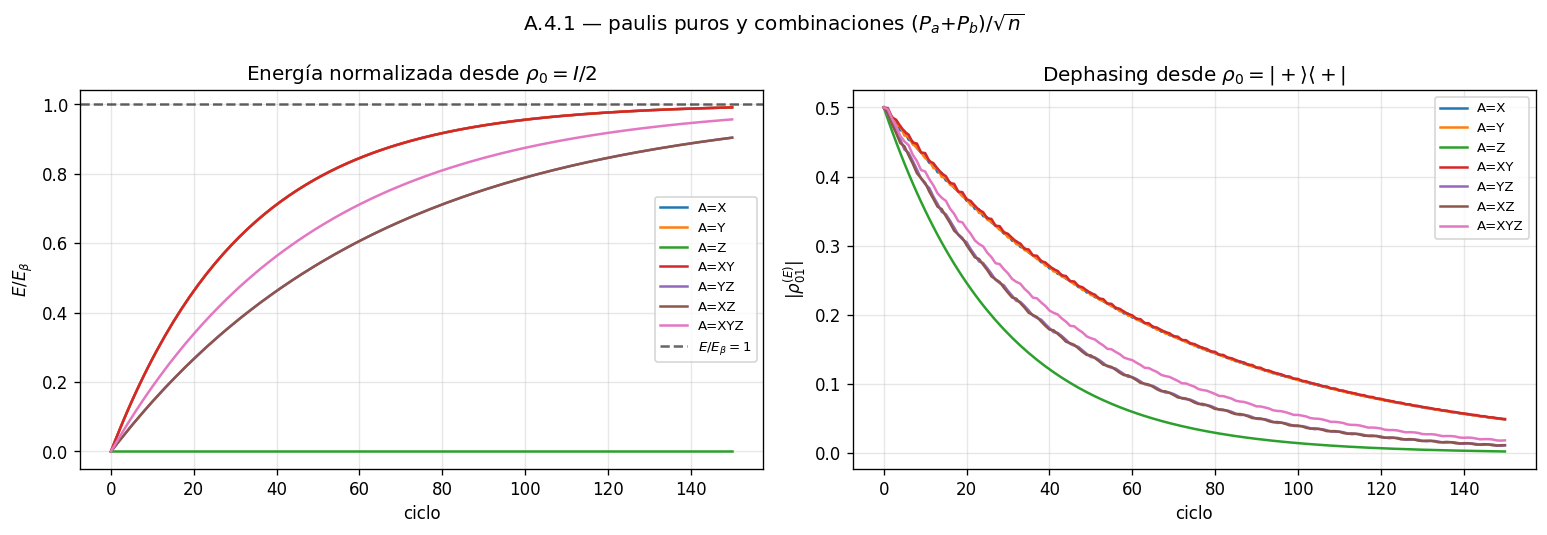

,A,Efinal/Eg,|Efp-Eg|,"Dtr(fp,Gibbs)","F(fp,Gibbs)",coh_final_|+>,nota
0,X,0.991163,0.000070,0.000070,1.000000,0.048580,thermaliza
1,Y,0.991163,0.000070,0.000070,1.000000,0.049096,thermaliza
2,Z,0.000000,NaN,NaN,NaN,0.002472,Z conmuta con H_S (no ergódico)
3,XY,0.991163,0.000070,0.000070,1.000000,0.049363,thermaliza
4,YZ,0.903990,0.006679,0.006710,0.999943,0.011181,thermaliza
5,XZ,0.903990,0.006679,0.006710,0.999943,0.011632,thermaliza
6,XYZ,0.956598,0.001862,0.001955,0.999995,0.018494,thermaliza


In [14]:
# Paulis y combinaciones lineales (X, Y, Z, XY, YZ, XZ, XYZ)

combos = ["X", "Y", "Z", "XY", "YZ", "XZ", "XYZ"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rows = []

for combo in combos:
    params = base_single_params.copy()
    params["sys_A"] = pauli_spec(combo)

    # 1) energía desde I/2
    out_E = run_single_spin_case(
        params, rho0=maximally_mixed(1),
        compute_fp=True, fp_mode="late_time",
    )
    Eg = out_E["Eg"]
    axes[0].plot(np.asarray(out_E["res"]["energies"]) / Eg, label=f"A={combo}")

    # 2) coherencia desde |+><+|
    out_C = run_single_spin_case(params, rho0=all_plus(1), compute_fp=False)
    coh_abs = np.array([
        np.abs(energy_basis_matrix(rho, out_C["Hs"])[1][0, 1])
        for rho in out_C["res"]["rhos"]
    ])
    axes[1].plot(coh_abs, label=f"A={combo}")

    # Flag de patología: solo Z puro conmuta con H_S
    is_pathological = (combo == "Z")
    rows.append({
        "A": combo,
        "Efinal/Eg":      out_E["res"]["energies"][-1] / Eg,
        "|Efp-Eg|":       np.nan if is_pathological else abs(out_E["Efp"] - Eg),
        "Dtr(fp,Gibbs)":  np.nan if is_pathological else out_E["fp_vs_gibbs"]["trace_distance"],
        "F(fp,Gibbs)":    np.nan if is_pathological else out_E["fp_vs_gibbs"]["fidelity"],
        "coh_final_|+>":  coh_abs[-1],
        "nota":           "Z conmuta con H_S (no ergódico)" if is_pathological else "thermaliza",
    })

axes[0].axhline(1.0, ls="--", color="k", alpha=0.6, label=r"$E/E_\beta=1$")
axes[0].set_xlabel("ciclo"); axes[0].set_ylabel(r"$E/E_\beta$")
axes[0].set_title(r"Energía normalizada desde $\rho_0=I/2$")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel("ciclo"); axes[1].set_ylabel(r"$|\rho^{(E)}_{01}|$")
axes[1].set_title(r"Dephasing desde $\rho_0=|+\rangle\langle+|$")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle(r"A.4.1 — paulis puros y combinaciones $(P_a{+}P_b)/\sqrt{n}$")
plt.tight_layout(); plt.show()

display(pd.DataFrame(rows).round(6))

### A.2.3 Patrones temporales del acoplo: fijo, alternante y aleatorio

Comparamos tres formas de aplicar los operadores de acoplo durante el filtro temporal: un patrón fijo, un patrón alternante y una elección aleatoria entre operadores compatibles. Esta comparación permite separar el efecto del operador local del efecto de la modulación temporal del acoplo.

Estas variantes permiten estudiar la robustez del protocolo frente a resonancias, así como su capacidad para suprimir coherencias no deseadas o acelerar la convergencia hacia el estado estacionario.

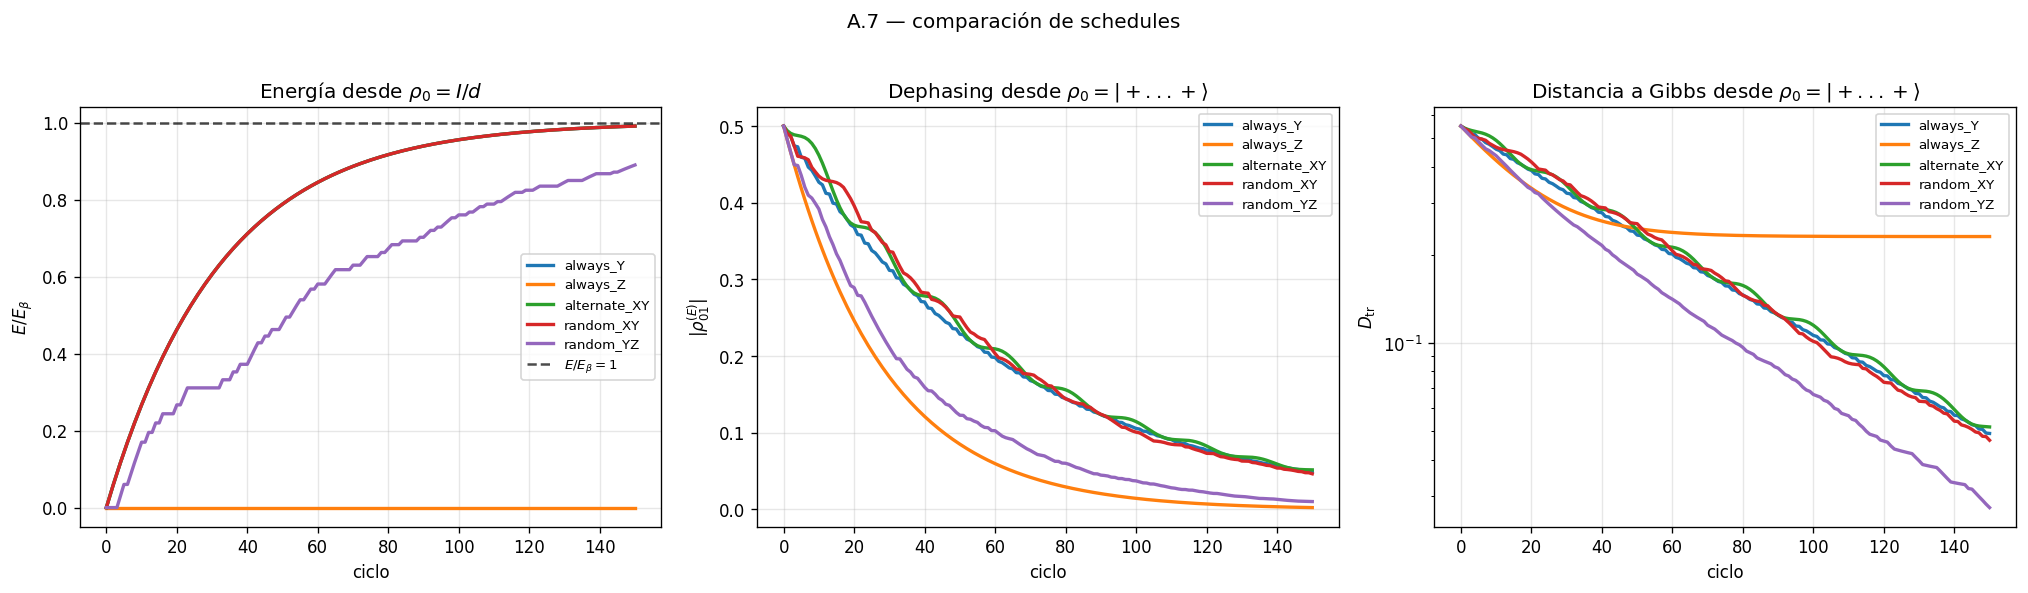

,schedule,Efinal/Eg,"Dtr(final,Gibbs)","F(final,Gibbs)",coh_final
0,always_Y,0.991163,0.049138,0.997583,0.049096
1,always_Z,0.000000,0.231072,0.943404,0.002472
2,alternate_XY,0.991163,0.051718,0.997321,0.051678
3,random_XY,0.991163,0.046577,0.997829,0.046532
4,random_YZ,0.890066,0.027428,0.999098,0.010348


In [17]:
compiled_bank = {
    "X": compile_protocol(build_single_spin_cfg(**dict(base_single_params, sys_A="X"))),
    "Y": compile_protocol(build_single_spin_cfg(**dict(base_single_params, sys_A="Y"))),
    "Z": compile_protocol(build_single_spin_cfg(**dict(base_single_params, sys_A="Z"))),
}

df_sched, outs_sched = compare_schedule_family(
    compiled_bank=compiled_bank,
    schedule_cases={
        "always_Y": "always_Y",
        "always_Z": "always_Z",
        "alternate_XY": "alternate_XY",
        "random_XY": "random_XY",
        "random_YZ": "random_YZ",
    },
    rho0_energy=maximally_mixed(1),
    rho0_coh=all_plus(1),
    title="A.7 — comparación de schedules",
)

El punto fijo poblacional es el mismo para los tres Paulis del sistema, como predice la teoría: el target depende solo de $H_S$ y $\beta$. Lo que cambia es la velocidad de convergencia y el patrón transitorio de coherencias. $X$ e $Y$ son operativamente equivalentes por simetría con $H_S \propto Z$; $Z$ no thermaliza porque conmuta con $H_S$. Las combinaciones tipo $X{+}Y$, $Y{+}Z$ o $X{+}Y{+}Z$ funcionan en cuanto incluyen alguna componente que anticonmute con $H_S$.

Alternar operadores ciclo a ciclo no introduce sesgo en el punto fijo, pero sí cambia el transitorio. En single spin las distintas variantes temporales (always, alternate, random) producen resultados muy similares: la dinámica está dominada por el canal medio.

## A.3 Barridos de parámetros y mapas de régimen

El protocolo depende del filtro gaussiano discreto a través del número de capas $M_T$ y el paso $\delta$, que fijan la ventana temporal $T_{\rm eff} = M_T\delta$ y la resolución del acoplo filtrado. Para entender qué hace cada uno contrastamos dos comparaciones complementarias: a $\delta$ fijo, donde aumentar $M_T$ alarga el ciclo y refina al mismo tiempo, y a $T_{\rm eff}$ fijo, que aísla el efecto de la discretización. La primera mezcla los dos efectos; la segunda permite atribuir las diferencias específicamente al número de capas usado para implementar el ciclo.

###  A.3.1  Barridos 1D de $β, θ, h, g, δ, MT$ (una rejilla)

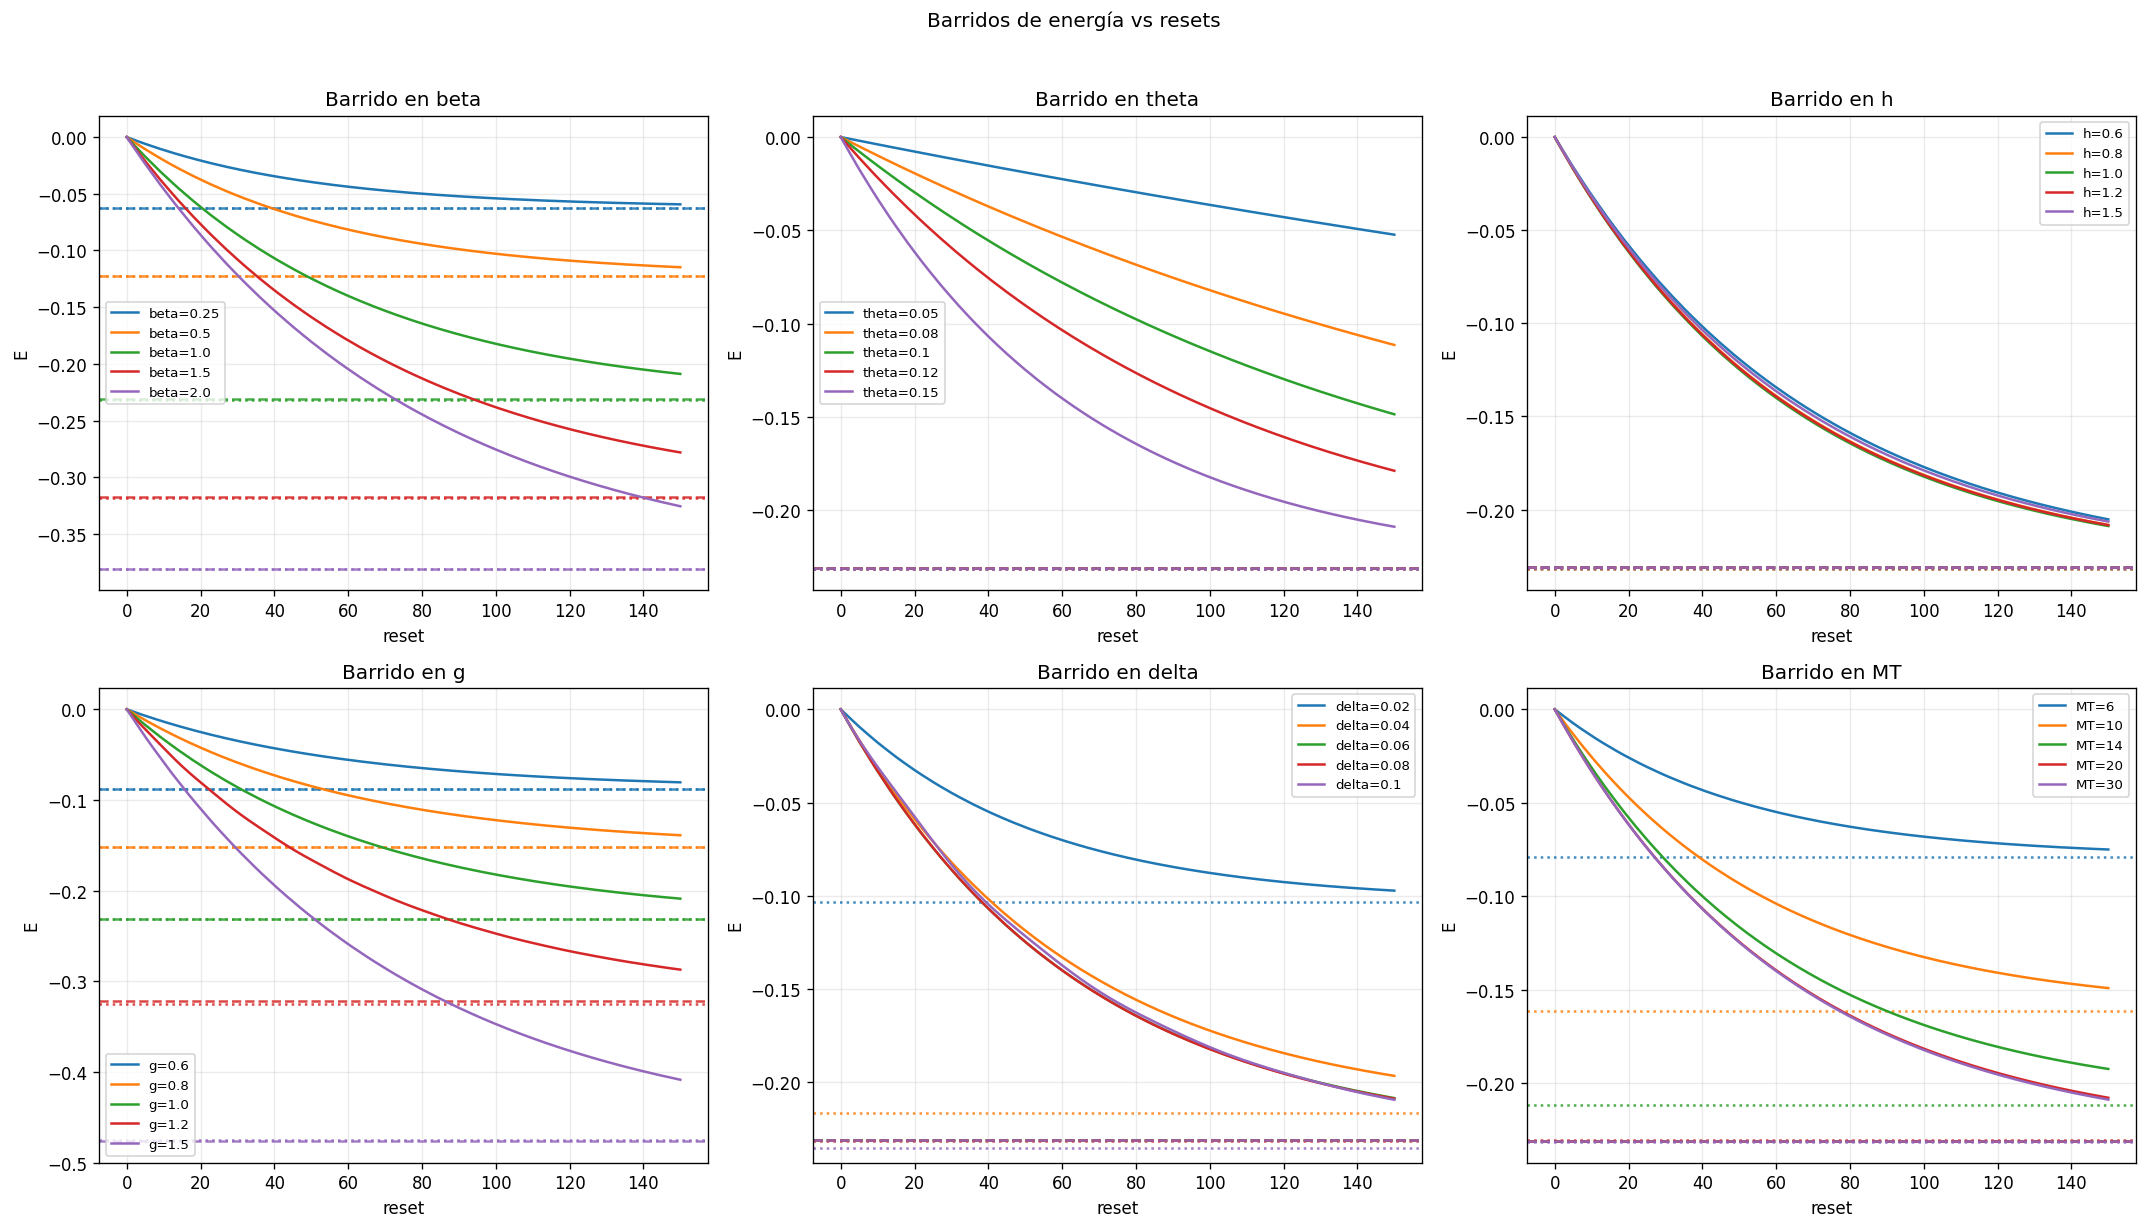

TABLAS RESUMEN DE BARRIDOS

--- Sweep: beta ---


,beta,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.25,-0.059313,-0.062177,-0.062321,0.002863,0.000145,0.999992,0.002866,1.000000,0.000196
1,0.50,-0.114789,-0.122459,-0.122786,0.007671,0.000327,0.999938,0.007678,1.000000,0.000454
2,1.00,-0.208875,-0.231059,-0.231636,0.022184,0.000578,0.999389,0.022196,0.999999,0.000853
3,1.50,-0.278142,-0.317574,-0.318182,0.039432,0.000608,0.997585,0.039449,0.999999,0.001035
4,2.00,-0.325612,-0.380797,-0.381324,0.055185,0.000527,0.993882,0.055207,0.999998,0.001146



--- Sweep: theta ---


,theta,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.05,-0.052312,-0.231059,-0.231123,0.178746,0.000064,0.965150,0.178747,1.000000,0.000095
1,0.08,-0.111420,-0.231059,-0.231223,0.119639,0.000164,0.983748,0.119641,1.000000,0.000243
2,0.10,-0.148588,-0.231059,-0.231315,0.082470,0.000257,0.992042,0.082474,1.000000,0.000379
3,0.12,-0.178859,-0.231059,-0.231428,0.052200,0.000370,0.996722,0.052205,1.000000,0.000546
4,0.15,-0.208875,-0.231059,-0.231636,0.022184,0.000578,0.999389,0.022196,0.999999,0.000853



--- Sweep: h ---


...

,g,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.6,-0.080523,-0.087394,-0.087445,0.006871,0.000051,0.999858,0.011453,1.000000,0.000180
1,0.8,-0.138922,-0.151980,-0.152159,0.013058,0.000180,0.999693,0.016326,1.000000,0.000368
2,1.0,-0.208875,-0.231059,-0.231636,0.022184,0.000578,0.999389,0.022196,0.999999,0.000853
3,1.2,-0.287189,-0.322230,-0.325157,0.035041,0.002927,0.998844,0.029324,0.999985,0.003570
4,1.5,-0.408672,-0.476362,-0.474686,0.067690,0.001676,0.996868,0.045156,0.999995,0.001937



--- Sweep: delta ---


,delta,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.02,-0.097275,-0.231059,-0.103286,0.133784,0.127772,0.979889,0.133784,0.981576,0.127773
1,0.04,-0.196646,-0.231059,-0.216687,0.034413,0.014372,0.998550,0.034417,0.999741,0.014378
2,0.06,-0.208564,-0.231059,-0.231079,0.022494,0.000021,0.999372,0.022500,1.000000,0.000420
3,0.08,-0.208875,-0.231059,-0.231636,0.022184,0.000578,0.999389,0.022196,0.999999,0.000853
4,0.10,-0.209451,-0.231059,-0.235214,0.021607,0.004155,0.999399,0.022118,0.999959,0.006038



--- Sweep: MT ---


,MT,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,6,-0.075015,-0.231059,-0.079089,0.156043,0.151969,0.973056,0.156044,0.974376,0.151969
1,10,-0.149195,-0.231059,-0.161330,0.081864,0.069728,0.992155,0.081865,0.994247,0.069729
2,14,-0.192464,-0.231059,-0.211707,0.038594,0.019352,0.998184,0.038597,0.999534,0.019356
3,20,-0.207883,-0.231059,-0.230222,0.023175,0.000837,0.999334,0.023181,0.999999,0.000930
4,30,-0.208875,-0.231059,-0.231636,0.022184,0.000578,0.999389,0.022196,0.999999,0.000853


In [18]:
sweep_map_single = {
    "beta":  [0.25, 0.5, 1.0, 1.5, 2.0],
    "theta": [0.05, 0.08, 0.10, 0.12, 0.15],
    "h":     [0.6, 0.8, 1.0, 1.2, 1.5],
    "g":     [0.6, 0.8, 1.0, 1.2, 1.5],
    "delta": [0.02, 0.04, 0.06, 0.08, 0.10],
    "MT":    [6, 10, 14, 20, 30],
}

tables_single = plot_energy_sweep_grid(
    run_single_spin_case,
    base_single_params,
    sweep_map_single,
    rho0=maximally_mixed(1),
    figsize=(18, 10),
)

### A.3.2 Mapa explicativo de regímenes $(\theta, M_T)$

El parámetro $M_T$ controla el tiempo por ciclo del protocolo, $T = M_T \cdot \delta$, 
y con ello las resonancias del denominador de la Ec. 42 del paper:

$$
1 - e^{2iT\omega_{ab}} - i\omega_{ab} T_0
$$

Estas resonancias aparecen cuando $T\omega_{ab} = k\pi$. En single-spin solo hay 
una frecuencia de Bohr, $\omega = g$, así que las resonancias están en 
$M_T^{\rm res} = k\pi / (g\,\delta)$ para $k = 1, 2, 3, \ldots$

Este heatmap $(\theta, M_T)$ visualiza los regímenes del protocolo: bandas 
horizontales brillantes = resonancias (sesgo alto), zonas oscuras = valles 
inter-resonantes donde el protocolo es limpio y robusto. Superponemos las líneas 
de resonancia teóricas para confirmar que las bandas observadas coinciden con 
la predicción.

A $M_T$ muy pequeño ($\lesssim 15$ con $\delta = 0.08$) el filtro Gaussiano se 
trunca ($T = M_T\,\delta < 1/a$) y aparece un error adicional de truncamiento 
que no es resonancia. Esta zona hay que descartarla por motivos puramente 
numéricos.

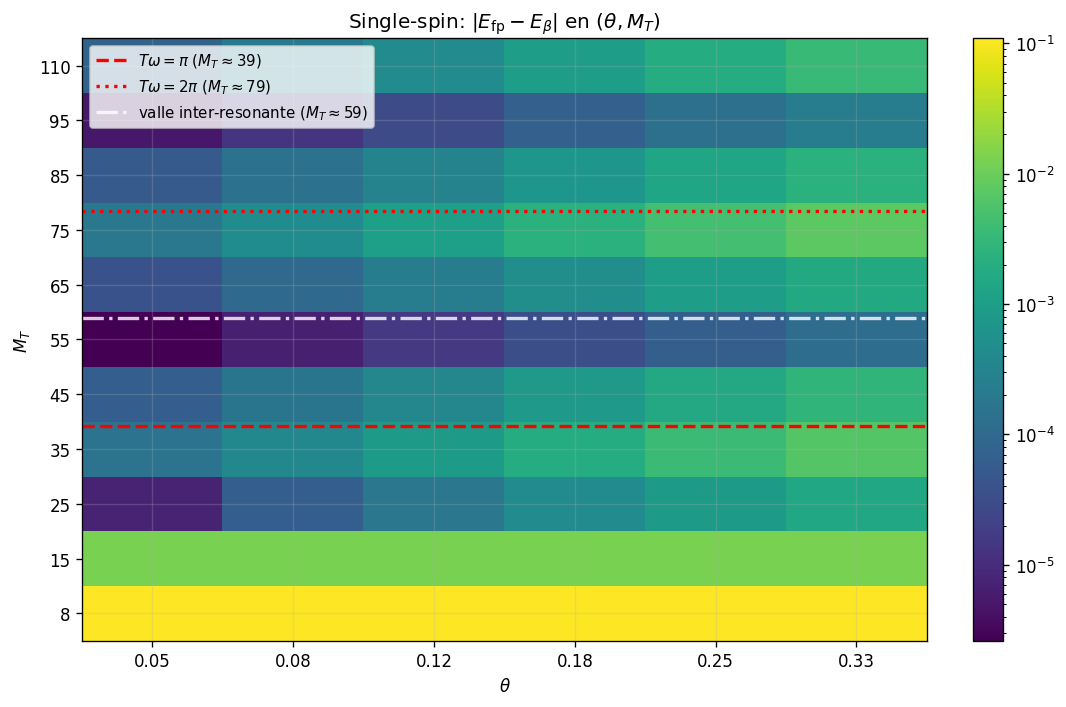

Primera resonancia:   T·g = π   →  MT ≈ 39.3
Segunda resonancia:   T·g = 2π  →  MT ≈ 78.5
Valle inter-resonante: T·g = 1.5π → MT ≈ 58.9


In [5]:
# A.3.2 — heatmap (theta, MT) en single-spin
from matplotlib.colors import LogNorm
from numpy import interp

MT_grid_ss  = np.array([8, 15, 25, 35, 45, 55, 65, 75, 85, 95, 110])
theta_grid_ss = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.33])

Z_mt_ss = np.zeros((len(MT_grid_ss), len(theta_grid_ss)))

for j, th in enumerate(theta_grid_ss):
    for i, MT_v in enumerate(MT_grid_ss):
        p = dict(base_single_params,
                 theta=float(th), MT=int(MT_v), n_cycles=200)
        out = run_single_spin_case(p, rho0=maximally_mixed(1),
                                    compute_fp=True, fp_mode="superop")
        Z_mt_ss[i, j] = abs(out["Efp"] - out["Eg"])

# Posiciones resonantes: T*omega = k*pi con omega = g
delta_used = base_single_params["delta"]
g_used     = base_single_params["g"]
MT_res1_ss = np.pi / (delta_used * g_used)
MT_res2_ss = 2 * np.pi / (delta_used * g_used)
MT_valle1_ss = 1.5 * np.pi / (delta_used * g_used)

def mt_to_index(mt_val, mt_grid):
    return interp(mt_val, mt_grid, np.arange(len(mt_grid)))

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    Z_mt_ss, aspect="auto", origin="lower",
    norm=LogNorm(vmin=max(Z_mt_ss.min(), 1e-6), vmax=Z_mt_ss.max()),
    cmap="viridis",
)
ax.set_xticks(range(len(theta_grid_ss)))
ax.set_xticklabels([f"{x:.2f}" for x in theta_grid_ss])
ax.set_yticks(range(len(MT_grid_ss)))
ax.set_yticklabels(MT_grid_ss)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$M_T$")
ax.set_title(r"Single-spin: $|E_{\rm fp} - E_\beta|$ en $(\theta, M_T)$")

y_res1 = mt_to_index(MT_res1_ss, MT_grid_ss)
y_res2 = mt_to_index(MT_res2_ss, MT_grid_ss)
y_val1 = mt_to_index(MT_valle1_ss, MT_grid_ss)

ax.axhline(y_res1, color="red",  lw=2, ls="--",
           label=rf"$T\omega = \pi$ ($M_T \approx {MT_res1_ss:.0f}$)")
ax.axhline(y_res2, color="red",  lw=2, ls=":",
           label=rf"$T\omega = 2\pi$ ($M_T \approx {MT_res2_ss:.0f}$)")
ax.axhline(y_val1, color="white", lw=2, ls="-.", alpha=0.8,
           label=rf"valle inter-resonante ($M_T \approx {MT_valle1_ss:.0f}$)")

ax.legend(loc="upper left", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

print(f"Primera resonancia:   T·g = π   →  MT ≈ {MT_res1_ss:.1f}")
print(f"Segunda resonancia:   T·g = 2π  →  MT ≈ {MT_res2_ss:.1f}")
print(f"Valle inter-resonante: T·g = 1.5π → MT ≈ {MT_valle1_ss:.1f}")

- $M_T \approx 8$ — banda amarilla por truncamiento del filtro: el ancho $1/a$ no cabe en la ventana $T = M_T\delta$. No es resonancia.
- $M_T \approx 39$ — primera resonancia $T\omega = \pi$, alineada con la línea roja teórica. El sesgo del fp aumenta visiblemente.
- $M_T \approx 79$ — segunda resonancia $T\omega = 2\pi$, también identificable pero más suave.
- $M_T \approx 60$ — valle entre la primera y segunda resonancia ($T\omega = 1.5\pi$). Sesgo mínimo, $\sim 10^{-5}$ a $\theta = 0.05$. Zona óptima.

La elección recomendada es $M_T \in [50, 70]$, con $M_T = 60$ como centro del valle. El segundo valle ($M_T \in [90, 110]$) da resultados equivalentes pero más caros. El `base_single_params` actual usa $M_T = 30$, pegado a la primera resonancia: esto explica las ondulaciones residuales que aparecen en el barrido de $h$ y motiva mover a $M_T = 60$ en las capas Qiskit del notebook para barridos paramétricos limpios.

## A.4 Resonancias, randomización y rewind

En esta sección estudiamos cómo cambia el canal térmico al variar la ventana temporal del filtro,

$$
T_{\rm eff}=M_T\delta,
\qquad
x=\frac{T_{\rm eff}g}{\pi}.
$$

La variable $x$ controla la resolución energética del filtro. Cuando $T_{\rm eff}$ es conmensurable con la frecuencia de Bohr del qubit, aparecen resonancias del protocolo.

El flujo será:

1. localizar resonancias en el punto fijo determinista;
2. comprobar cómo aparecen a tiempo finito;
3. traducir la estructura a valores prácticos de $M_T$;
4. diagnosticar el espectro del canal;
5. comparar randomización y rewind.

### A.4.1 Resonancias del punto fijo


Primero calculamos el punto fijo exacto del canal sin randomización. Esto elimina la dependencia con el número de ciclos y muestra el sesgo estacionario real del protocolo.

Si aparecen picos al barrer $x=T_{\rm eff}g/\pi$, son resonancias del canal, no falta de convergencia.

Este barrido muestra que la precisión del punto fijo depende de la ventana temporal $T_{\rm eff}=M_T\delta$. Cerca de ciertos valores resonantes, el filtro no separa bien las transiciones y aumenta el sesgo respecto a Gibbs.


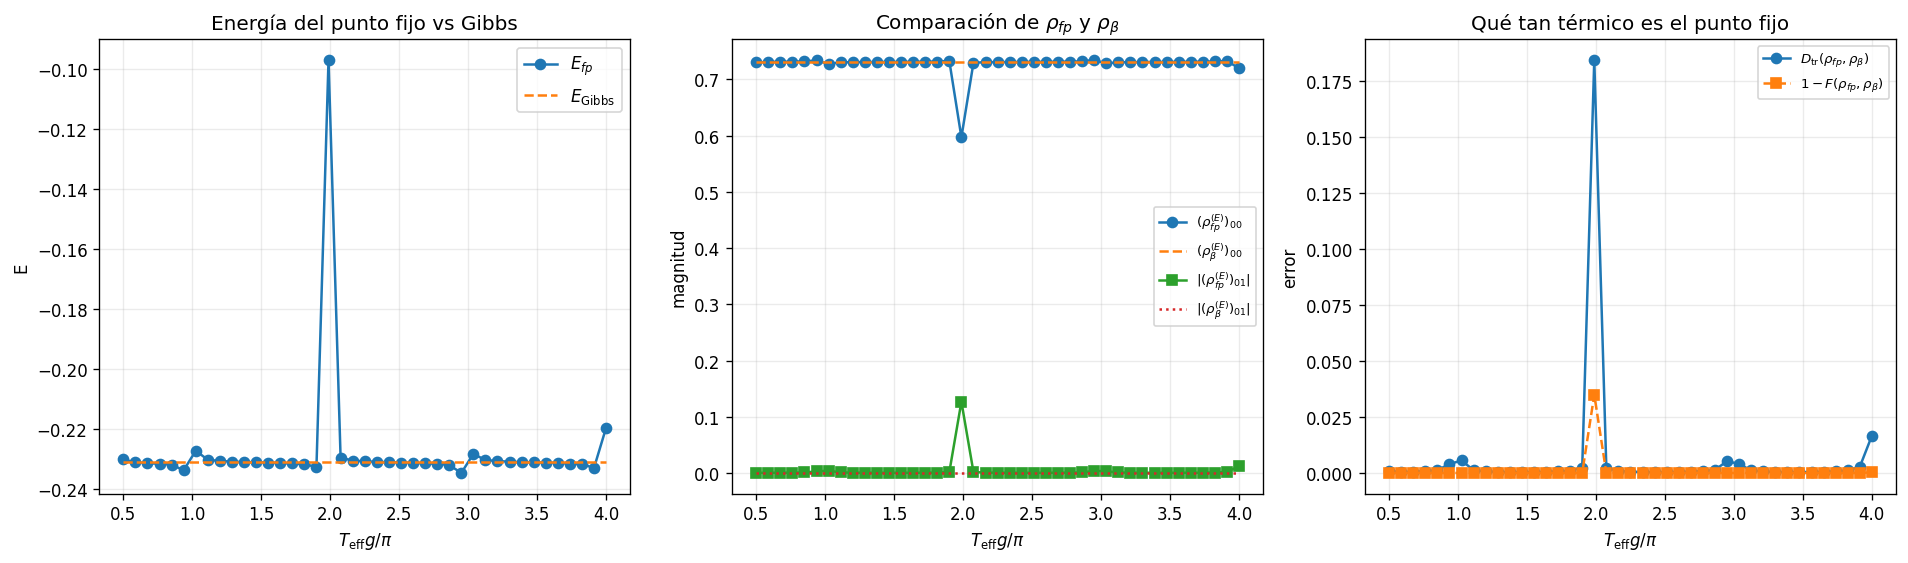

,T_over_pi_g,T_eff,MT,Egibbs,Efp,E_bias_abs,p_g_fp,p_e_fp,p_g_gibbs,p_e_gibbs,abs_rho01_fp,abs_rho01_gibbs,Dtr_fp_gibbs,F_fp_gibbs
0,0.5000,1.570796,20,-0.231059,-0.230222,0.000837,0.730222,0.269778,0.731059,0.268941,0.000406,0.0,0.000930,0.999999
1,0.5875,1.845686,23,-0.231059,-0.231176,0.000117,0.731176,0.268824,0.731059,0.268941,0.000426,0.0,0.000442,1.000000
2,0.6750,2.120575,27,-0.231059,-0.231460,0.000401,0.731460,0.268540,0.731059,0.268941,0.000501,0.0,0.000642,1.000000
3,0.7625,2.395464,30,-0.231059,-0.231636,0.000578,0.731637,0.268363,0.731059,0.268941,0.000628,0.0,0.000853,0.999999
4,0.8500,2.670354,33,-0.231059,-0.231949,0.000890,0.731949,0.268051,0.731059,0.268941,0.000909,0.0,0.001273,0.999998
5,0.9375,2.945243,37,-0.231059,-0.233813,0.002754,0.733813,0.266187,0.731059,0.268941,0.002856,0.0,0.003968,0.999982
6,1.0250,3.220132,40,-0.231059,-0.227287,0.003771,0.727287,0.272713,0.731059,0.268941,0.004145,0.0,0.005604,0.999965
7,1.1125,3.495022,44,-0.231059,-0.230331,0.000727,0.730331,0.269669,0.731059,0.268941,0.001000,0.0,0.001236,0.999998
8,1.2000,3.769911,47,-0.231059,-0.230696,0.000362,0.730696,0.269304,0.731059,0.268941,0.000664,0.0,0.000756,0.999999
9,1.2875,4.044801,51,-0.231059,-0.230932,0.000126,0.730932,0.269068,0.731059,0.268941,0.000489,0.0,0.000505,1.000000


In [20]:
T_over_pi_grid = np.linspace(0.5, 4.0, 41)

scan_T_fp = single_spin_fp_vs_gibbs_Tscan(
    base_single_params,
    T_over_pi_grid=T_over_pi_grid,
    rho0=maximally_mixed(1),
    fp_mode="superop",
)

Las resonancias del protocolo OFF son físicas, no numéricas: aparecen cuando el tiempo de ciclo es conmensurable con la frecuencia de Bohr $\omega = g$, como predice la Ec. 42 del paper. El pico es máximo en $x = 2$ ($T = 2\pi/\omega$, dos periodos completos); en $x = 1$ y $x = 3$ también hay rastro pero más débil.



### A.4.2 Transitorios a $n_{cycles}$ finito


Ahora miramos el estado final después de un número finito de resets. Este bloque separa dos efectos:

1. sesgo del punto fijo respecto a Gibbs;
2. falta de convergencia cuando `n_cycles` es pequeño.

Por eso se comparan varios valores de `n_cycles`.


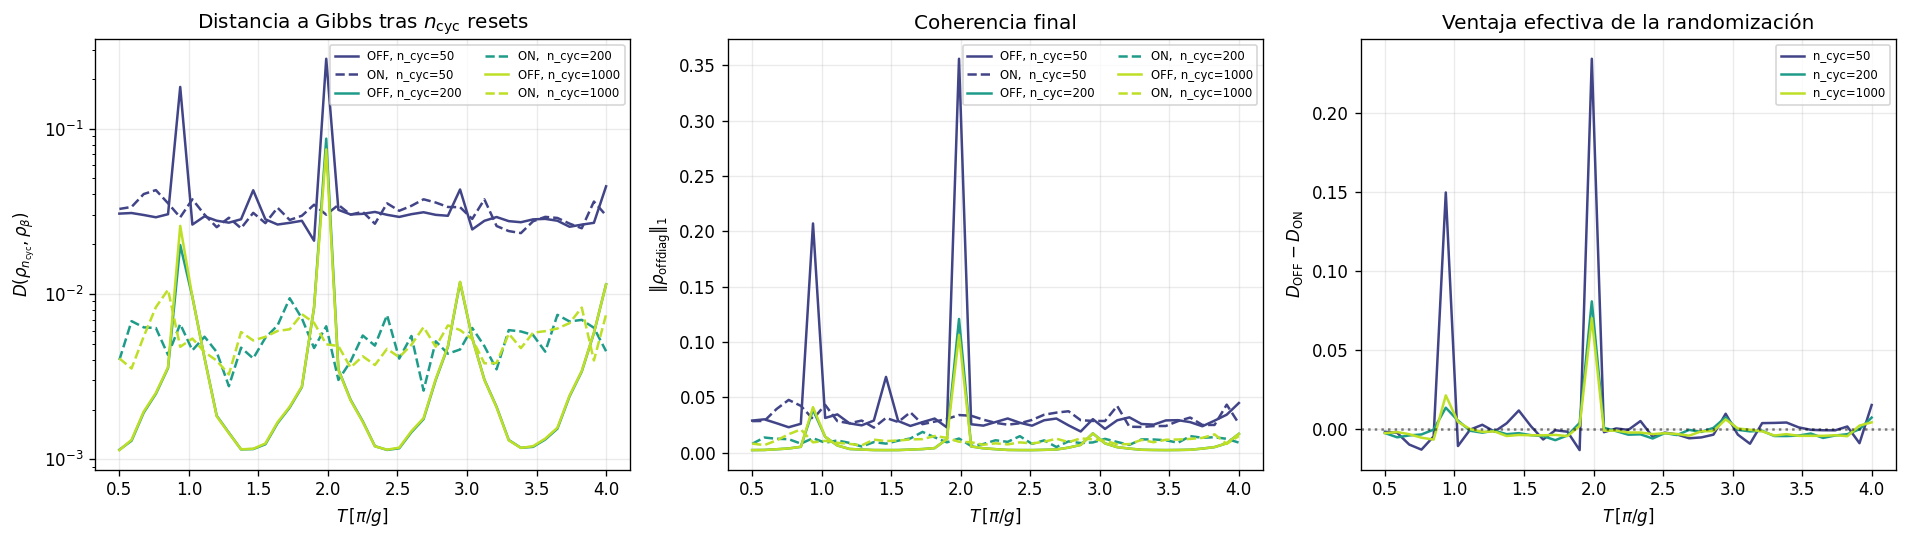

In [ ]:
# ============================================================
# A.4.2 — Transitorios a n_cycles finito
# ============================================================

rho0_plus = pure_dm(np.array([1, 1], dtype=complex) / np.sqrt(2))

params_Tscan = dict(base_single_params)
params_Tscan.update({
    "beta": 1.0,
    "theta": 0.25,
    "delta": 0.20,
})

g = params_Tscan["g"]
delta = params_Tscan["delta"]

# Eje x en unidades naturales de resonancia: x = T * g / π
x_grid = np.linspace(0.5, 4.0, 41)
T_grid = x_grid * np.pi / g

n_cycles_list = [50, 200, 1000]   # <-- el nuevo parámetro del estudio

seed_list = [101, 202, 303, 404, 505]
keys_avg = ["p_g", "coh_l1", "D_to_gibbs"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(n_cycles_list)))

for n_cycles, color in zip(n_cycles_list, colors):
    dist_off, coh_off = [], []
    dist_on,  coh_on  = [], []

    for T_val in T_grid:
        MT_val = max(int(round(T_val / delta)), 1)

        p_off = dict(params_Tscan, MT=MT_val, n_cycles=n_cycles,
                     randomize=False, randomization_lambda=0.0)
        out_off = run_single_spin_case(p_off, rho0=rho0_plus, compute_fp=False)
        met_off = rho_metrics_single_spin(
            out_off["res"]["rhos"][-1], out_off["Hs"], out_off["rho_g"])
        dist_off.append(met_off["D_to_gibbs"])
        coh_off.append(met_off["coh_l1"])

        mets_on = []
        for sd in seed_list:
            p_on = dict(params_Tscan, MT=MT_val, n_cycles=n_cycles,
                        randomize=True, randomization_lambda=1.0, seed=sd)
            out_on = run_single_spin_case(p_on, rho0=rho0_plus, compute_fp=False)
            mets_on.append(rho_metrics_single_spin(
                out_on["res"]["rhos"][-1], out_on["Hs"], out_on["rho_g"]))
        met_on = avg_dicts(mets_on, keys_avg)
        dist_on.append(met_on["D_to_gibbs"])
        coh_on.append(met_on["coh_l1"])

    axes[0].plot(x_grid, dist_off, "-",  color=color,
                 label=f"OFF, n_cyc={n_cycles}")
    axes[0].plot(x_grid, dist_on,  "--", color=color,
                 label=f"ON,  n_cyc={n_cycles}")
    axes[1].plot(x_grid, coh_off,  "-",  color=color,
                 label=f"OFF, n_cyc={n_cycles}")
    axes[1].plot(x_grid, coh_on,   "--", color=color,
                 label=f"ON,  n_cyc={n_cycles}")
    axes[2].plot(x_grid, np.array(dist_off) - np.array(dist_on), "-",
                 color=color, label=f"n_cyc={n_cycles}")

axes[0].set_xlabel(r"$T\,[\pi/g]$")
axes[0].set_ylabel(r"$D(\rho_{n_{\rm cyc}}, \rho_\beta)$")
axes[0].set_title(r"Distancia a Gibbs tras $n_{\rm cyc}$ resets")
axes[0].set_yscale("log")
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel(r"$T\,[\pi/g]$")
axes[1].set_ylabel(r"$\|\rho_{\rm offdiag}\|_1$")
axes[1].set_title("Coherencia final")
axes[1].legend(fontsize=7, ncol=2)

axes[2].set_xlabel(r"$T\,[\pi/g]$")
axes[2].set_ylabel(r"$D_{\rm OFF} - D_{\rm ON}$")
axes[2].set_title("Ventaja efectiva de la randomización")
axes[2].axhline(0, color="k", ls=":", alpha=0.5)
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

Desde $I/2$ y desde $|+\rangle\langle+|$ se llega al mismo atractor. Es lógico dado que ambos vienen del mismo canal del protocolo y esto es una simple confirmacion de ergodicidad del canal. La diferencia está en el transitorio: $|+\rangle$ permite ver mejor el decaimiento de coherencias.


### A.4.3 Traducción práctica a $M_T$

El barrido anterior usa la variable física $x=T_{\rm eff}g/\pi$. Aquí fijamos $\delta$ y barrimos directamente $M_T$, que es el parámetro discreto usado en el circuito.

No es física nueva: es la misma estructura de resonancias escrita en la variable que hay que elegir para las simulaciones.

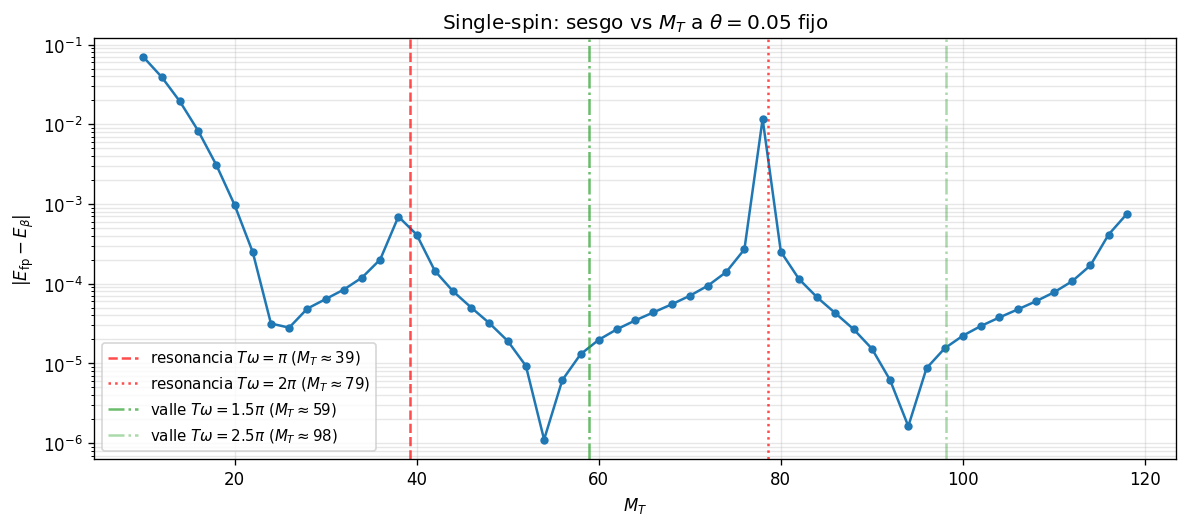

In [4]:
# A.4.2 — barrido fino de MT a theta pequeño para resolver resonancias

MT_fine = np.arange(10, 120, 2)
theta_fixed = 0.05

bias_mt = []
for MT_v in MT_fine:
    p = dict(base_single_params, theta=theta_fixed, MT=int(MT_v),
             n_cycles=250)
    out = run_single_spin_case(p, rho0=maximally_mixed(1),
                                compute_fp=True, fp_mode="superop")
    bias_mt.append(abs(out["Efp"] - out["Eg"]))

# Posiciones de resonancia y valle (teóricas)
delta_used = base_single_params["delta"]
g_used     = base_single_params["g"]
MT_res1 = np.pi / (delta_used * g_used)
MT_res2 = 2 * np.pi / (delta_used * g_used)
MT_val1 = 1.5 * np.pi / (delta_used * g_used)
MT_val2 = 2.5 * np.pi / (delta_used * g_used)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogy(MT_fine, bias_mt, "o-", ms=4, color="tab:blue")

ax.axvline(MT_res1, color="red", ls="--", alpha=0.7,
           label=rf"resonancia $T\omega = \pi$ ($M_T \approx {MT_res1:.0f}$)")
ax.axvline(MT_res2, color="red", ls=":", alpha=0.7,
           label=rf"resonancia $T\omega = 2\pi$ ($M_T \approx {MT_res2:.0f}$)")
ax.axvline(MT_val1, color="tab:green", ls="-.", alpha=0.7,
           label=rf"valle $T\omega = 1.5\pi$ ($M_T \approx {MT_val1:.0f}$)")
ax.axvline(MT_val2, color="tab:green", ls="-.", alpha=0.4,
           label=rf"valle $T\omega = 2.5\pi$ ($M_T \approx {MT_val2:.0f}$)")

ax.set_xlabel(r"$M_T$")
ax.set_ylabel(r"$|E_{\rm fp} - E_\beta|$")
ax.set_title(rf"Single-spin: sesgo vs $M_T$ a $\theta = {theta_fixed}$ fijo")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

- Para $M_T$ pequeño domina el truncamiento del filtro.
- Los picos aparecen cerca de $T_{\rm eff}g=k\pi$.
- Los valles entre picos son las regiones buenas para elegir $M_T.$
- Operativamente conviene escoger $M_T$ en un valle, lejos de las resonancias principales.

### A.4.4 Diagnóstico espectral del atractor

Una vez localizadas las resonancias, comprobamos si el canal sigue teniendo un único atractor. Para ello estudiamos el segundo autovalor del superoperador.

Si $|\lambda_2|<1$, el punto fijo es atractivo. Si $|\lambda_2|$ se acerca a 1, la mezcla se vuelve lenta.

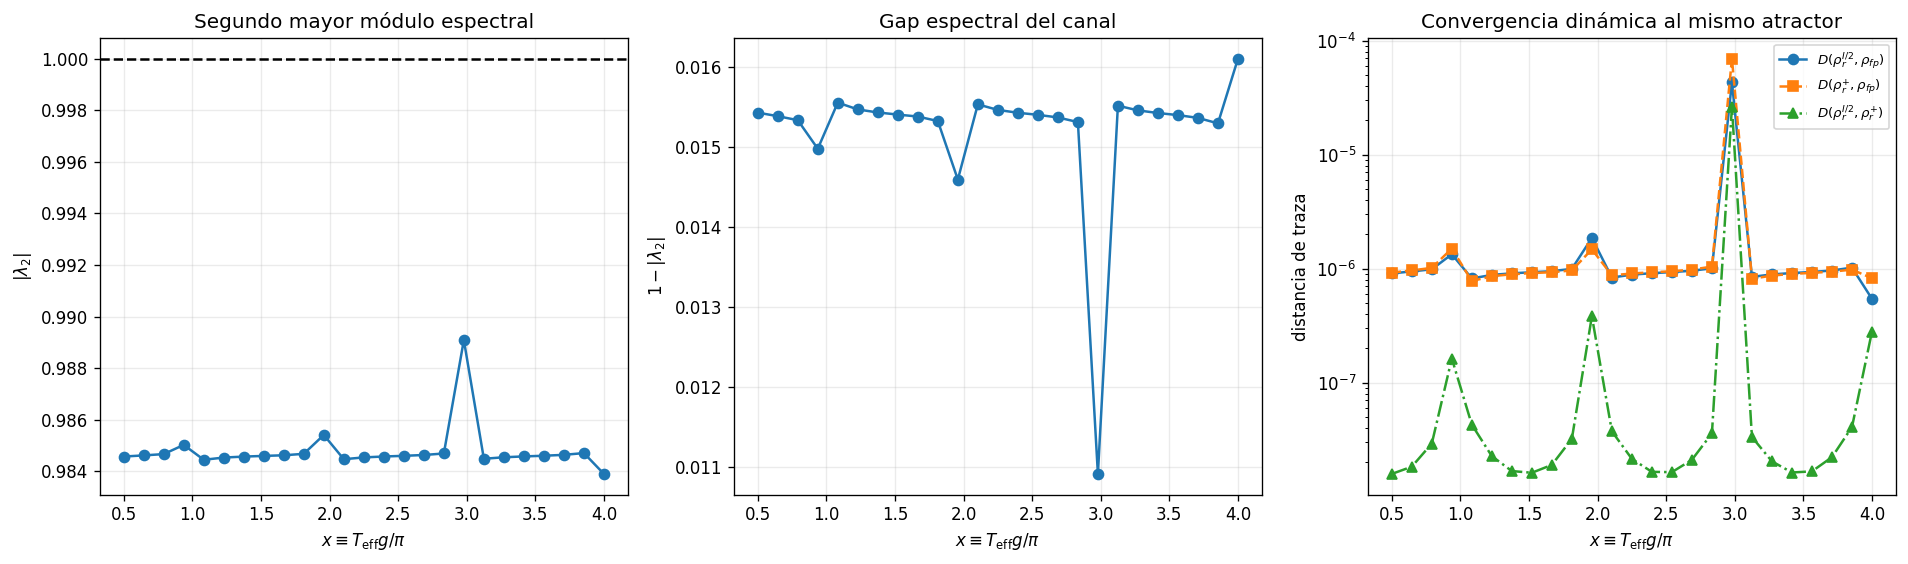

,x_Teff_g_over_pi,MT,mult_lambda_1,n_unit_modulus,|lambda2|,gap_1-|lambda2|,"D(final_I2, fp)","D(final_plus, fp)","D(final_I2, final_plus)",unique_attractor_likely,dynamic_convergence_likely
0,0.500000,20,1,1,0.984568,0.015432,0.000001,0.000001,0.000000,True,True
1,0.645833,25,1,1,0.984612,0.015388,0.000001,0.000001,0.000000,True,True
2,0.791667,31,1,1,0.984663,0.015337,0.000001,0.000001,0.000000,True,True
3,0.937500,37,1,1,0.985020,0.014980,0.000001,0.000002,0.000000,True,True
4,1.083333,43,1,1,0.984443,0.015557,0.000001,0.000001,0.000000,True,True
5,1.229167,48,1,1,0.984528,0.015472,0.000001,0.000001,0.000000,True,True
6,1.375000,54,1,1,0.984566,0.015434,0.000001,0.000001,0.000000,True,True
7,1.520833,60,1,1,0.984593,0.015407,0.000001,0.000001,0.000000,True,True
8,1.666667,65,1,1,0.984617,0.015383,0.000001,0.000001,0.000000,True,True
9,1.812500,71,1,1,0.984673,0.015327,0.000001,0.000001,0.000000,True,True


In [24]:
params_diag = dict(base_single_params, n_cycles=800)

xgrid_diag = make_xgrid(0.5, 4.0, 25)

diag_df = diagnose_single_spin_attractor_over_T(
    params_diag,
    xgrid=xgrid_diag,
    rho0_a=maximally_mixed(1),
    rho0_b=pure_dm(np.array([1, 1], dtype=complex) / np.sqrt(2)),
)


El canal mantiene $|\lambda_2|<1$, así que no pierde unicidad del punto fijo. Cerca de algunas resonancias el gap disminuye y la mezcla se ralentiza, pero esto no implica necesariamente mayor sesgo respecto a Gibbs. El gap mide velocidad de convergencia $\sim|λ₂|^n$; el sesgo mide dónde está el punto fijo.

### A.4.5 Randomización OFF vs ON

Comparamos el canal determinista con el canal randomizado. En OFF calculamos el punto fijo exacto por superoperador. En ON usamos una media late-time y promedio sobre semillas.

El objetivo es ver si la randomización suaviza resonancias y reduce coherencias residuales.

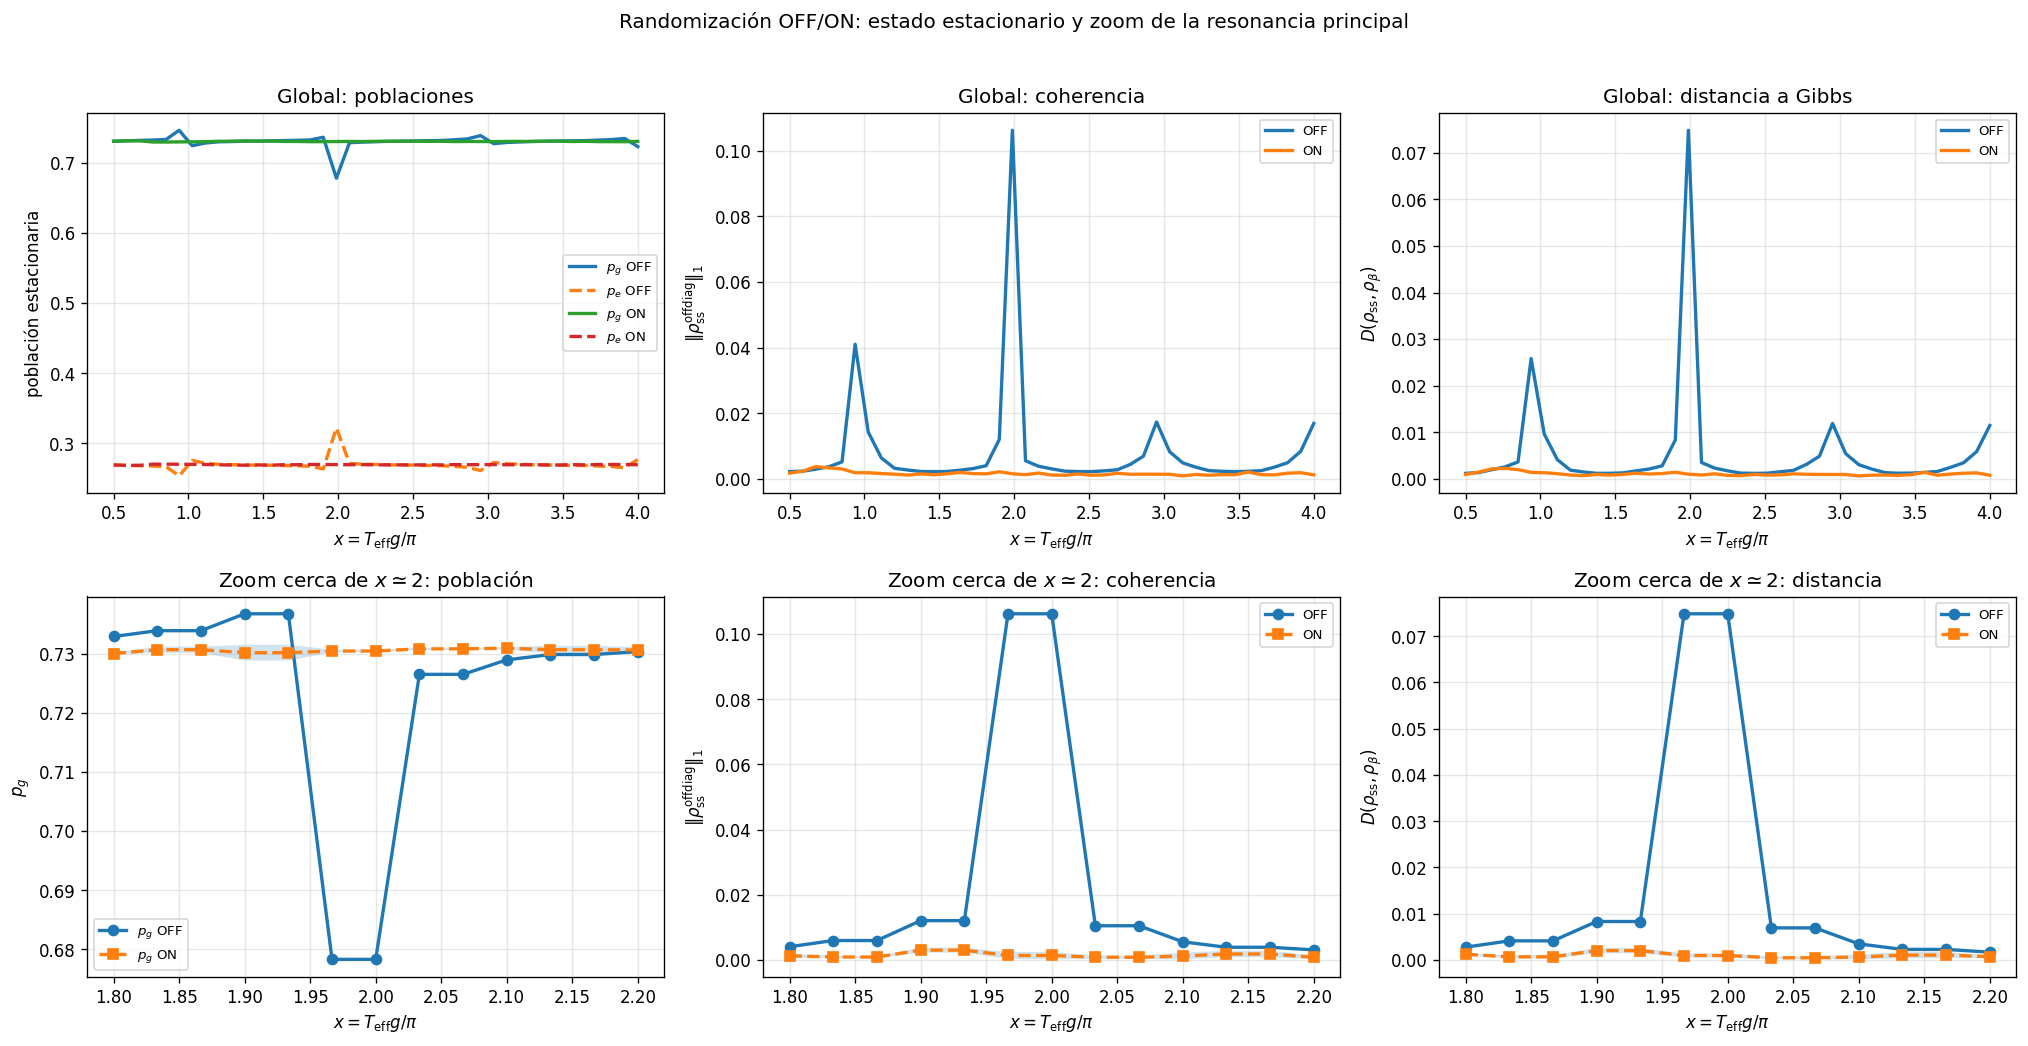

,x,MT,pg_off,pg_on_mean,pg_on_std,coh_off,coh_on_mean,coh_on_std,dist_off,dist_on_mean,dist_on_std
0,1.800000,28,0.732934,0.730043,0.000105,0.004052,0.001263,0.000711,0.002761,0.001221,0.000215
1,1.833333,29,0.733916,0.730694,0.000525,0.005948,0.000890,0.000297,0.004124,0.000668,0.000353
2,1.866667,29,0.733916,0.730694,0.000525,0.005948,0.000890,0.000297,0.004124,0.000668,0.000353
3,1.900000,30,0.736778,0.730194,0.001338,0.012048,0.003000,0.000767,0.008306,0.002019,0.000567
4,1.933333,30,0.736778,0.730194,0.001338,0.012048,0.003000,0.000767,0.008306,0.002019,0.000567
5,1.966667,31,0.678285,0.730474,0.000231,0.106176,0.001363,0.001096,0.074856,0.000955,0.000442
6,2.000000,31,0.678285,0.730474,0.000231,0.106176,0.001363,0.001096,0.074856,0.000955,0.000442
7,2.033333,32,0.726527,0.730842,0.000189,0.010479,0.000820,0.000490,0.006928,0.000466,0.000304
8,2.066667,32,0.726527,0.730842,0.000189,0.010479,0.000820,0.000490,0.006928,0.000466,0.000304
9,2.100000,33,0.728977,0.730946,0.000197,0.005557,0.001190,0.001027,0.003472,0.000627,0.000513


In [14]:
# ============================================================
# A.4.5 — Randomización OFF/ON: barrido global + zoom
# ============================================================

rho0_fp = maximally_mixed(1)

# Barrido global
df_fp_scan = scan_stationary_off_on_vs_x(
    runner=run_single_spin_case,
    base_params=base_single_params,
    x_grid=np.linspace(0.5, 4.0, 41),
    metrics_fn=rho_metrics_single_spin,
    rho0=rho0_fp,
    beta=1.0,
    theta=0.25,
    delta=0.20,
    n_cycles=600,
    seed_list=[101, 202, 303, 404, 505, 606, 707, 808, 909, 1001],
    verbose=False,
)

# Zoom cerca del pico principal
df_zoom = scan_stationary_off_on_vs_x(
    runner=run_single_spin_case,
    base_params=base_single_params,
    x_grid=np.linspace(1.8, 2.2, 13),
    metrics_fn=rho_metrics_single_spin,
    rho0=rho0_fp,
    beta=1.0,
    theta=0.25,
    delta=0.20,
    n_cycles=250,
    seed_list=[101, 202, 303],
    verbose=False,
)

plot_stationary_off_on_global_and_zoom(
    df_fp_scan,
    df_zoom,
    title="Randomización OFF/ON: estado estacionario y zoom de la resonancia principal",
)

display(
    df_zoom[[
        "x", "MT",
        "pg_off", "pg_on_mean", "pg_on_std",
        "coh_off", "coh_on_mean", "coh_on_std",
        "dist_off", "dist_on_mean", "dist_on_std",
    ]].round(6)
)

Este es el diagnóstico principal del efecto de la randomización: compara el estado estacionario OFF/ON en la misma variable $x=T_{\rm eff}g/\pi$.

Hacemos zoom cerca de $x\simeq 2$, donde el canal determinista muestra la resonancia más clara. Este bloque no introduce física nueva; cuantifica localmente el efecto visto en el barrido global.


###  A.4.6  Randomización vs rewind

Por último comparamos cuatro variantes: protocolo base, solo randomización, solo rewind y ambos. El rewind se incluye como comparación inspirada en el Paper 2, no como ingrediente principal del notebook.

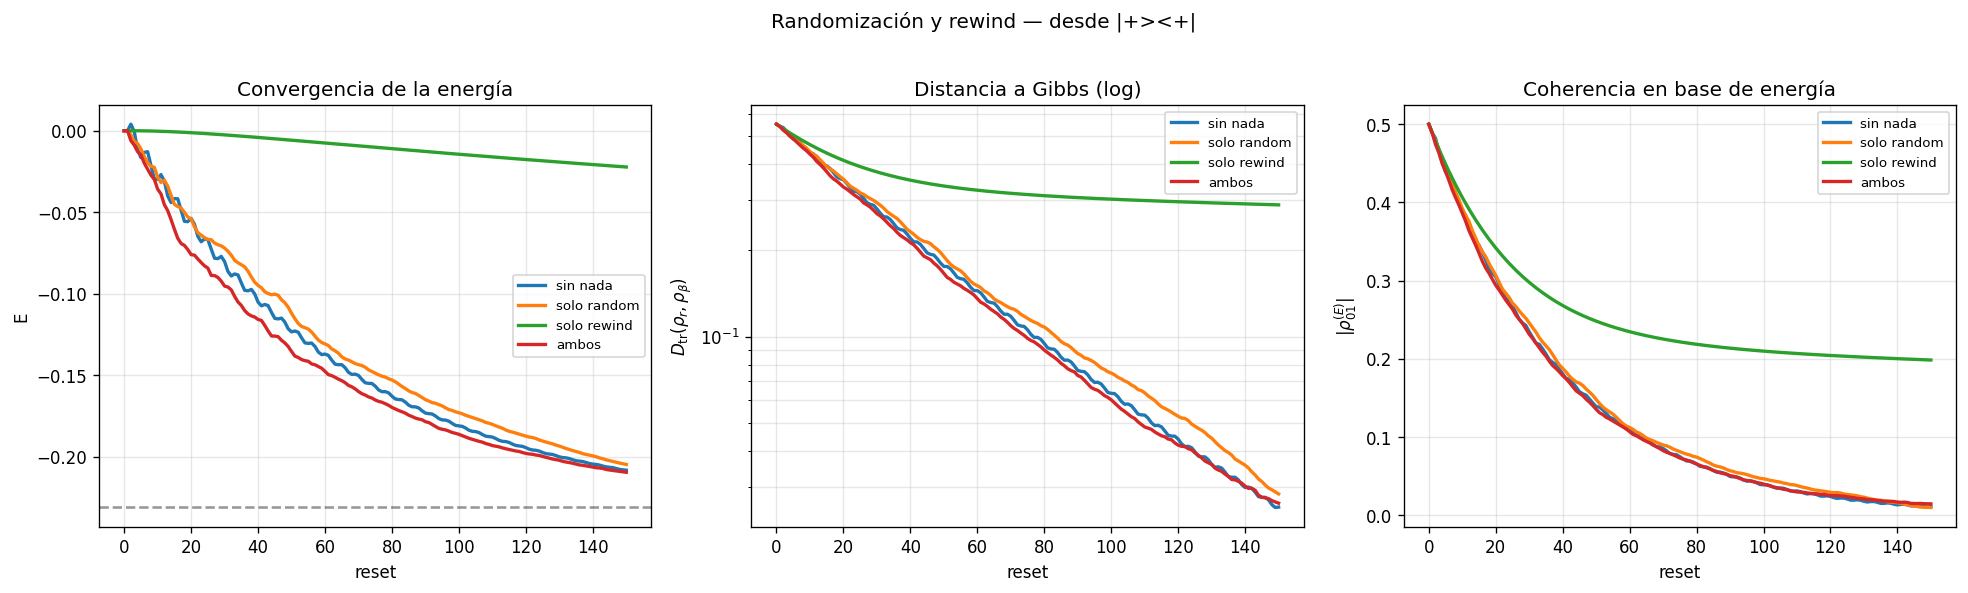

,variante,n_runs,E_fp_mean,Egibbs,|E_fp-Eg|_mean,"D_tr(fp,Gibbs)_mean","F(fp,Gibbs)_mean",pop_err_fp_mean,abs_rho01_final_mean
0,sin nada,1,-0.231636,-0.231059,0.000578,0.000853,0.999999,0.001156,0.011181
1,solo random,5,-0.222552,-0.231059,0.008506,0.008612,0.999904,0.017013,0.010083
2,solo rewind,1,-0.110948,-0.231059,0.120111,0.167135,0.971162,0.240222,0.198573
3,ambos,5,-0.223843,-0.231059,0.007215,0.007265,0.999931,0.014431,0.014724


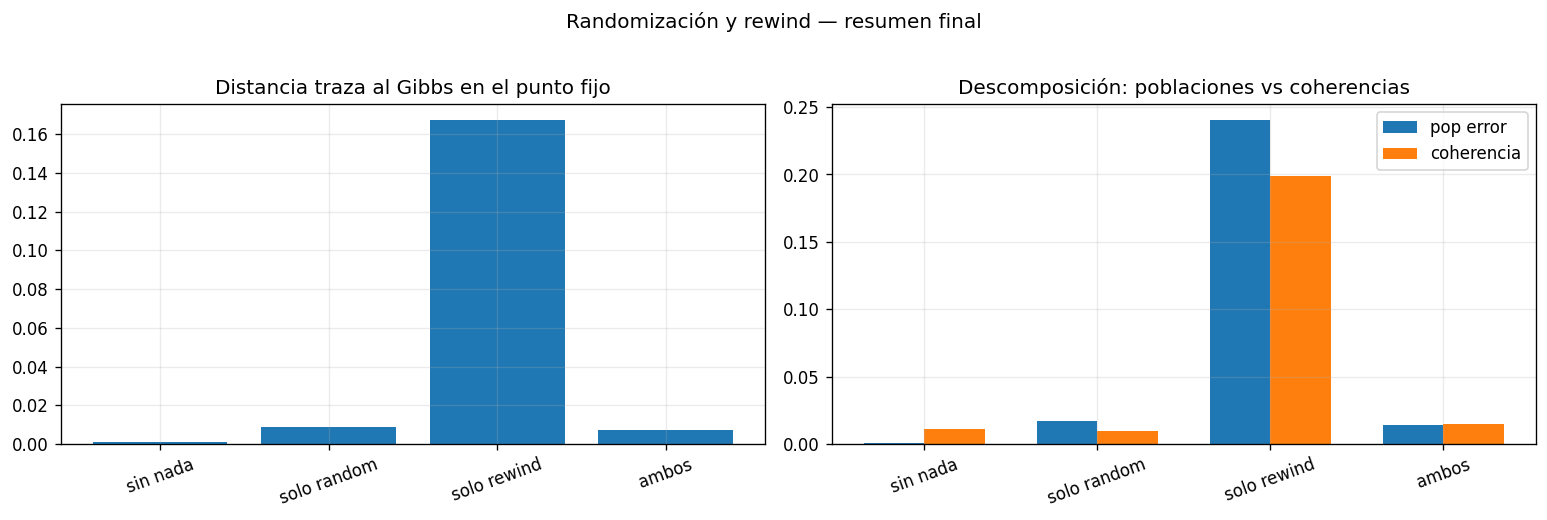

In [25]:
df_variants, outs_variants = compare_protocol_variants(
    runner=run_single_spin_case,
    base_params=base_single_params,
    variant_cases={
        "sin nada": {},
        "solo random": {"randomize": True, "randomization_lambda": 1.0},
        "solo rewind": {"rewind": True},
        "ambos": {"randomize": True, "randomization_lambda": 1.0, "rewind": True},
    },
    rho0=all_plus(1),
    fp_mode="auto",
    n_random_seeds=5,
    coherence_mode="single_spin_abs01",
    title="Randomización y rewind — desde |+><+|",
)

plot_protocol_variants_summary_bars(
    df_variants,
    coherence_col="abs_rho01_final_mean",
    title="Randomización y rewind — resumen final",
)

La randomización suaviza resonancias y reduce coherencias residuales. El rewind ayuda en algunos diagnósticos pero no domina.

## A.5  Escalado $θ²$ — resultado central del paper

El resultado principal de Lloyd & Abanin es que el punto fijo del canal
$\Phi$ aproxima el estado de Gibbs con un sesgo que escala cuadráticamente
en el acoplo sistema–baño:

$$
\|\sigma - \sigma_\beta\| \sim \theta^2 \qquad \text{para } \theta \to 0.
$$

Aquí lo verificamos directamente barriendo $\theta$ desde 0.03 hasta 0.22
y ajustando la pendiente en log–log para $\theta \le 0.12$. Si el
exponente ajustado es $\approx 2$, estamos en el régimen perturbativo que
el paper predice. Para $\theta$ mayores aparecen correcciones de orden
superior.

### A.5.1 Verificación digital del sesgo perturbativo $D(\rho_{\rm fp},\rho_\beta)\propto\theta^2$


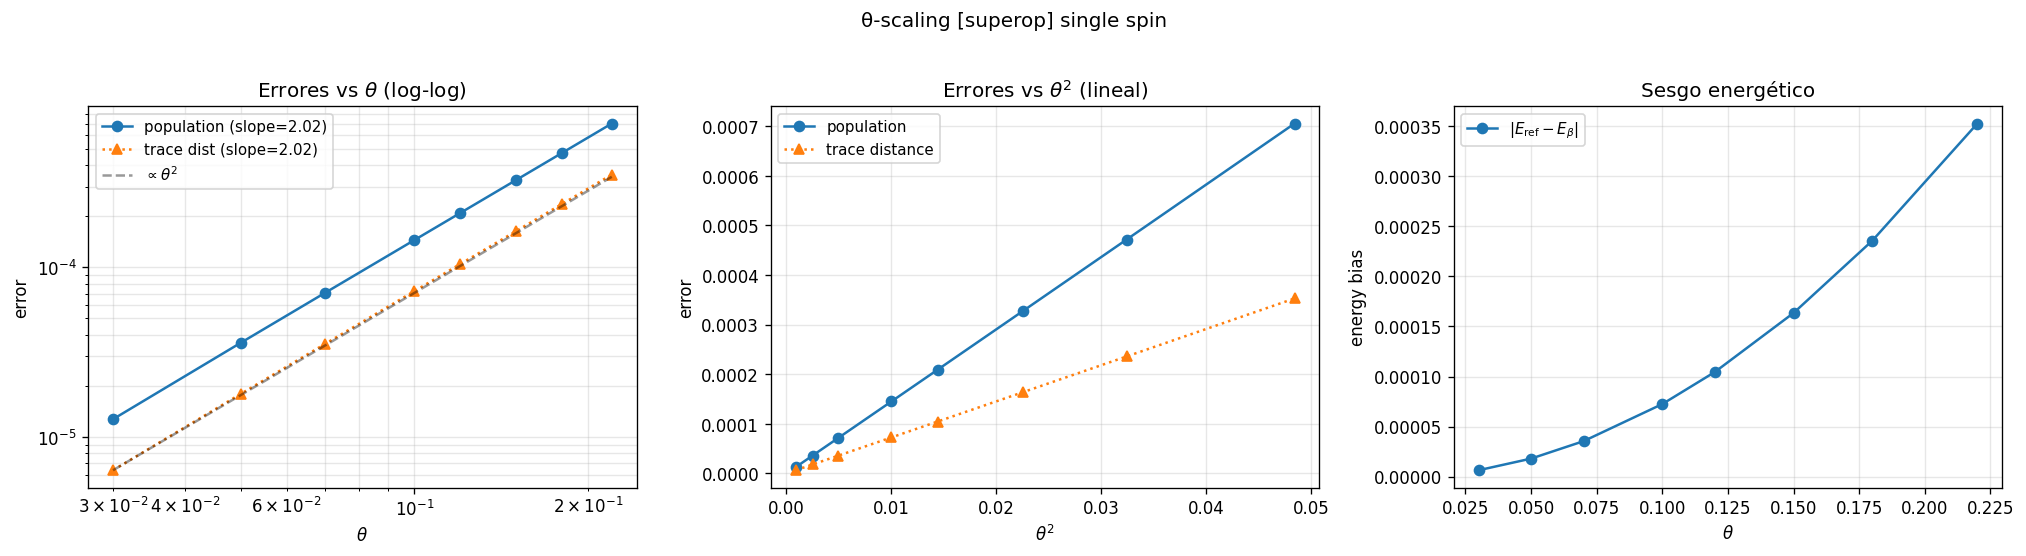

Pendientes log-log (θ ≤ 0.12): pop=2.02, coh=nan, dist=2.02
Método punto fijo: superop


,theta,theta2,population_error,coherence_error,trace_distance,fidelity,Egibbs,Eref,E_bias,fp_method,n_cycles_used
0,0.03,0.0009,0.000013,0.0,0.000006,1.0,-0.231059,-0.231065,0.000006,superop,150
1,0.05,0.0025,0.000036,0.0,0.000018,1.0,-0.231059,-0.231077,0.000018,superop,150
2,0.07,0.0049,0.000071,0.0,0.000035,1.0,-0.231059,-0.231094,0.000035,superop,150
3,0.10,0.0100,0.000145,0.0,0.000073,1.0,-0.231059,-0.231131,0.000073,superop,150
4,0.12,0.0144,0.000209,0.0,0.000105,1.0,-0.231059,-0.231163,0.000105,superop,150
5,0.15,0.0225,0.000327,0.0,0.000164,1.0,-0.231059,-0.231222,0.000164,superop,150
6,0.18,0.0324,0.000472,0.0,0.000236,1.0,-0.231059,-0.231294,0.000236,superop,150
7,0.22,0.0484,0.000706,0.0,0.000353,1.0,-0.231059,-0.231411,0.000353,superop,150


In [27]:
# A.5.1 — Escalado θ² (versión digital)
# El paper predice ||σ − σ_β||_1 ~ θ² en el régimen perturbativo.
# Para este barrido necesitamos: (i) randomización ACTIVA, (ii) A_S sencillo
# que no añada ruido al ajuste, (iii) rango θ que cubra régimen débil y
# salida de él para ver curvatura.

params_theta_scan = dict(base_single_params)
params_theta_scan.update({
    "sys_A": "Y",                   # Pauli puro: reduce ambigüedad del ajuste
    "randomize": True,              # suprime resonancias que ensuciarían el fit
    "randomization_lambda": 1.0,    # λ=1 es suficiente, el paper usa T_0=T
})

theta_grid = np.array([0.03, 0.05, 0.07, 0.10, 0.12, 0.15, 0.18, 0.22])

theta_df = theta_scaling_study(
    cfg_runner=run_single_spin_case,
    base_params=params_theta_scan,       # dict local, no pisa la global
    theta_grid=theta_grid,
    rho0=all_plus(1),
    fit_theta_max=0.12,
    fp_mode="superop",
    use_final_state=False,
    title_suffix="single spin",
    show_table=True,
)

### A.5.2 Límite analógico: escalado continuo del protocolo

El análisis perturbativo del paper predice que las correcciones estacionarias en poblaciones y coherencias escalan como $O(\theta^2)$ en el régimen de acoplo débil. En esta subsección se verifica dicha predicción para el caso single spin, comparando además protocolo randomizado y no randomizado.

A diferencia de la celda anterior, aquí se aísla el límite continuo del protocolo; la comparación con A.5.1 permite interpretar la discrepancia digital como error de trotterización asociado a discretizar la evolución filtrada en pasos de tamaño $\delta$.

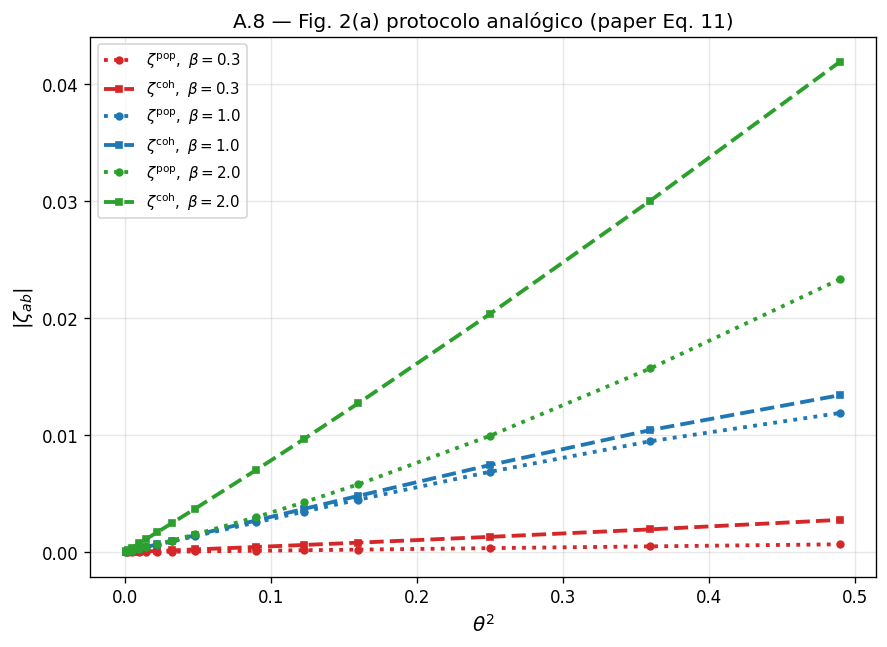

,beta,theta,theta2,T,Ta,abs_zeta_pop,abs_zeta_coh,unitarity_err
0,0.3,0.03,0.0009,1.369306,5.0,0.000001,0.000004,0.0
1,0.3,0.05,0.0025,1.369306,5.0,0.000003,0.000012,0.0
2,0.3,0.07,0.0049,1.369306,5.0,0.000006,0.000024,0.0
3,0.3,0.10,0.0100,1.369306,5.0,0.000014,0.000049,0.0
4,0.3,0.12,0.0144,1.369306,5.0,0.000020,0.000071,0.0
5,0.3,0.15,0.0225,1.369306,5.0,0.000031,0.000111,0.0
6,0.3,0.18,0.0324,1.369306,5.0,0.000045,0.000160,0.0
7,0.3,0.22,0.0484,1.369306,5.0,0.000068,0.000240,0.0
8,0.3,0.30,0.0900,1.369306,5.0,0.000127,0.000452,0.0
9,0.3,0.35,0.1225,1.369306,5.0,0.000173,0.000621,0.0


In [28]:
theta_grid = np.array([0.03, 0.05, 0.07, 0.10, 0.12, 0.15, 0.18, 0.22,
                       0.30, 0.35, 0.40, 0.50, 0.60, 0.70])
beta_grid = [0.3, 1.0, 2.0]

df_analog = figure2a_single_spin_ANALOG(
    theta_grid=theta_grid,
    beta_grid=beta_grid,
    g=1.0, h=1.0,
    sys_A="ZYmix", bath_A="Y",
    T_over_a=5.0,     # T = 5/a como en paper v1
    title="A.8 — Fig. 2(a) protocolo analógico (paper Eq. 11)",
)

display(df_analog.round(6))

## A.6  Termodinámica y régimen

### A.6.1 Capacidad calorífica: Gibbs vs punto fijo

Comparamos tres formas de calcular $C_V$:

1. exacta del estado de Gibbs, $C_V^{\rm Gibbs}(\beta) = \beta^2 \big(\langle H_S^2\rangle_{\rho_\beta} - \langle H_S\rangle_{\rho_\beta}^2\big)$;
2. del punto fijo del protocolo por varianza, $C_V^{\rm fp,var}(\beta) = \beta^2 \big(\langle H_S^2\rangle_{\rho_{\rm fp}} - \langle H_S\rangle_{\rho_{\rm fp}}^2\big)$;
3. del punto fijo por derivada numérica, $C_V^{\rm fp,fd}(T_{\rm th}) \approx dE_{\rm fp}/dT_{\rm th}$.

Si $\rho_{\rm fp} \approx \rho_\beta$, las tres curvas se solapan. Aquí la temperatura termodinámica es $T_{\rm th} = 1/\beta$, distinta del tiempo de ciclo $T\,[\pi/g]$ usado en los estudios de resonancia.

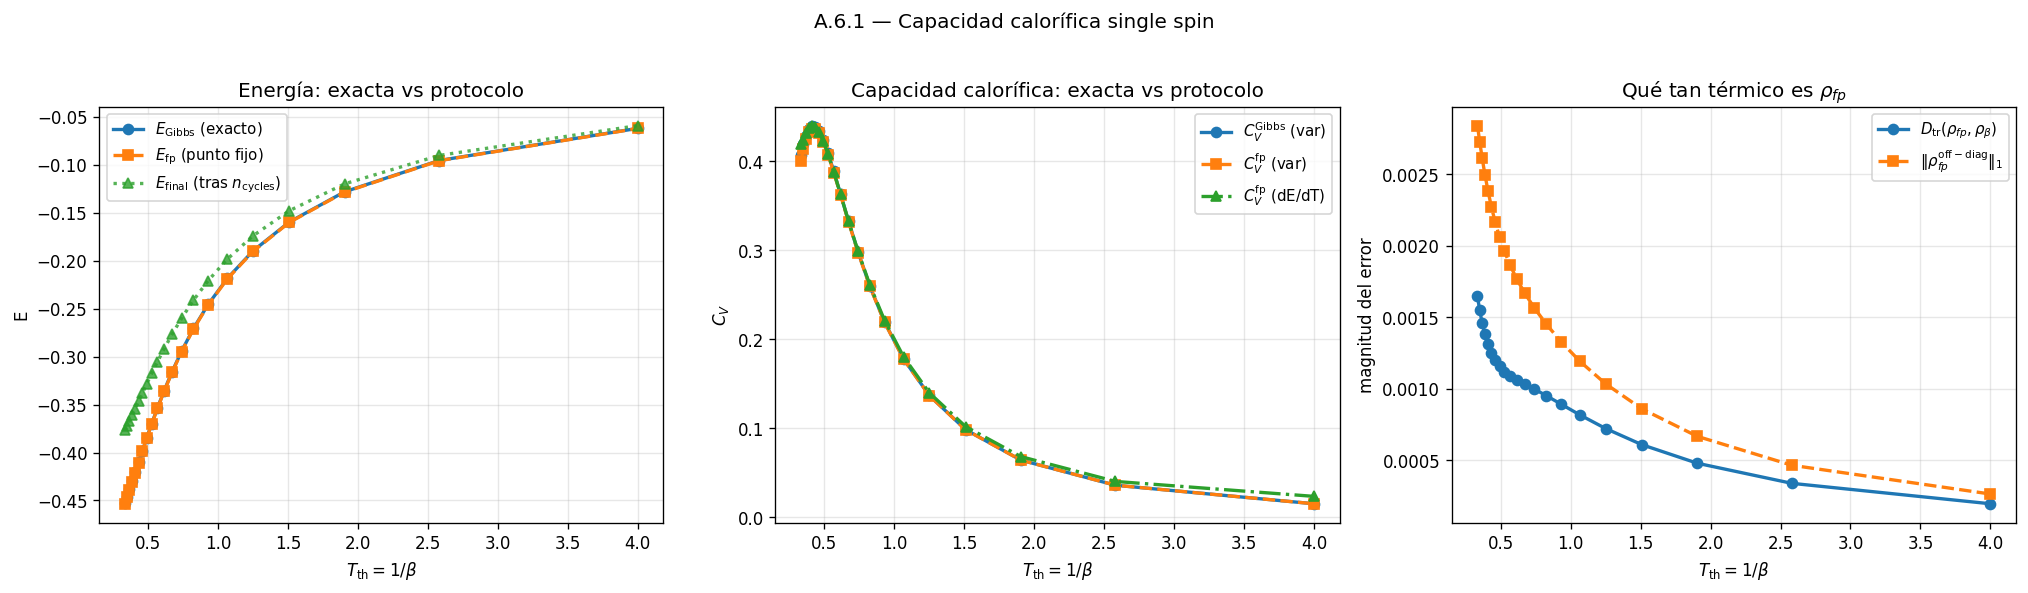

,beta,T_th,Egibbs,Efp,Efinal,Cv_gibbs_var,Cv_fp_var,Dtr_fp_gibbs,F_fp_gibbs,coh_fp_l1,Cv_gibbs_fd,Cv_fp_fd,dE_abs,dCv_var_abs,dCv_fd_abs
0,3.0000,0.333333,-0.452574,-0.453405,-0.376754,0.406590,0.399813,0.001646,0.999994,0.002840,0.413005,0.419077,0.000831,0.006777,0.006072
1,2.8625,0.349345,-0.445961,-0.446695,-0.372127,0.418861,0.413493,0.001548,0.999995,0.002727,0.418275,0.423636,0.000734,0.005368,0.005361
2,2.7250,0.366972,-0.438486,-0.439139,-0.366883,0.428683,0.424426,0.001460,0.999996,0.002612,0.428049,0.431974,0.000653,0.004257,0.003925
3,2.5875,0.386473,-0.430053,-0.430644,-0.360947,0.435551,0.432147,0.001382,0.999997,0.002498,0.434881,0.437512,0.000591,0.003404,0.002631
4,2.4500,0.408163,-0.420561,-0.421109,-0.354232,0.438951,0.436185,0.001312,0.999998,0.002385,0.438262,0.439792,0.000547,0.002766,0.001530
5,2.3125,0.432432,-0.409907,-0.410430,-0.346646,0.438381,0.436086,0.001252,0.999998,0.002274,0.437696,0.438352,0.000523,0.002294,0.000656
6,2.1750,0.459770,-0.397982,-0.398498,-0.338086,0.433374,0.431431,0.001200,0.999998,0.002166,0.432725,0.432751,0.000516,0.001944,0.000026
7,2.0375,0.490798,-0.384678,-0.385202,-0.328444,0.423537,0.421864,0.001156,0.999998,0.002062,0.422962,0.422598,0.000523,0.001673,0.000364
8,1.9000,0.526316,-0.369892,-0.370433,-0.317605,0.408581,0.407134,0.001120,0.999998,0.001961,0.408129,0.407587,0.000541,0.001447,0.000541
9,1.7625,0.567376,-0.353522,-0.354088,-0.305447,0.388369,0.387126,0.001089,0.999998,0.001863,0.388096,0.387549,0.000565,0.001242,0.000546


In [29]:
# A.6.1 — Capacidad calorífica fina
cv_fine_df = heat_capacity_fine_study(
    runner=run_single_spin_case,
    base_params=base_single_params,
    beta_grid=np.linspace(0.25, 3.0, 21),
    rho0=maximally_mixed(1),
    fp_mode="superop",
    title="A.6.1 — Capacidad calorífica single spin",
)

Las tres curvas de energía y las tres de $C_V$ se solapan dentro del ancho de línea: el protocolo reproduce la capacidad calorífica exacta del qubit en todo el rango $\beta \in [0.25, 3]$. El pico de $C_V$ aparece en $T_{\rm th} \approx g/2$, como corresponde al gap $g$ del sistema de dos niveles (Schottky anomaly). Una separación entre $E_{\rm final}$ y $E_{\rm fp}$ apuntaría a convergencia insuficiente; entre $E_{\rm fp}$ y $E_{\rm Gibbs}$ a sesgo físico del protocolo, escala $\sim \theta^2$ (A.5). Diferencias entre $C_V^{\rm fp,var}$ y $C_V^{\rm fp,fd}$ entre sí indicarían coherencias residuales en base de energía.

### A.6.2 Regímenes de acoplo: sesgo estacionario, gap y tiempo de mezcla

El protocolo define un canal discreto por ciclos, $\rho_{n+1}=\Phi(\rho_n)$: en cada ciclo el sistema interacciona con un baño auxiliar durante una ventana temporal finita y después el baño se descarta/resetear. Por tanto, hay que distinguir dos propiedades distintas del canal:

1. **Precisión estacionaria:** qué cerca queda el punto fijo real $\rho_{\rm fp}$ del Gibbs ideal $\rho_\beta$, medido con $D(\rho_{\rm fp},\rho_\beta)$.
2. **Velocidad de mezcla:** cuántos ciclos hacen falta para olvidar el estado inicial, controlado por el gap espectral $1-|\lambda_2|$ y por $\tau_{\rm mix}$.

En nuestro notebook, $\theta$ controla la intensidad efectiva del acoplo sistema-baño y juega el papel operativo del parámetro $\tau J$ del paper. Al barrer $\theta$ aparecen tres regímenes:

| Régimen | Condición orientativa | Qué ocurre | Lectura física |
|---|---:|---|---|
| **Débil / Lindblad-like** | $\theta \ll 1$ | $D(\rho_{\rm fp},\rho_\beta)$ es muy pequeño, pero el gap es pequeño y $\tau_{\rm mix}$ es grande. | Muy preciso, pero lento. Es el límite perturbativo donde aparece $D(\rho_{\rm fp},\rho_\beta)\sim\theta^2$. |
| **Intermedio** | $\theta\sim 0.1-0.35$ | El sesgo sigue siendo bajo y el gap ya es suficientemente grande. | Mejor ventana práctica: buen compromiso entre precisión y número de ciclos. |
| **Fuerte / más allá de Lindblad** | $\theta\sim 1$ | El canal mezcla muy rápido, pero $\rho_{\rm fp}$ se separa de $\rho_\beta$. | Rápido no significa mejor: el punto fijo deja de ser suficientemente Gibbs. |

La magnitud clave no es solo $n^*$ ni solo el gap, sino el compromiso entre sesgo estacionario, velocidad de mezcla y coste del circuito.

,theta,regime,MT,D_fp_Gibbs,n*_fp_eps=0.001,n*_Gibbs_eps=0.01,status_Gibbs,|lambda2|,gap,tau_mix_est_cycles
0,0.04,débil / perturbativo,60,0.000031,NaN,NaN,no observado: lento >700,0.998906,0.001094,6308.334993
1,0.06,débil / perturbativo,60,0.000069,NaN,NaN,no observado: lento >700,0.997537,0.002463,2801.407092
2,0.08,débil / perturbativo,60,0.000122,NaN,NaN,no observado: lento >700,0.995621,0.004379,1573.980554
3,0.10,débil / perturbativo,60,0.000191,NaN,457.0,alcanzado,0.993156,0.006844,1005.855458
4,0.12,intermedio,60,0.000276,550.0,317.0,alcanzado,0.990142,0.009858,697.242204
5,0.18,intermedio,60,0.000621,243.0,140.0,alcanzado,0.977791,0.022209,307.568184
6,0.25,intermedio,60,0.001201,125.0,71.0,alcanzado,0.957066,0.042934,157.413719
7,0.35,intermedio,60,0.002366,62.0,36.0,alcanzado,0.915461,0.084539,78.206186
8,0.50,fuerte / τJ≈1,60,0.004870,29.0,17.0,alcanzado,0.825487,0.174513,36.018760
9,0.70,fuerte / τJ≈1,60,0.009616,13.0,9.0,alcanzado,0.647165,0.352835,15.874276


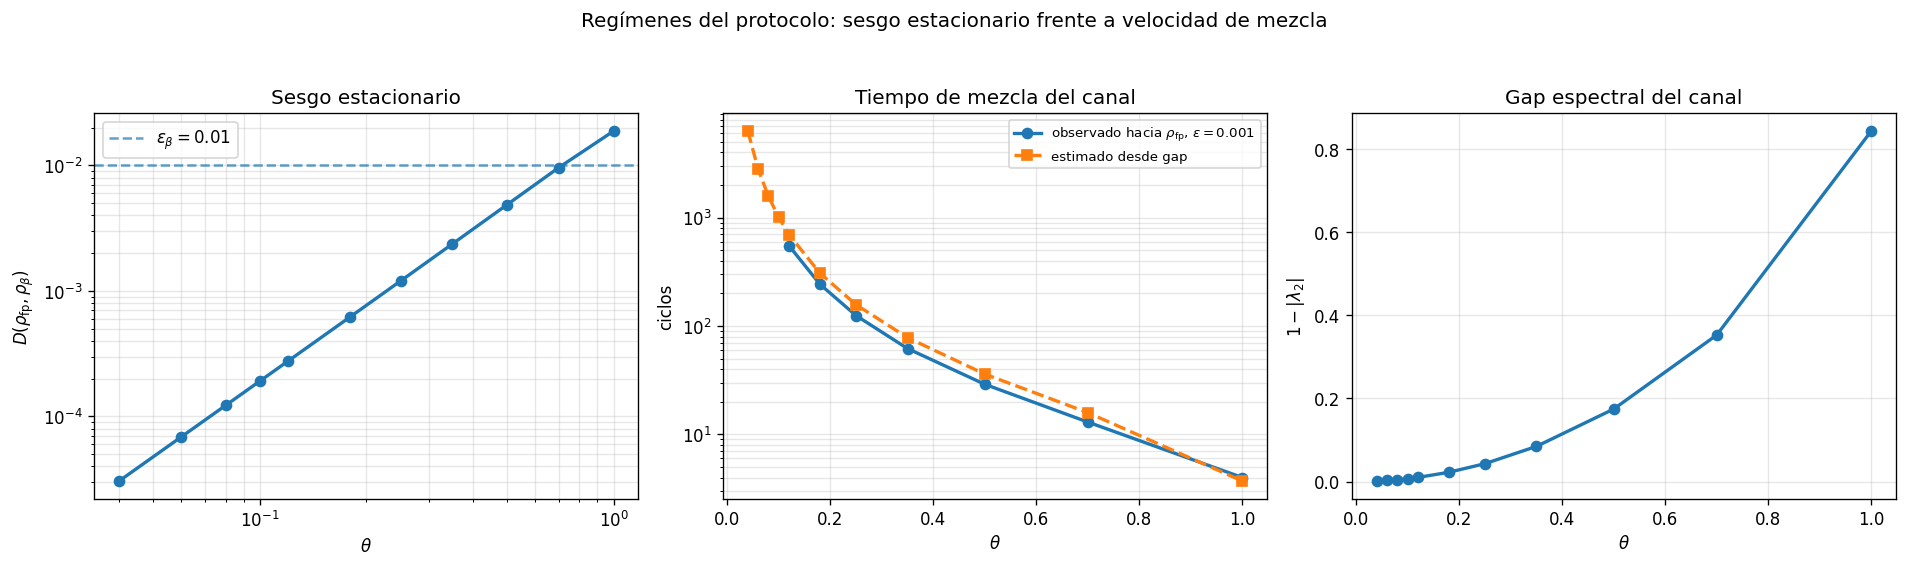

In [ ]:
# ============================================================
# A.6.2 — Regímenes de acoplo: precisión, mezcla y gap
# ============================================================

theta_grid_reg = np.array([0.04, 0.06, 0.08, 0.10, 0.12, 0.18, 0.25, 0.35, 0.50, 0.70, 1.00])

beta_reg = 1.0

# Umbral operativo para decir que una trayectoria ha llegado a Gibbs.
eps_gibbs = 1e-2

# Umbral más estricto para medir mezcla hacia el punto fijo del canal.
eps_fp = 1e-3

n_cycles_reg = 700

rows_reg = []

for theta in theta_grid_reg:
    p = dict(
        base_single_params,
        beta=beta_reg,
        theta=float(theta),
        n_cycles=n_cycles_reg,
        delta = np.pi/40,
        MT=60,
        randomize=False,
        randomization_lambda=0.0,
        rewind=False,
    )

    out = run_single_spin_case(
        p,
        rho0=maximally_mixed(1),
        compute_fp=True,
        fp_mode="superop",
    )

    rho_fp = out["rho_fp"]
    rho_g = out["rho_g"]

    d_to_fp = np.array([
        trace_distance_dm(rho, rho_fp)
        for rho in out["res"]["rhos"]
    ])

    d_to_gibbs = np.array([
        trace_distance_dm(rho, rho_g)
        for rho in out["res"]["rhos"]
    ])

    lambda2, gap = spectral_gap_from_compiled(out["compiled"])

    if 0 < lambda2 < 1:
        tau_mix_est = np.log(1 / eps_fp) / (-np.log(lambda2))
    else:
        tau_mix_est = np.nan

    MT_used = out["compiled"]["cfg"].MT
    layers_per_cycle = 2 * MT_used + 1

    D_fp_gibbs = float(trace_distance_dm(rho_fp, rho_g))

    nstar_fp = first_hitting_time(d_to_fp, eps_fp)
    nstar_gibbs = first_hitting_time(d_to_gibbs, eps_gibbs)

    status_g = gibbs_status(
        nstar_gibbs=nstar_gibbs,
        D_fp_gibbs=D_fp_gibbs,
        eps_gibbs=eps_gibbs,
        n_cycles=n_cycles_reg,
    )

    rows_reg.append({
        "theta": float(theta),
        "regime": classify_regime(theta),
        "MT": int(MT_used),
        "D_fp_Gibbs": D_fp_gibbs,
        f"n*_fp_eps={eps_fp}": nstar_fp,
        f"n*_Gibbs_eps={eps_gibbs}": nstar_gibbs,
        "status_Gibbs": status_g,
        "|lambda2|": lambda2,
        "gap": gap,
        "tau_mix_est_cycles": float(tau_mix_est),
        "layers_per_cycle": int(layers_per_cycle),
        "cost_to_fp_layers": (
            float(nstar_fp * layers_per_cycle)
            if np.isfinite(nstar_fp)
            else np.nan
        ),
    })

df_regimes = pd.DataFrame(rows_reg)

display_cols = [
    "theta",
    "regime",
    "MT",
    "D_fp_Gibbs",
    f"n*_fp_eps={eps_fp}",
    f"n*_Gibbs_eps={eps_gibbs}",
    "status_Gibbs",
    "|lambda2|",
    "gap",
    "tau_mix_est_cycles",
]

display(df_regimes[display_cols].round(6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: sesgo estacionario
axes[0].loglog(df_regimes["theta"], df_regimes["D_fp_Gibbs"], "o-", lw=2)
axes[0].axhline(eps_gibbs, ls="--", alpha=0.7, label=rf"$\epsilon_\beta={eps_gibbs}$")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel(r"$D(\rho_{\rm fp},\rho_\beta)$")
axes[0].set_title("Sesgo estacionario")
axes[0].legend()
axes[0].grid(alpha=0.3, which="both")

# Panel 2: tiempo de mezcla hacia el punto fijo
col_fp = f"n*_fp_eps={eps_fp}"

axes[1].plot(
    df_regimes["theta"],
    df_regimes[col_fp],
    "o-",
    lw=2,
    label=rf"observado hacia $\rho_{{\rm fp}}$, $\epsilon={eps_fp}$",
)

axes[1].plot(
    df_regimes["theta"],
    df_regimes["tau_mix_est_cycles"],
    "s--",
    lw=2,
    label="estimado desde gap",
)

axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel("ciclos")
axes[1].set_title("Tiempo de mezcla del canal")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

# Panel 3: gap espectral
axes[2].plot(df_regimes["theta"], df_regimes["gap"], "o-", lw=2)
axes[2].set_xlabel(r"$\theta$")
axes[2].set_ylabel(r"$1-|\lambda_2|$")
axes[2].set_title("Gap espectral del canal")
axes[2].grid(alpha=0.3)

plt.suptitle("Compromiso del protocolo: precisión Gibbs frente a velocidad de mezcla", y=1.04)
plt.tight_layout()
plt.show()

La tabla cuantifica este compromiso. Para $\theta$ pequeño, el sesgo $D(\rho_{\rm fp},\rho_\beta)$ es mínimo, pero $\tau_{\rm mix}$ es muy grande. Para $\theta$ grande, el gap aumenta y $\tau_{\rm mix}$ cae drásticamente, pero el punto fijo deja de estar dentro del umbral Gibbs elegido. La ventana óptima es intermedia: suficientemente rápida, pero todavía perturbativa.

### A.6.3 Test negativo de Mpemba en $d=2$

Aquí comprobamos explícitamente si el canal single-spin muestra un efecto Mpemba. Para que la prueba sea física, fijamos una temperatura final $\beta_f$ y comparamos varios estados iniciales térmicos $\rho_{\beta_0}$. El criterio es directo: habría efecto Mpemba si un estado inicialmente más alejado del equilibrio final alcanza $\rho_{\beta_f}$ antes que otro estado inicialmente más cercano.

En un sistema de dos niveles con estados iniciales térmicos diagonales no esperamos inversión Mpemba robusta: la dinámica poblacional efectiva tiene esencialmente una única dirección lenta de relajación. Por tanto, este bloque funciona como test negativo controlado. No es una curiosidad; verifica que el notebook reproduce correctamente el caso donde no debe aparecer aceleración anómala.

,beta0,D_initial_to_target,n_star,reached
0,0.1,0.206913,136,True
1,0.3,0.157451,124,True
2,0.5,0.109435,108,True
3,1.0,0.001229,0,True
4,1.5,0.085689,97,True
5,2.0,0.148909,121,True
6,3.0,0.220685,139,True
7,5.0,0.261418,147,True
8,8.0,0.267776,148,True


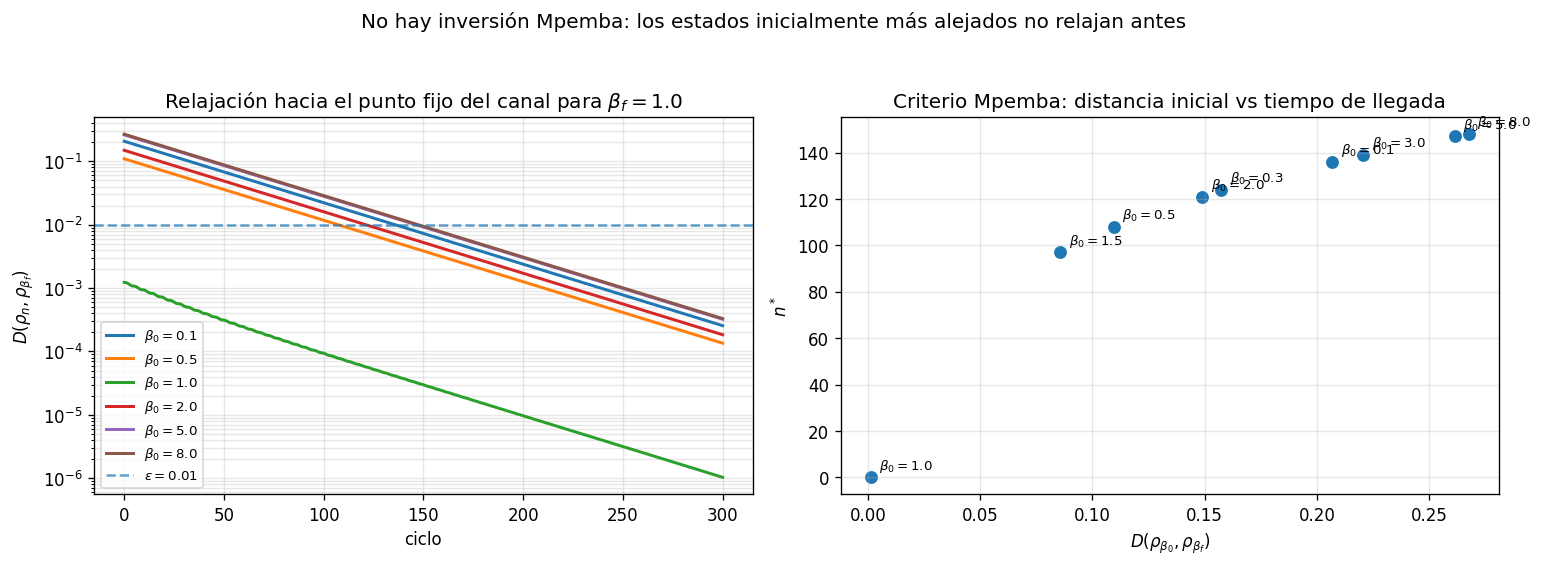

Veredicto: No hay inversión Mpemba: los estados inicialmente más alejados no relajan antes


In [ ]:
# ============================================================
# A.6.3 — Test negativo de Mpemba en d=2
# ============================================================

beta_final = 1.0
beta0_grid = np.array([0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0])

eps_mpemba = 1e-2
n_cycles_mpemba = 300

params_mpemba = dict(
    base_single_params,
    beta=beta_final,
    theta=0.18,
    MT=base_single_params["MT"],
    n_cycles=n_cycles_mpemba,
    randomize=False,
    randomization_lambda=0.0,
    rewind=False,
)

# Una ejecución auxiliar solo para fijar H y rho_target
out_ref = run_single_spin_case(
    params_mpemba,
    rho0=maximally_mixed(1),
    compute_fp=True,
    fp_mode="superop",
)

Hs = out_ref["Hs"]
rho_target = out_ref["rho_fp"]

rows_mpemba = []
trajectories_mpemba = {}

for beta0 in beta0_grid:
    rho0 = gibbs_from_H(Hs, beta0)

    out = run_single_spin_case(
        params_mpemba,
        rho0=rho0,
        compute_fp=False,
    )

    dists = np.array([
        trace_distance_dm(rho, rho_target)
        for rho in out["res"]["rhos"]
    ])

    n_star = first_hitting_time(dists, eps_mpemba)

    rows_mpemba.append({
        "beta0": float(beta0),
        "D_initial_to_target": float(dists[0]),
        "n_star": n_star,
        "reached": bool(np.isfinite(n_star)),
    })

    trajectories_mpemba[float(beta0)] = dists


df_mpemba = pd.DataFrame(rows_mpemba)
display(df_mpemba.round(6))

# Criterio de inversión Mpemba:
# existe un par i,j tal que D0_j > D0_i pero n*_j < n*_i.
df_reached = df_mpemba[df_mpemba["reached"]].copy()
inversions = []

for i in range(len(df_reached)):
    for j in range(len(df_reached)):
        row_i = df_reached.iloc[i]
        row_j = df_reached.iloc[j]

        farther = row_j["D_initial_to_target"] > row_i["D_initial_to_target"] + 1e-12
        faster = row_j["n_star"] < row_i["n_star"]

        if farther and faster:
            inversions.append((row_i["beta0"], row_j["beta0"]))

has_mpemba = len(inversions) > 0

verdict = (
    "Mpemba detectado"
    if has_mpemba
    else "No hay inversión Mpemba: los estados inicialmente más alejados no relajan antes"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for beta0, dists in trajectories_mpemba.items():
    if beta0 in [0.1, 0.5, 1.0, 2.0, 5.0, 8.0]:
        axes[0].semilogy(dists, lw=1.8, label=rf"$\beta_0={beta0}$")

axes[0].axhline(eps_mpemba, ls="--", alpha=0.7, label=rf"$\epsilon={eps_mpemba}$")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$D(\rho_n,\rho_{\beta_f})$")
axes[0].set_title(rf"Relajación hacia el punto fijo del canal para $\beta_f={beta_final}$")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, which="both")

axes[1].scatter(
    df_mpemba["D_initial_to_target"],
    df_mpemba["n_star"],
    s=45,
)
for _, row in df_mpemba.iterrows():
    axes[1].annotate(
        rf"$\beta_0={row['beta0']:.1f}$",
        (row["D_initial_to_target"], row["n_star"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

axes[1].set_xlabel(r"$D(\rho_{\beta_0},\rho_{\beta_f})$")
axes[1].set_ylabel(r"$n^*$")
axes[1].set_title("Criterio Mpemba: distancia inicial vs tiempo de llegada")
axes[1].grid(alpha=0.3)

plt.suptitle(verdict, y=1.04)
plt.tight_layout()
plt.show()

print("Veredicto:", verdict)
if has_mpemba:
    print("Pares con inversión Mpemba:", inversions)
    


El resultado es negativo de forma controlada: al fijar $\beta_f$ y comparar estados térmicos iniciales $\rho_{\beta_0}$, no aparece ningún par en el que un estado inicialmente más alejado del equilibrio llegue antes que uno más cercano. Esto es lo esperado para el single spin: con estados térmicos diagonales, la relajación poblacional efectiva no tiene suficientes modos lentos independientes como para producir una inversión Mpemba robusta.  Por tanto, el protocolo no produce una aceleración anómala espuria en $d=2$.

## A.7 Conclusiones de la capa exacta

En single spin hemos verificado que:

1. el canal converge al estado de Gibbs con sesgo $\|\sigma - \sigma_\beta\| \sim \theta^2$ (A.5), reproduciendo el resultado central del Paper de Abanin & Lloyd;
2. el atractor es el mismo desde $I/2$ y desde $|+\rangle$ (A.1); lo único que cambia es el transitorio;
3. $A_S \in \{X, Y\}$ son operativamente equivalentes por simetría con $H_S \propto Z$, mientras que $A_S = Z$ conmuta con $H_S$ y no genera transiciones de Bohr (A.2);
4. las resonancias $T = k\pi/\omega$ son físicas y se ven directamente en el punto fijo del canal; la randomización las suprime (A.3, A.4);
5. el rewind se introduce en el Paper de Hahn para implementar algorítmicamente el canal en el cuadro de interacción y poder demostrar cotas rigurosas $\|\tilde\sigma - \sigma_\beta\|_1 = \tilde{\mathcal{O}}(a\beta\tau_{\rm mix} N_B)$ sobre el error a Gibbs. En single spin reduce algo el sesgo poblacional pero su ventaja es marginal (A.4), de acuerdo con el argumento del Paper de Abanin & Lloyd de que el cuadro de Schrödinger captura efectos físicos que el rewind elimina;
6. la capacidad calorífica $C_V(\beta)$ del punto fijo coincide con la del Gibbs en todo el rango (A.6);
7. no hay efecto Mpemba, como se espera para $d = 2$ (A.6).

Lo que esta capa no contesta y motiva el paso a Qiskit: cómo se implementa el ciclo en un circuito real (B), cuál es el coste en CX y profundidad (B), cómo de sensibles son los observables al número de shots (C) y cuánto ruido tolera el protocolo antes de perder ventaja térmica (D).

# B. Capa Qiskit ideal

Aquí ya no se hace física exacta, sino preguntas de implementación: qué circuito ejecuta realmente Qiskit, si la simulación `density_matrix` reproduce el canal exacto, cómo escalan los recursos nativos con $M_T$ y con el número de ciclos, y cuánto se puede mover $(M_T,\delta)$ a $T = M_T\delta$ fijo sin que el error de Trotter degrade el resultado.

### B.1 Anatomía de un ciclo: filtro temporal, medida y reset

Antes de medir nada, miramos qué hay dentro de un ciclo: los pesos $f_\tau$ del filtro gaussiano, la caja lógica del ciclo completo y su descomposición a puertas nativas. Sirve para separar lo que es protocolo de lo que es compilación.

In [ ]:
# ============================================================
# B.0 — utilidades locales para B, C y D
# ============================================================

if not HAVE_QISKIT:
    raise RuntimeError("Qiskit/Aer no está disponible en este entorno.")

from qiskit_aer import AerSimulator
from qiskit import transpile

# Import robusto del constructor single-spin
try:
    build_single_spin_cfg
except NameError:
    from tfm_single_spin.model import build_single_spin_cfg

# Import robusto del compilador exacto
try:
    compile_protocol
except NameError:
    from tfm_shared.core import compile_protocol

NATIVE_BASIS = ["rz", "sx", "x", "cx", "measure", "reset"]


# Régimen "bueno" para la parte ideal
qk_params_good = dict(
    base_single_params,
    beta=1.0,
    theta=0.25,
    delta=0.08,
    MT=30,
    n_cycles=100,
    sys_A="ZYmix",
    bath_A="Y",
    randomize=False,
    rewind=False,
)

# Régimen pensado para visualizar shots sin hacer el notebook eterno
qk_params_shots = dict(qk_params_good, MT=15, n_cycles=25, theta=0.25)
#qk_params_shots = dict(qk_params_good)

# Régimen base para ruido
qk_params_noise = dict(qk_params_good, MT=20, n_cycles=30)
#qk_params_noise = dict(qk_params_good)

print("Utilidades B/C/D cargadas correctamente.")
print("qk_params_good =", qk_params_good)
print("qk_params_shots =", qk_params_shots)
print("qk_params_noise =", qk_params_noise)

Utilidades B/C/D cargadas correctamente.
qk_params_good = {'g': 1.0, 'h': 1.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.08, 'MT': 30, 'n_cycles': 100, 'sys_A': 'ZYmix', 'bath_A': 'Y', 'randomize': False, 'randomization_lambda': 0.0, 'seed': 1234, 'rewind': False}
qk_params_shots = {'g': 1.0, 'h': 1.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.08, 'MT': 15, 'n_cycles': 25, 'sys_A': 'ZYmix', 'bath_A': 'Y', 'randomize': False, 'randomization_lambda': 0.0, 'seed': 1234, 'rewind': False}
qk_params_noise = {'g': 1.0, 'h': 1.0, 'beta': 1.0, 'theta': 0.25, 'delta': 0.08, 'MT': 20, 'n_cycles': 30, 'sys_A': 'ZYmix', 'bath_A': 'Y', 'randomize': False, 'randomization_lambda': 0.0, 'seed': 1234, 'rewind': False}


Un ciclo apila $2M_T + 1$ capas $\mathcal{U}_\tau = e^{-i\delta\theta f_\tau A_S\otimes A_B}\, e^{-i\delta H_B}\, e^{-i\delta H_S}$ y termina con medida y reset del baño. Construimos a mano las tres capas centrales en un `QuantumCircuit` para ver la anatomía explícita.

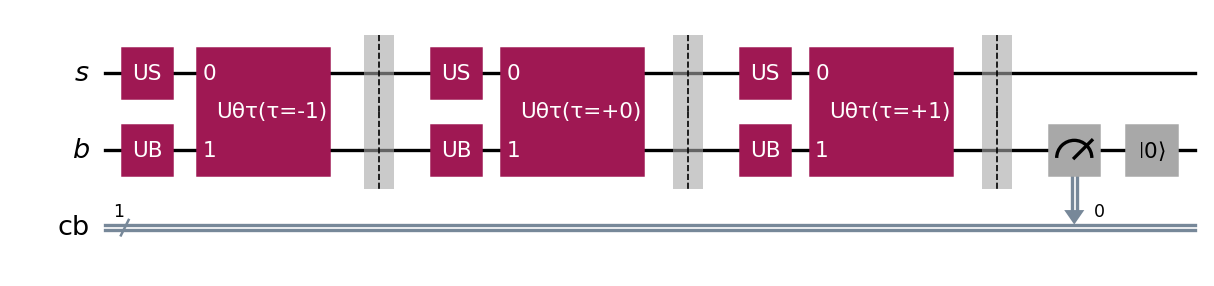

Capas mostradas: 3 centrales de 15 totales.
f_τ en esas capas: f_{-1}=0.7384, f_0=0.7999, f_{+1}=0.7384
Circuito 'de trabajo' equivalente: build_protocol_circuit(compiled, n_cycles=1).


In [6]:
# B.1 — construcción explícita paso a paso de 3 capas del ciclo
qk_params_demo = base_single_params.copy()
qk_params_demo.update({"theta": 0.25, "beta": 1.0, "MT": 7, "delta": 0.2})

cfg_demo      = build_single_spin_cfg(**qk_params_demo)
compiled_demo = compile_protocol(cfg_demo)

delta  = cfg_demo.delta
theta  = cfg_demo.theta
fvals  = compiled_demo["fvals"]

# Bloques elementales — construidos aquí para que se vea la anatomía.
# Nota: uso matrices de un qubit para US y UB (más pedagógico) y la
# matriz 2-qubit V_full_mat para el acoplo. Es la misma factorización
# que usa cycle_unitary_matrix() pero en el espacio reducido.
U_s_1q = expm(-1j * delta * compiled_demo["Hs_mat"])   # 2x2, solo sistema
U_b_1q = expm(-1j * delta * compiled_demo["Hb_mat"])   # 2x2, solo baño

q_s = QuantumRegister(1, "s")
q_b = QuantumRegister(1, "b")
c_b = ClassicalRegister(1, "cb")
qc_demo = QuantumCircuit(q_s, q_b, c_b)

# Muestro las 3 capas centrales (τ = -1, 0, +1): son las de mayor f_τ
central  = len(fvals) // 2
idx_show = [central - 1, central, central + 1]

for tau_idx in idx_show:
    f_tau = fvals[tau_idx]
    U_sb  = expm(-1j * delta * theta * f_tau * compiled_demo["V_full_mat"])  # 4x4

    qc_demo.append(UnitaryGate(U_s_1q, label="US"), [q_s[0]])
    qc_demo.append(UnitaryGate(U_b_1q, label="UB"), [q_b[0]])
    qc_demo.append(
        UnitaryGate(U_sb, label=f"Uθτ(τ={tau_idx - central:+d})"),
        [q_s[0], q_b[0]],
    )
    qc_demo.barrier()

# Cierre del ciclo: medida y reset del baño
qc_demo.measure(q_b[0], c_b[0])
qc_demo.reset(q_b[0])

display(qc_demo.draw("mpl", fold=-1))
print(f"Capas mostradas: 3 centrales de {2*cfg_demo.MT + 1} totales.")
print(
    f"f_τ en esas capas: "
    f"f_{{-1}}={fvals[central-1]:.4f}, "
    f"f_0={fvals[central]:.4f}, "
    f"f_{{+1}}={fvals[central+1]:.4f}"
)
print("Circuito 'de trabajo' equivalente: build_protocol_circuit(compiled, n_cycles=1).")

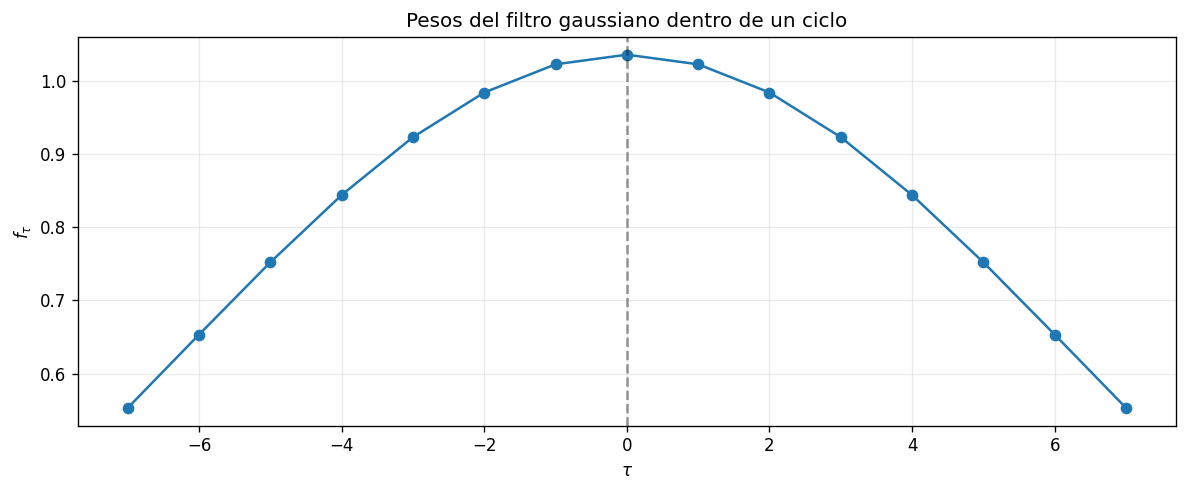

c:\Users\paula\miniconda3\envs\qiskit_env\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


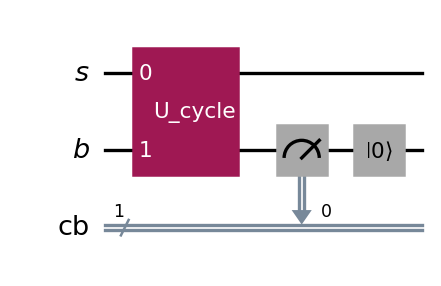

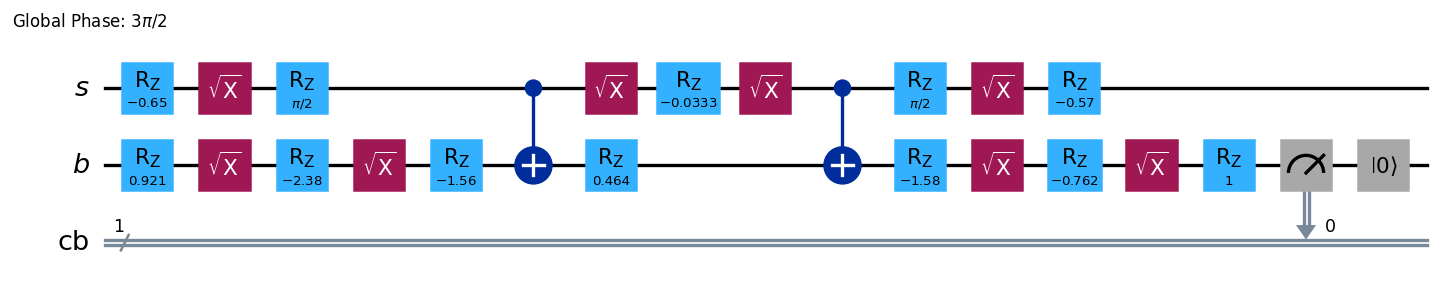

Número total de capas del ciclo: 15
Tres pesos centrales: f_-1=1.022559, f_0=1.035732, f_+1=1.022559
La medida y el reset del baño aparecen al final de cada ciclo.


In [7]:
# ============================================================
# B.1 — anatomía de un ciclo
# ============================================================

qk_params_demo = dict(qk_params_good, MT=7, n_cycles=1)
cfg_demo, compiled_demo = make_compiled_single_spin(qk_params_demo)

taus = compiled_demo["taus"]
fvals = compiled_demo["fvals"]
central = len(taus) // 2

fig, axes = plt.subplots(1, 1, figsize=(10, 4.2))

axes.plot(taus, fvals, "o-")
axes.axvline(0, ls="--", color="k", alpha=0.4)
axes.set_xlabel(r"$\tau$")
axes.set_ylabel(r"$f_\tau$")
axes.set_title("Pesos del filtro gaussiano dentro de un ciclo")


plt.tight_layout()
plt.show()

qc_box = build_protocol_circuit(
    compiled_demo,
    n_cycles=1,
    measure_bath=True,
    bath_measure_basis="Z",
)

backend = AerSimulator()
qc_native = transpile(
    qc_box,
    backend=backend,
    basis_gates=NATIVE_BASIS,
    optimization_level=0,
)

display(qc_box.draw("mpl"))


display(qc_native.draw("mpl", fold=-1))



print(f"Número total de capas del ciclo: {2 * cfg_demo.MT + 1}")
print(
    "Tres pesos centrales: "
    f"f_-1={fvals[central-1]:.6f}, "
    f"f_0={fvals[central]:.6f}, "
    f"f_+1={fvals[central+1]:.6f}"
)
print("La medida y el reset del baño aparecen al final de cada ciclo.")

### B.2 Transpilación a puertas nativas: `optimization_level = 0` frente a `3`

Aquí la pregunta no es física, sino de **ingeniería del circuito**:

- el nivel 0 conserva una compilación más directa;
- el nivel 3 intenta simplificar y cancelar puertas.

Lo importante es entender que **no cambia el protocolo lógico**, pero sí puede cambiar mucho:
- la profundidad,
- el tamaño,
- y el número de puertas nativas.

c:\Users\paula\miniconda3\envs\qiskit_env\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


,optimization_level,depth,size,width,cx,rz,sx,x,measure,reset
0,0,85,120,7,10,60,40,0,5,5
1,3,85,116,7,10,56,40,0,5,5


Circuito nativo a optimization_level=3


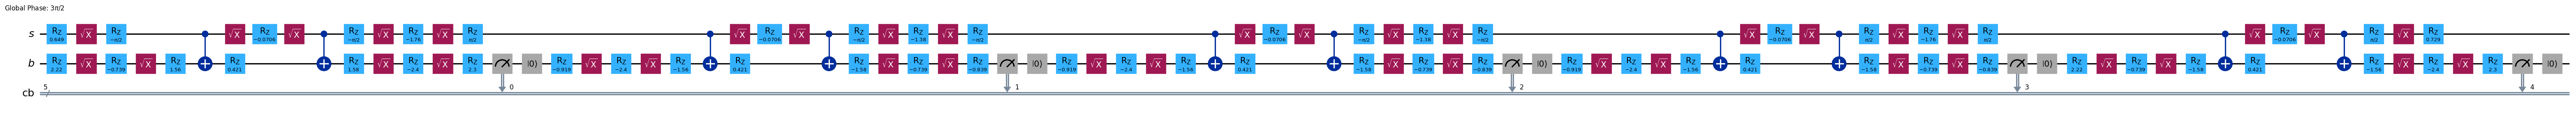

In [8]:
# ============================================================
# B.2 — optimization level 0 vs 3
# ============================================================

qk_params_transpile = dict(qk_params_good, n_cycles=5)
_, compiled_transpile = make_compiled_single_spin(qk_params_transpile)

qc5 = build_protocol_circuit(
    compiled_transpile,
    n_cycles=qk_params_transpile["n_cycles"],
    measure_bath=True,
    bath_measure_basis="Z",
)

backend = AerSimulator()
qc_l0 = transpile(
    qc5,
    backend=backend,
    basis_gates=NATIVE_BASIS,
    optimization_level=0,
)
qc_l3 = transpile(
    qc5,
    backend=backend,
    basis_gates=NATIVE_BASIS,
    optimization_level=3,
)

stats_transpile = pd.DataFrame([
    {
        "optimization_level": 0,
        "depth": qc_l0.depth(),
        "size": qc_l0.size(),
        "width": qc_l0.width(),
        **{k: dict(qc_l0.count_ops()).get(k, 0) for k in ["cx", "rz", "sx", "x", "measure", "reset"]},
    },
    {
        "optimization_level": 3,
        "depth": qc_l3.depth(),
        "size": qc_l3.size(),
        "width": qc_l3.width(),
        **{k: dict(qc_l3.count_ops()).get(k, 0) for k in ["cx", "rz", "sx", "x", "measure", "reset"]},
    },
])

display(stats_transpile)

print("Circuito nativo a optimization_level=3")
display(qc_l3.draw("mpl", fold=-1))

### B.3 Validación fuerte: exacto vs Qiskit `density_matrix`

Esta es la comprobación central de la capa ideal.

Comparamos:
- la evolución exacta del canal,
- la evolución del circuito ejecutado en Aer con `density_matrix`.

Si ambas trayectorias coinciden dentro de errores numéricos, entonces podemos decir que
**la implementación lógica del protocolo es fiel** antes de introducir shots o ruido.

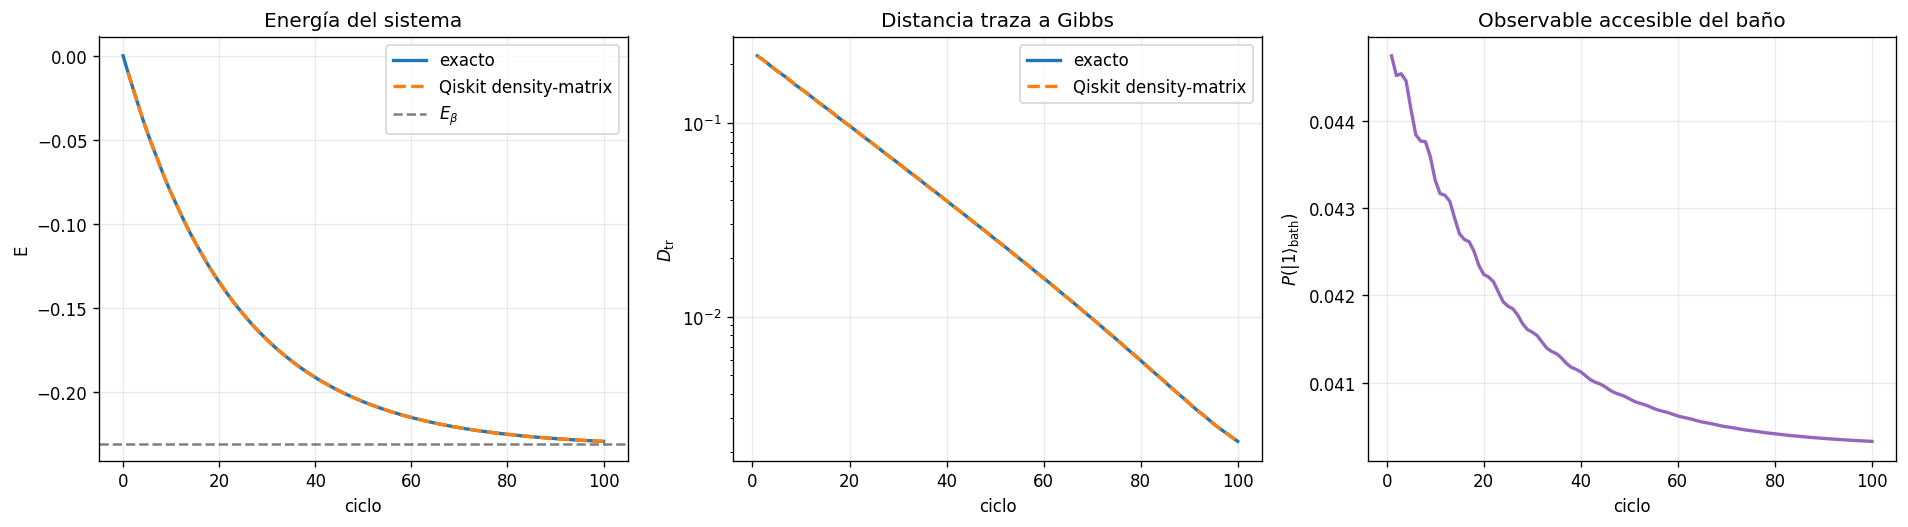

,E_final_exact,E_final_qiskit_dm,|ΔE_final|,D_final_exact,D_final_qiskit_dm,|ΔD_final|,"D_tr(final exact, final DM)","F(final exact, final DM)",max |ΔE(ciclo)|,max |ΔD(ciclo)|
0,-0.229611,-0.229611,0.0,0.002272,0.002272,0.0,0.0,1.0,0.0,0.0


In [37]:
# ============================================================
# B.3 — validación exacto vs Qiskit density-matrix
# ============================================================

rho0_qk = maximally_mixed(1)
cfg_qk, compiled_qk, out_exact_qk, res_dm_qk, d_exact_qk = exact_and_dm_single_spin(qk_params_good, rho0_qk)

cycles_exact = np.arange(len(out_exact_qk["res"]["energies"]))
cycles_dm = np.arange(1, len(res_dm_qk["energies"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(cycles_exact, out_exact_qk["res"]["energies"], lw=2, label="exacto")
axes[0].plot(cycles_dm, res_dm_qk["energies"], "--", lw=2, label="Qiskit density-matrix")
axes[0].axhline(res_dm_qk["E_gibbs"], ls="--", color="k", alpha=0.5, label=r"$E_\beta$")
axes[0].set_title("Energía del sistema")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel("E")
axes[0].legend()

axes[1].plot(cycles_exact[1:], d_exact_qk, lw=2, label="exacto")
axes[1].plot(cycles_dm, res_dm_qk["trace_dists"], "--", lw=2, label="Qiskit density-matrix")
axes[1].set_title("Distancia traza a Gibbs")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}$")
axes[1].set_yscale("log")
axes[1].legend()

axes[2].plot(cycles_dm, res_dm_qk["bath_p1"], lw=2, color="tab:purple")
axes[2].set_title("Observable accesible del baño")
axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$P(|1\rangle_{\rm bath})$")

plt.tight_layout()
plt.show()

rho_final_exact = out_exact_qk["res"]["rhos"][-1]
rho_final_dm = res_dm_qk["rho_final"]

df_ideal_validation = pd.DataFrame([{
    "E_final_exact": out_exact_qk["res"]["energies"][-1],
    "E_final_qiskit_dm": res_dm_qk["energies"][-1],
    "|ΔE_final|": abs(out_exact_qk["res"]["energies"][-1] - res_dm_qk["energies"][-1]),
    "D_final_exact": d_exact_qk[-1],
    "D_final_qiskit_dm": res_dm_qk["trace_dists"][-1],
    "|ΔD_final|": abs(d_exact_qk[-1] - res_dm_qk["trace_dists"][-1]),
    "D_tr(final exact, final DM)": trace_distance_dm(rho_final_exact, rho_final_dm),
    "F(final exact, final DM)": fidelity_dm(rho_final_exact, rho_final_dm),
    "max |ΔE(ciclo)|": np.max(np.abs(out_exact_qk["res"]["energies"][1:] - res_dm_qk["energies"])),
    "max |ΔD(ciclo)|": np.max(np.abs(d_exact_qk - res_dm_qk["trace_dists"])),
}])

display(df_ideal_validation.round(10))

### B.4 Coste nativo del circuito: profundidad, CX y trotterización

Esta sección separa dos efectos distintos:

1. el coste de implementar un ciclo, que escala aproximadamente con $2M_T+1$;
2. el error de trotterización, que depende de cómo discretizamos una ventana física $T=M_T\delta$.

Primero medimos cómo escalan las puertas nativas con $M_T$ y con el número de ciclos. Después comparamos dos discretizaciones con el mismo $T$ para comprobar si cambiar $(M_T,\delta)$ modifica la física o solo el coste del circuito.

#### B.4.1 Recursos nativos del circuito

c:\Users\paula\miniconda3\envs\qiskit_env\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


,MT,depth,size,width,cx,measure,reset,rz,sx,x
0,5,17,24,3,2,1,1,12,8,0
1,10,17,24,3,2,1,1,12,8,0
2,15,17,24,3,2,1,1,12,8,0
3,20,17,24,3,2,1,1,12,8,0
4,30,17,24,3,2,1,1,12,8,0


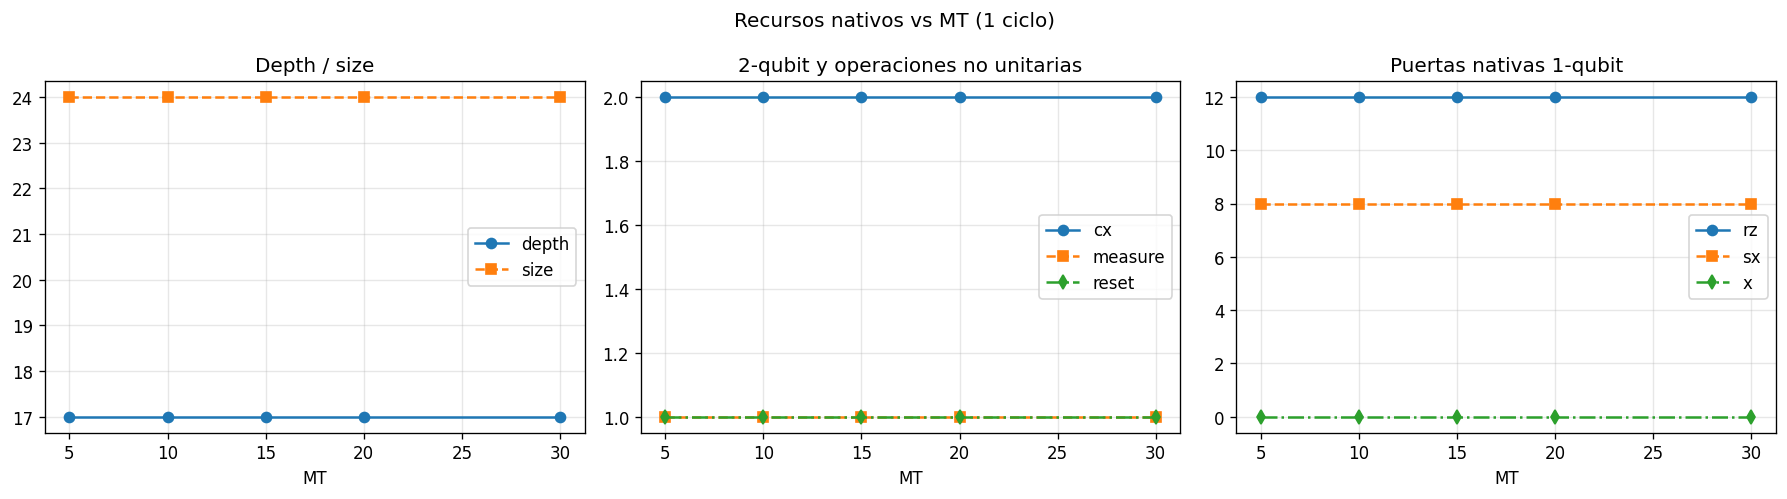

c:\Users\paula\miniconda3\envs\qiskit_env\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


,n_cycles,depth,size,width,cx,measure,reset,rz,sx,x
0,1,17,24,3,2,1,1,12,8,0
1,2,34,48,4,4,2,2,24,16,0
2,4,68,96,6,8,4,4,48,32,0
3,8,136,192,10,16,8,8,96,64,0
4,12,204,288,14,24,12,12,144,96,0


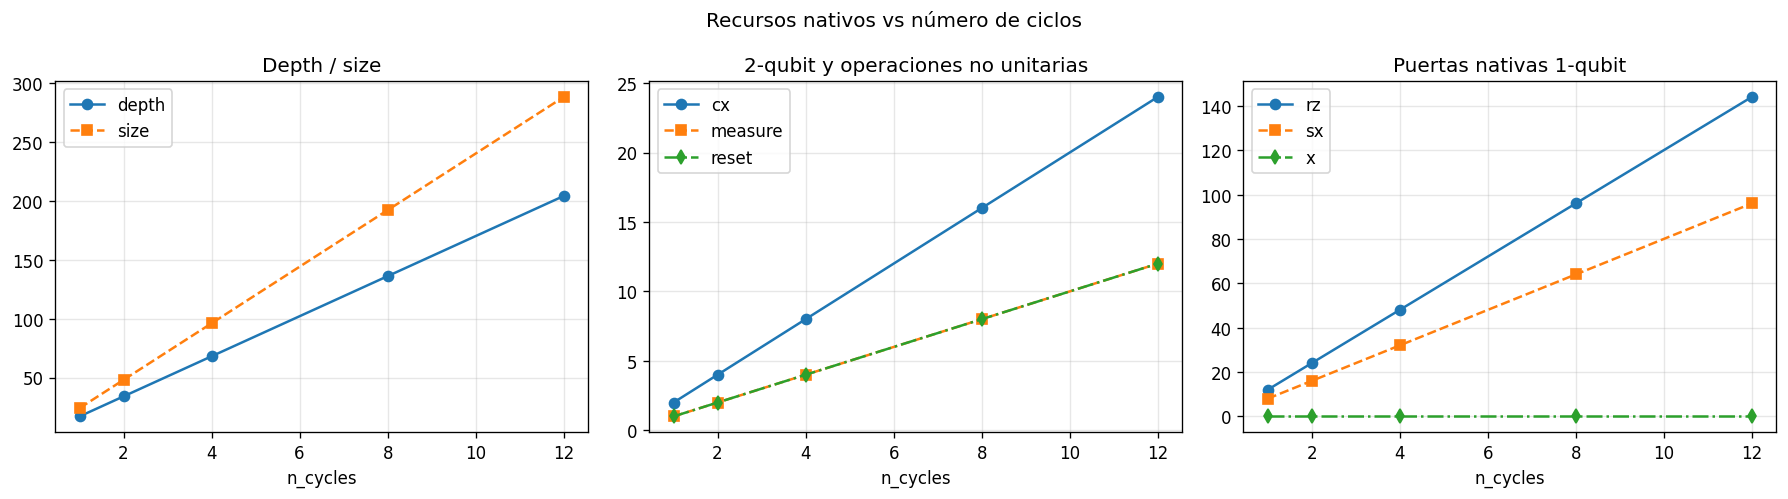

In [38]:
# ============================================================
# B.4 — recursos nativos vs MT y vs número de ciclos
# ============================================================

df_res_mt = resource_scan_single_spin(
    qk_params_good,
    "MT",
    [5, 10, 15, 20, 30],
    n_cycles_for_circuit=1,
    optimization_level=0,
)
display(df_res_mt.round(6))
plot_resource_scan(df_res_mt, "MT", title="Recursos nativos vs MT (1 ciclo)")

df_res_ncyc = resource_scan_single_spin(
    qk_params_good,
    "n_cycles",
    [1, 2, 4, 8, 12],
    n_cycles_for_circuit=None,
    optimization_level=0,
)
display(df_res_ncyc.round(6))
plot_resource_scan(df_res_ncyc, "n_cycles", title="Recursos nativos vs número de ciclos")

La profundidad escala linealmente con $M_T$ ($2M_T+1$ capas por ciclo). El paso $\delta$ no cambia el número total de capas pero sí cuántas son "activas" ($|f_\tau| > $ tol), de modo que afecta linealmente al recuento de CX. Activar `rewind=True` añade $M_R \sim M_T$ capas extra de $U_S$. Cambiar $A_S$ entre $\{X,Y,Z\}$ es un cambio de base de un qubit y resulta prácticamente gratis.

#### B.4.2 Misma ventana física $T=M_T\delta$, distinta trotterización

En el límite Trotter ($\delta \to 0$, $M_T \to \infty$ con $T$ fijo), dos circuitos con distintas $(M_T, \delta)$ pero mismo $T$ deben dar el mismo resultado físico; cualquier discrepancia es error de Trotter. Esto separa el error físico de discretización del coste del circuito: $\delta$ pequeño da más precisión, $M_T$ grande encarece la implementación. La comparación cuantifica el trade-off real entre ambos.

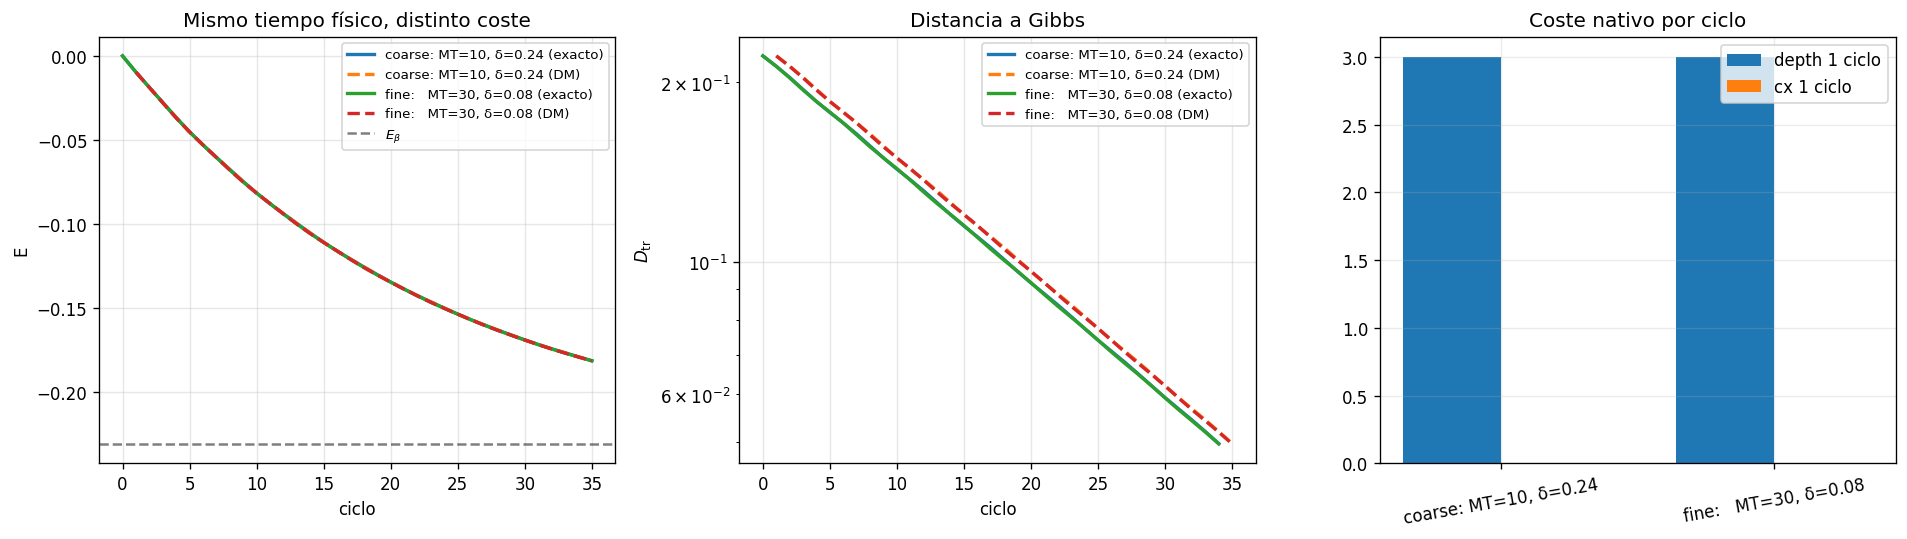

,case,T = MT*delta,depth_1cycle,cx_1cycle,size_1cycle,D_final_exact,D_final_DM,E_bias_final
0,"coarse: MT=10, δ=0.24",2.4,3,0,3,0.049639,0.049639,0.049559
1,"fine: MT=30, δ=0.08",2.4,3,0,3,0.049573,0.049573,0.049483


In [39]:
# ============================================================
# B.5 — mismo T = MT*delta, distinto coste de circuito
# ============================================================

fixedT_cases = {
    "coarse: MT=10, δ=0.24": dict(qk_params_good, MT=10, delta=0.24, n_cycles=35),
    "fine:   MT=30, δ=0.08": dict(qk_params_good, MT=30, delta=0.08, n_cycles=35),
}

rows_fixedT = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for label, pars in fixedT_cases.items():
    _, compiled_case, out_exact_case, out_dm_case, d_exact_case = exact_and_dm_single_spin(pars, maximally_mixed(1))

    axes[0].plot(out_exact_case["res"]["energies"], lw=2, label=f"{label} (exacto)")
    axes[0].plot(np.arange(1, len(out_dm_case["energies"]) + 1), out_dm_case["energies"], "--", lw=2, label=f"{label} (DM)")

    axes[1].plot(d_exact_case, lw=2, label=f"{label} (exacto)")
    axes[1].plot(np.arange(1, len(out_dm_case["trace_dists"]) + 1), out_dm_case["trace_dists"], "--", lw=2, label=f"{label} (DM)")

    st = transpiled_circuit_stats(compiled_case, n_cycles=1, measure_bath=True)

    rows_fixedT.append({
        "case": label,
        "T = MT*delta": pars["MT"] * pars["delta"],
        "depth_1cycle": st["depth"],
        "cx_1cycle": st["cx"],
        "size_1cycle": st["size"],
        "D_final_exact": d_exact_case[-1],
        "D_final_DM": out_dm_case["trace_dists"][-1],
        "E_bias_final": abs(out_dm_case["energies"][-1] - out_dm_case["E_gibbs"]),
    })

axes[0].axhline(res_dm_qk["E_gibbs"], ls="--", color="k", alpha=0.5, label=r"$E_\beta$")
axes[0].set_title("Mismo tiempo físico, distinto coste")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel("E")

axes[1].set_title("Distancia a Gibbs")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}$")
axes[1].set_yscale("log")

df_fixedT = pd.DataFrame(rows_fixedT)
x = np.arange(len(df_fixedT))
axes[2].bar(x - 0.18, df_fixedT["depth_1cycle"], width=0.36, label="depth 1 ciclo")
axes[2].bar(x + 0.18, df_fixedT["cx_1cycle"], width=0.36, label="cx 1 ciclo")
axes[2].set_xticks(x)
axes[2].set_xticklabels(df_fixedT["case"], rotation=10)
axes[2].set_title("Coste nativo por ciclo")
axes[2].legend()

for ax in axes[:2]:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(df_fixedT.round(8))

Esta comparación mantiene fija la ventana física $T=M_T\delta$ y cambia solo la discretización temporal. Las trayectorias de energía y distancia a Gibbs coinciden prácticamente para la discretización gruesa y fina, lo que indica que en este caso el error de trotterización es pequeño frente al sesgo físico del protocolo. 

### B.5 Conclusiones de la capa Qiskit ideal

- La simulación `density_matrix` y el circuito transpilado reproducen el exacto NumPy a precisión numérica (B.3), validando la implementación lógica del ciclo.
- Un ciclo de single spin son $\mathcal{O}(10$–$10^2)$ CX en puertas nativas, con escalado lineal en $M_T$ (B.4).
- A mismo $T$, distintos $(M_T, \delta)$ dan resultados equivalentes en este rango de $\delta$: el error de Trotter no es el factor limitante (B.4.2).
- El rewind del Paper 2 añade aproximadamente otro tanto de profundidad por ciclo.

Al escalar a Ising y Fermi–Hubbard, el factor dominante deja de ser $M_T$ y pasa a ser el tamaño del sistema y el routing impuesto por la conectividad del chip.

## C. Shots con circuitos dinámicos en backend ISA (`FakeSherbrooke`)

A partir de aquí el circuito ya no se transpila contra un simulador genérico, sino contra el `Target` de un backend concreto: layout físico, puertas nativas y conectividad de `FakeSherbrooke` (snapshot offline de `ibm_sherbrooke`, 127 qubits). El resultado es un circuito ISA ejecutable en ese dispositivo. La ejecución sigue siendo en Aer y todavía sin ruido, pero los shots son finitos y el circuito es dinámico — medida del baño mid-circuit, reset y continuación.

Esta capa fija la metodología. En single spin cuantifica el coste de descomponer el `UnitaryGate` del ciclo a puertas nativas; en sistemas mayores la misma infraestructura captura el overhead de routing por la conectividad limitada del chip.

Los observables shot-based son la excitación del baño antes del reset, $P(|1\rangle_B)$, y la energía del sistema reconstruida con medida final en base $Z$.

In [7]:
# ============================================================
# C.0 — imports y selección de backend para circuitos ISA
# ============================================================
#
# Estrategia de selección del backend, en orden de preferencia:
#   1. Si USE_REAL_BACKEND y hay credenciales IBM Runtime:
#        - si BACKEND_NAME está puesto, usa ese backend real
#        - si BACKEND_NAME es None, usa least_busy (auto-selección)
#   2. Si no, usa FakeSherbrooke como snapshot de calibraciones reales
#      (reproducible, offline, sí expone Target y calibraciones IBM).
#   3. Si ni siquiera está qiskit_ibm_runtime, fallback a GenericBackendV2
#      (no realista; solo para no romper el notebook).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# --- Config ---
USE_REAL_BACKEND = False      # True si quieres hardware en vivo (requiere token)
BACKEND_NAME = None           # None = least_busy; o str como "ibm_brisbane"
OPT_LEVEL_ISA = 1

# --- Detectar runtime y fake provider ---
try:
    from qiskit_ibm_runtime import QiskitRuntimeService
    from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
    HAVE_RUNTIME = True
except Exception as _e:
    HAVE_RUNTIME = False
    print("qiskit_ibm_runtime no está disponible:", _e)

def _backend_label(b):
    for attr in ["name", "backend_name"]:
        if hasattr(b, attr):
            v = getattr(b, attr)
            return v() if callable(v) else v
    return b.__class__.__name__

hw_backend = None
HW_BACKEND_LABEL = None

# --- Ruta 1: hardware real IBM ---
if USE_REAL_BACKEND and HAVE_RUNTIME:
    try:
        service = QiskitRuntimeService()
        if BACKEND_NAME is None:
            hw_backend = service.least_busy(
                simulator=False,
                operational=True,
                dynamic_circuits=True,
            )
        else:
            hw_backend = service.backend(BACKEND_NAME)
        HW_BACKEND_LABEL = f"real IBM: {_backend_label(hw_backend)}"
    except Exception as e:
        print("No pude acceder a hardware IBM real. Paso a FakeSherbrooke.")
        print("  Detalle:", repr(e))
        hw_backend = None

# --- Ruta 2: FakeSherbrooke (snapshot de calibraciones reales) ---
if hw_backend is None and HAVE_RUNTIME:
    hw_backend = FakeSherbrooke()
    HW_BACKEND_LABEL = f"FakeSherbrooke (snapshot calibraciones reales)"

# --- Ruta 3: GenericBackendV2 (último recurso, no realista) ---
if hw_backend is None:
    from qiskit.providers.fake_provider import GenericBackendV2
    hw_backend = GenericBackendV2(
        num_qubits=2,
        basis_gates=["rz", "sx", "x", "cx", "measure", "reset"],
        coupling_map=[[0, 1], [1, 0]],
        control_flow=True,
        seed=1234,
    )
    HW_BACKEND_LABEL = "GenericBackendV2 (sintético, sin calibraciones)"

# --- Simuladores Aer ---
ideal_sim = AerSimulator(seed_simulator=1234)

# Modelo de ruido: solo si el backend tiene calibraciones reales
# (FakeSherbrooke sí; GenericBackendV2 no tiene ruido físico asociado)
try:
    noise_model_backend = NoiseModel.from_backend(hw_backend)
    noisy_sim = AerSimulator(noise_model=noise_model_backend, seed_simulator=4321)
    HAVE_NOISE_MODEL = True
except Exception as e:
    noise_model_backend = None
    noisy_sim = None
    HAVE_NOISE_MODEL = False
    print("No se pudo derivar NoiseModel del backend:", repr(e))

print("Backend ISA seleccionado:", HW_BACKEND_LABEL)
print("Optimization level ISA :", OPT_LEVEL_ISA)
print("Modelo de ruido disponible:", HAVE_NOISE_MODEL)

Backend ISA seleccionado: FakeSherbrooke (snapshot calibraciones reales)
Optimization level ISA : 1
Modelo de ruido disponible: True


### C.0.b Qué contiene el snapshot del backend

`FakeSherbrooke` es un snapshot offline de las calibraciones de `ibm_sherbrooke`. Cada chip de IBM se recalibra cada pocas horas, y el snapshot embebe lo que mide el laboratorio: error rate por puerta 1q y 2q en cada qubit, $T_1$, $T_2$ y frecuencia, error de readout, mapa de acoplo y duraciones de puerta en nanosegundos. Estos números son los que `NoiseModel.from_backend(hw_backend)` traduce a un modelo de ruido concreto cuando lleguemos a la capa D.

In [8]:
# ============================================================
# C.0.b — Inspección del snapshot del backend
# ============================================================

target = hw_backend.target

print(f"Backend         : {HW_BACKEND_LABEL}")
print(f"Num. qubits     : {hw_backend.num_qubits}")
print(f"Puertas nativas : {sorted(target.operation_names)}")
print(f"Dynamic circuits: {getattr(target, 'supports_control_flow', 'n/a')}")

# --- Propiedades físicas de qubit (T1, T2, frecuencia) ---
print("\n--- T1, T2, frecuencia (primeros 5 qubits) ---")
try:
    qps = target.qubit_properties
    for q in range(min(5, hw_backend.num_qubits)):
        qp = qps[q]
        t1_us = (qp.t1 * 1e6) if qp.t1 is not None else float("nan")
        t2_us = (qp.t2 * 1e6) if qp.t2 is not None else float("nan")
        f_ghz = (qp.frequency * 1e-9) if qp.frequency is not None else float("nan")
        print(f"  q{q:>2}: T1={t1_us:6.1f} us   T2={t2_us:6.1f} us   f={f_ghz:6.3f} GHz")
except Exception as e:
    print("  (sin qubit_properties:", e, ")")

# --- Errores de puerta 1q (sx si existe) ---
print("\n--- Error de puertas 1q (sx, primeros 5 qubits) ---")
if "sx" in target.operation_names:
    for q in range(min(5, hw_backend.num_qubits)):
        props = target["sx"].get((q,))
        err = props.error if (props is not None and props.error is not None) else float("nan")
        dur = (props.duration * 1e9) if (props is not None and props.duration is not None) else float("nan")
        print(f"  sx  q{q:>2}: error={err:.3e}   duration={dur:6.1f} ns")
else:
    print("  (el backend no tiene 'sx' como puerta nativa)")

# --- Errores de puerta 2q (ecr o cx) ---
two_q = "ecr" if "ecr" in target.operation_names else ("cx" if "cx" in target.operation_names else None)
print(f"\n--- Error de puertas 2q ({two_q}, primeros 5 pares) ---")
if two_q is not None:
    for qtuple, props in list(target[two_q].items())[:5]:
        err = props.error if (props is not None and props.error is not None) else float("nan")
        dur = (props.duration * 1e9) if (props is not None and props.duration is not None) else float("nan")
        print(f"  {two_q} {qtuple}: error={err:.3e}   duration={dur:6.1f} ns")
else:
    print("  (no hay puerta 2q estándar en este target)")

# --- Error de lectura ---
print("\n--- Error de lectura (primeros 5 qubits) ---")
if "measure" in target.operation_names:
    for q in range(min(5, hw_backend.num_qubits)):
        props = target["measure"].get((q,))
        err = props.error if (props is not None and props.error is not None) else float("nan")
        print(f"  measure q{q:>2}: error={err:.3e}")
else:
    print("  (el backend no expone 'measure' en el target)")

print(f"\nModelo de ruido disponible para Aer: {HAVE_NOISE_MODEL}")

Backend         : FakeSherbrooke (snapshot calibraciones reales)
Num. qubits     : 127
Puertas nativas : ['delay', 'ecr', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Dynamic circuits: n/a

--- T1, T2, frecuencia (primeros 5 qubits) ---
  q 0: T1= 381.6 us   T2= 131.7 us   f= 4.636 GHz
  q 1: T1= 233.8 us   T2= 251.0 us   f= 4.736 GHz
  q 2: T1= 270.4 us   T2= 230.3 us   f= 4.819 GHz
  q 3: T1= 328.8 us   T2= 333.4 us   f= 4.747 GHz
  q 4: T1= 291.7 us   T2= 192.4 us   f= 4.788 GHz

--- Error de puertas 1q (sx, primeros 5 qubits) ---
  sx  q 0: error=2.878e-04   duration=  56.9 ns
  sx  q 1: error=2.015e-04   duration=  56.9 ns
  sx  q 2: error=3.803e-04   duration=  56.9 ns
  sx  q 3: error=5.770e-04   duration=  56.9 ns
  sx  q 4: error=1.802e-04   duration=  56.9 ns

--- Error de puertas 2q (ecr, primeros 5 pares) ---
  ecr (1, 0): error=7.494e-03   duration= 533.3 ns
  ecr (1, 2): error=8.788e-03   duration= 533.3 ns
  ecr (3, 2): error=8.695e-03

### C.1 Utilidades para circuitos dinámicos shot-based

Definimos el constructor del circuito dinámico del protocolo, la mezcla clásica que implementa $\rho_0 = I/2$ promediando $|0\rangle$ y $|1\rangle$ sobre shots, el parser de counts y los wrappers que ejecutan el protocolo en modo shot-puro contra el backend ISA seleccionado.

### C.2 Backend ISA y circuito dinámico

Verificamos primero qué backend estamos usando como `Target` y cómo queda un circuito dinámico del protocolo tras transpilarlo. Esto concreta, antes de correr nada, qué puertas nativas y qué profundidad ISA tiene el protocolo en este backend. Aunque sigamos simulando en Aer, la compilación ya es físicamente realista.

Parámetros C:
  g: 1.0
  h: 1.0
  beta: 1.0
  theta: 0.25
  delta: 0.08
  MT: 15
  n_cycles: 8
  sys_A: ZYmix
  bath_A: Y
  randomize: False
  randomization_lambda: 0.0
  seed: 1234
  rewind: False
Backend: FakeSherbrooke (snapshot calibraciones reales)
Número de qubits del backend: 127
Operaciones soportadas por el target (primeras 20): ['delay', 'ecr', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Circuito lógico dinámico


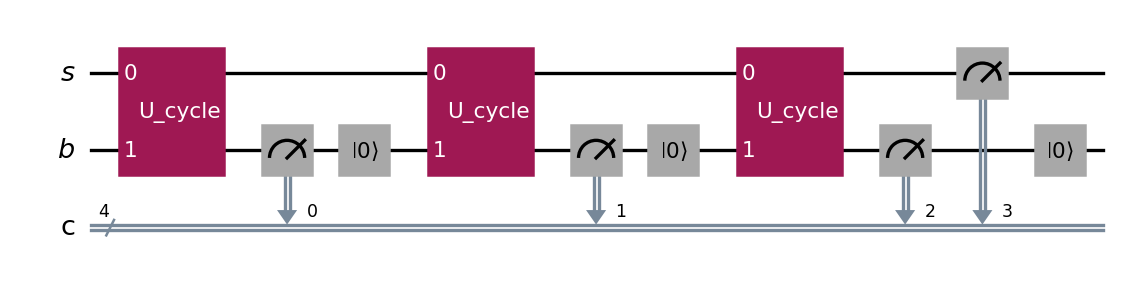

Circuito ISA transpileado al backend


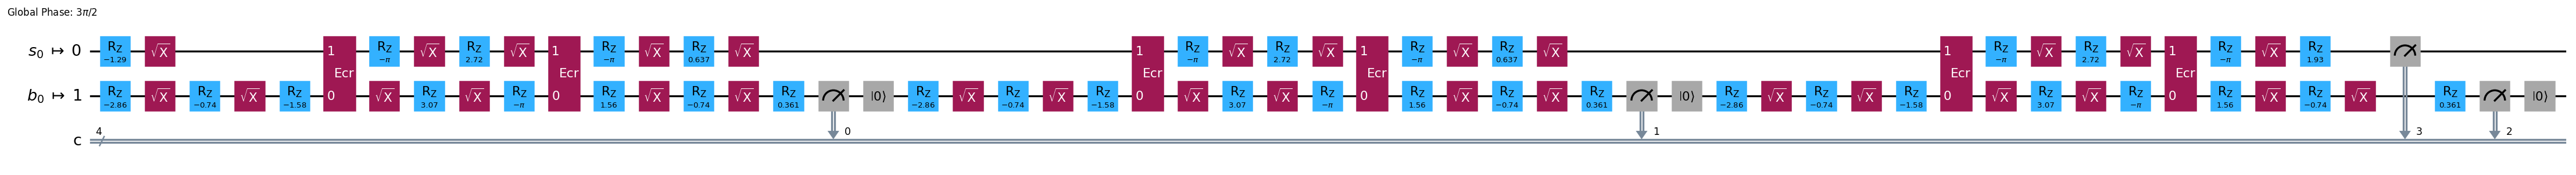

Ops ISA: {'rz': 37, 'sx': 30, 'ecr': 6, 'measure': 4, 'reset': 3}
Depth ISA: 54


In [11]:
# ============================================================
# C.2 — resumen del backend y circuito dinámico transpileado
# ============================================================

c_params_hw = dict(
    qk_params_good,
    theta=0.25,
    MT=15,
    n_cycles=8,
    randomize=False,
    rewind=False,
)


print("Parámetros C:")
for k, v in c_params_hw.items():
    print(f"  {k}: {v}")

_, compiled_C = make_compiled_single_spin(c_params_hw)

print("Backend:", HW_BACKEND_LABEL)
print("Número de qubits del backend:", getattr(hw_backend, "num_qubits", "desconocido"))

target = hw_backend.target
op_names = sorted(list(target.operation_names)) if hasattr(target, "operation_names") else []
print("Operaciones soportadas por el target (primeras 20):", op_names[:20])

qc_dyn = build_dynamic_protocol_circuit(
    compiled_C,
    n_cycles=3,
    init_label="0",
    final_basis="Z",
)

qc_dyn_isa = get_isa_dynamic_circuit(
    compiled_C,
    n_cycles=3,
    init_label="0",
    final_basis="Z",
)

print("Circuito lógico dinámico")
display(qc_dyn.draw("mpl"))

print("Circuito ISA transpileado al backend")
display(qc_dyn_isa.draw("mpl", fold=-1))

print("Ops ISA:", dict(qc_dyn_isa.count_ops()))
print("Depth ISA:", qc_dyn_isa.depth())

### C.3 Excitación del baño antes del reset

El observable más directo del protocolo es la probabilidad de encontrar el baño excitado justo antes del reset, $P(|1\rangle_B)$. La medimos con circuitos dinámicos compilados al backend ISA, todavía sin ruido y barriendo el presupuesto de shots.

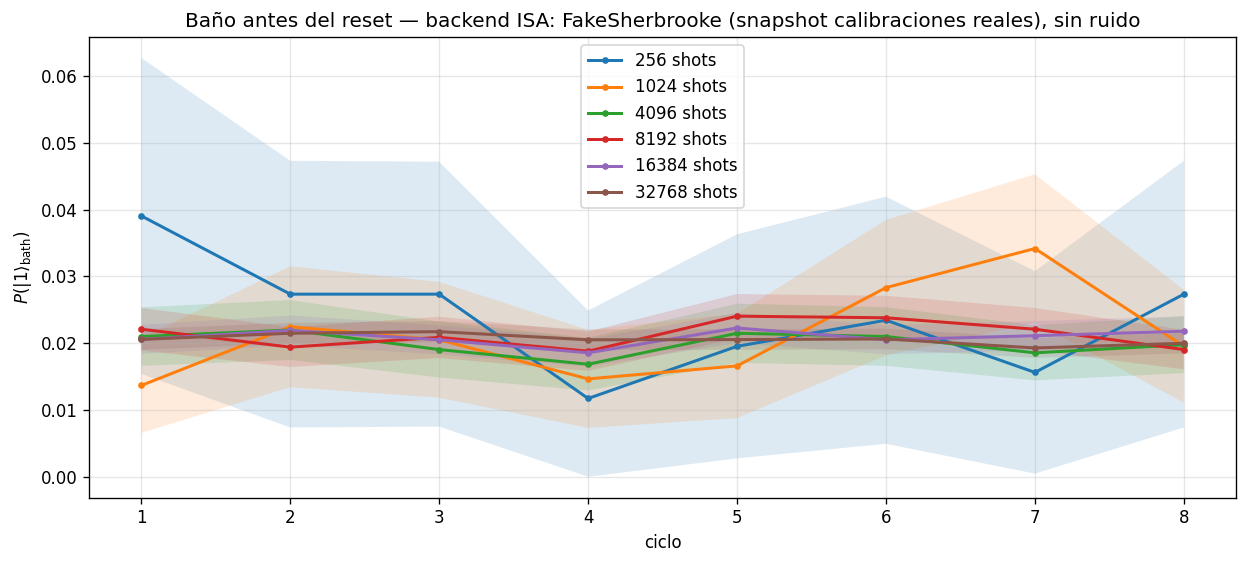

,cycle,p1_bath_256,p1_bath_1024,p1_bath_4096,p1_bath_8192,p1_bath_16384,p1_bath_32768,sigma_bath_256,sigma_bath_1024,sigma_bath_4096,sigma_bath_8192,sigma_bath_16384,sigma_bath_32768
0,1,0.039062,0.013672,0.020996,0.022095,0.020569,0.020569,0.012070,0.003627,0.002234,0.001620,0.001107,0.000783
1,2,0.027344,0.022461,0.021973,0.019409,0.021912,0.021484,0.010190,0.004618,0.002286,0.001522,0.001141,0.000799
2,3,0.027344,0.020508,0.019043,0.020874,0.020508,0.021729,0.010119,0.004424,0.002131,0.001577,0.001105,0.000804
3,4,0.011719,0.014648,0.016846,0.018799,0.018555,0.020508,0.006722,0.003744,0.002008,0.001498,0.001052,0.000782
4,5,0.019531,0.016602,0.021484,0.024048,0.022278,0.020538,0.008562,0.003990,0.002262,0.001690,0.001151,0.000782
5,6,0.023438,0.028320,0.020996,0.023804,0.020508,0.020630,0.009443,0.005173,0.002238,0.001682,0.001105,0.000784
6,7,0.015625,0.034180,0.018555,0.022095,0.021118,0.019287,0.007736,0.005671,0.002104,0.001622,0.001122,0.000759
7,8,0.027344,0.019531,0.019775,0.019043,0.021790,0.019989,0.010190,0.004309,0.002173,0.001508,0.001139,0.000772


In [13]:
# ============================================================
# C.3 — baño antes del reset, shot-based e ideal
# ============================================================

# shots_list_C = [256, 1024, 4096]
shots_list_C = [256, 1024, 4096, 8192, 16384, 32768]
cycles_C = np.arange(1, c_params_hw["n_cycles"] + 1) 

#n_cycles_C = 50

bath_runs_C = {}
for shots in shots_list_C:
    bath_runs_C[shots] = run_isa_dynamic_shots(
        compiled_C,
        n_cycles=c_params_hw["n_cycles"],
        #n_cycles=n_cycles_C, # son muchos ciclos para mostrar el efecto de la acumulación de ruido en el baño
        shots=shots,
        init_mode="mm",
        final_basis="Z",
        sim_mode="ideal",
        seed_base=100 + shots,
    )

fig, ax = plt.subplots(1, 1, figsize=(10.5, 4.8))

for shots in shots_list_C:
    res = bath_runs_C[shots]
    ax.plot(cycles_C, res["bath_p1"], marker="o", ms=3, lw=1.8, label=f"{shots} shots")
    ax.fill_between(cycles_C, res["bath_lo95"], res["bath_hi95"], alpha=0.15)

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$P(|1\rangle_{\rm bath})$")
ax.set_title(f"Baño antes del reset — backend ISA: {HW_BACKEND_LABEL}, sin ruido")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

df_bath_C = pd.DataFrame({
    "cycle": cycles_C,
    **{f"p1_bath_{shots}": bath_runs_C[shots]["bath_p1"] for shots in shots_list_C},
    **{f"sigma_bath_{shots}": bath_runs_C[shots]["bath_sigma"] for shots in shots_list_C},
})
display(df_bath_C.round(6))

### C.4 Energía del sistema estimada por shots

Además de la lectura del baño, el observable físico más útil es la energía del sistema.

Para cada número de ciclos, truncamos el circuito dinámico, medimos el sistema al final y reconstruimos la energía de forma completamente shot-based.

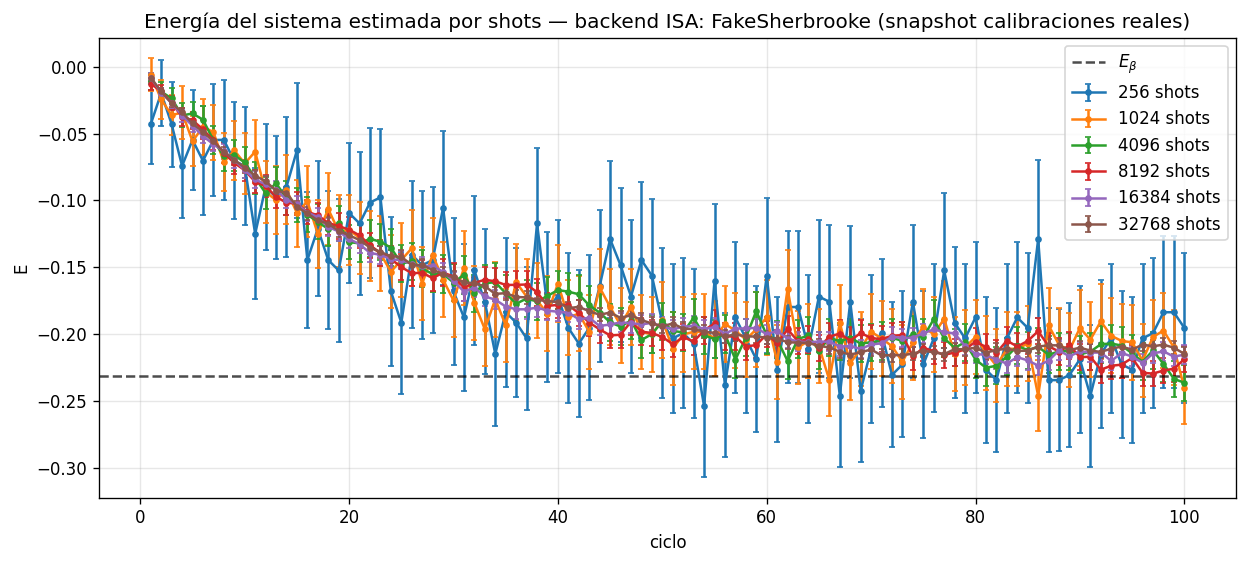

,cycle,E_final,E_sigma,z_final,z_sigma
0,1,-0.010742,0.003232,0.021484,0.006464
1,2,-0.018555,0.003511,0.037109,0.007021
2,3,-0.023682,0.003919,0.047363,0.007838
3,4,-0.036377,0.004577,0.072754,0.009154
4,5,-0.034912,0.004373,0.069824,0.008747
...,...,...,...,...,...
95,96,-0.220703,0.007010,0.441406,0.014020
96,97,-0.212158,0.007074,0.424316,0.014147
97,98,-0.222168,0.006999,0.444336,0.013998
98,99,-0.233398,0.006909,0.466797,0.013818


In [ ]:
# ============================================================
# C.4 — energía del sistema por shots, sin ruido
# ============================================================

max_cycles_energy_C = 100
energy_runs_C = {}

for shots in shots_list_C:
    energy_runs_C[shots] = run_energy_vs_cycles_shots(
        compiled_C,
        max_cycles=max_cycles_energy_C,
        shots=shots,
        init_mode="mm",
        sim_mode="ideal",
        seed_base=2000 + shots,
    )

rho_g_C = gibbs_state(compiled_C["Hs_mat"], c_params_hw["beta"])
E_gibbs_C = float(np.real(np.trace(rho_g_C @ compiled_C["Hs_mat"])))

fig, ax = plt.subplots(1, 1, figsize=(10.5, 4.8))

for shots in shots_list_C:
    df_ = energy_runs_C[shots]
    ax.errorbar(
        df_["cycle"],
        df_["E_final"],
        yerr=1.96 * df_["E_sigma"],
        fmt="o-",
        ms=3,
        capsize=2,
        lw=1.5,
        label=f"{shots} shots",
    )

ax.axhline(E_gibbs_C, ls="--", color="k", alpha=0.7, label=r"$E_\beta$")
ax.set_xlabel("ciclo")
ax.set_ylabel("E")
ax.set_title(f"Energía del sistema estimada por shots — backend ISA: {HW_BACKEND_LABEL}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(energy_runs_C[4096].round(6))

### C.4.b Relación sistema-baño: visualización del mecanismo de cooling

Hasta aquí hemos tratado la energía del sistema y la señal del baño como observables independientes. Pero están físicamente ligados: en cada ciclo, lo que el sistema pierde de energía se transfiere al baño auxiliar, que luego es reseteado. En acoplo débil, esta transferencia es perturbativa:

$$\Delta E_S(r) \approx -h \cdot P_r(|1\rangle_B)$$

Verificamos esta relación directamente con circuitos dinámicos: medimos simultáneamente la energía del sistema y la excitación del baño antes de cada reset. Esto permite ver en un único gráfico el mecanismo de cooling "en vivo" y cuantificar la relación entre los dos observables por ciclo.

Esta figura usa únicamente ejecución ideal (sin ruido) para aislar la física del protocolo. $\theta=0.30$ y $25$ ciclos se eligen para que el transitorio sea claramente visible.

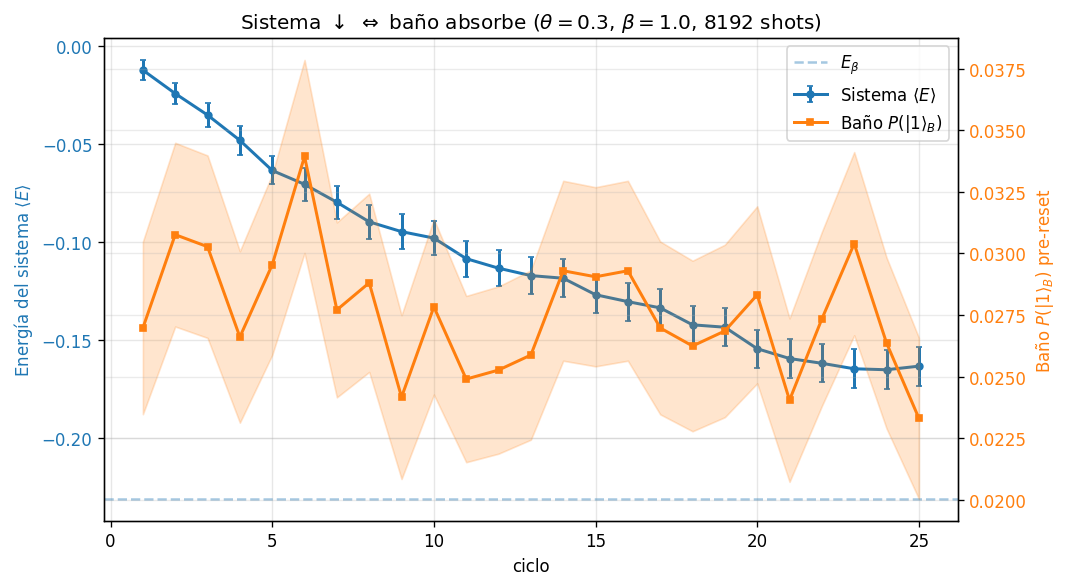


Correlación Pearson entre ΔE_S(r) y P_B(r+1): -0.329
  (si el protocolo funciona, esperamos correlación negativa)


In [19]:
# ============================================================
# C.4.b — Visualización conjunta: sistema baja mientras baño absorbe
# ============================================================
#
# En cada ciclo del protocolo, el sistema pierde energía y el baño la absorbe
# antes del reset. Mostramos ambas trayectorias en ejes separados para ver
# la correlación. Las barras de error son shot-noise (1.96σ) con 8192 shots.

cshow_params = dict(
    c_params_hw,
    theta=0.30,
    n_cycles=25,
)
_, compiled_show = make_compiled_single_spin(cshow_params)
shots_show = 8192

out_show = run_isa_dynamic_shots(
    compiled_show,
    n_cycles=cshow_params["n_cycles"],
    shots=shots_show,
    init_mode="mm", final_basis="Z", sim_mode="ideal",
    seed_base=42,
)
df_E = run_energy_vs_cycles_shots(
    compiled_show,
    max_cycles=cshow_params["n_cycles"], shots=shots_show,
    init_mode="mm", sim_mode="ideal",
    seed_base=43,
)

bath_curve = out_show["bath_p1"]
bath_sig   = out_show["bath_sigma"]
E_curve    = df_E["E_final"].values
E_sig      = df_E["E_sigma"].values

rho_g = gibbs_state(compiled_show["Hs_mat"], cshow_params["beta"])
E_gibbs_show = float(np.real(np.trace(rho_g @ compiled_show["Hs_mat"])))

cycles = np.arange(1, cshow_params["n_cycles"] + 1)

# ---- Figura: un solo panel con doble eje ----
fig, ax_E = plt.subplots(figsize=(9, 5))
ax_B = ax_E.twinx()

ax_E.errorbar(
    cycles, E_curve, yerr=1.96*E_sig,
    fmt="o-", ms=4, capsize=2, lw=1.8, color="tab:blue",
    label=r"Sistema $\langle E \rangle$",
)
ax_E.axhline(E_gibbs_show, ls="--", color="tab:blue", alpha=0.4, label=r"$E_\beta$")
ax_E.set_xlabel("ciclo")
ax_E.set_ylabel(r"Energía del sistema $\langle E\rangle$", color="tab:blue")
ax_E.tick_params(axis="y", labelcolor="tab:blue")

ax_B.plot(
    cycles, bath_curve, "s-", ms=4, lw=1.8, color="tab:orange",
    label=r"Baño $P(|1\rangle_B)$",
)
ax_B.fill_between(
    cycles,
    bath_curve - 1.96*bath_sig, bath_curve + 1.96*bath_sig,
    color="tab:orange", alpha=0.2,
)
ax_B.set_ylabel(r"Baño $P(|1\rangle_B)$ pre-reset", color="tab:orange")
ax_B.tick_params(axis="y", labelcolor="tab:orange")

lines_E, labs_E = ax_E.get_legend_handles_labels()
lines_B, labs_B = ax_B.get_legend_handles_labels()
ax_E.legend(lines_E + lines_B, labs_E + labs_B, loc="upper right")
ax_E.set_title(
    rf"Sistema $\downarrow$ $\Leftrightarrow$ baño absorbe "
    rf"($\theta={cshow_params['theta']}$, $\beta={cshow_params['beta']}$, "
    rf"{shots_show} shots)"
)
ax_E.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico numérico: correlación de los dos canales
dE = np.diff(E_curve)
pearson = np.corrcoef(dE, bath_curve[1:])[0, 1]
print(f"\nCorrelación Pearson entre ΔE_S(r) y P_B(r+1): {pearson:.3f}")
print(f"  (si el protocolo funciona, esperamos correlación negativa)")

La energía del sistema (eje izquierdo, azul) decae monótonamente hacia $E_\beta$ con barras de error de shot-noise, mientras que la excitación del baño antes del reset (eje derecho, naranja) oscila en torno a $P(|1\rangle_B) \approx 0.03$ porque cada ciclo arranca con $|0\rangle_B$ reinicializado. La correlación Pearson negativa entre $\Delta E_S(r)$ y $P_B(r{+}1)$ es la firma microscópica del cooling: los ciclos con mayor excitación del baño coinciden, en promedio, con los de mayor pérdida de energía del sistema. El valor $P_B \approx 0.03$ es coherente con el régimen perturbativo $\theta = 0.30$; en el límite $\theta \to 0$ la curva del baño tendería a cero y desaparecería el cooling.

### C.5 Escalado del error con shots

La sección C se mantiene shot-based pura: usamos una corrida con muchos shots como referencia empírica — sin recurrir a `density_matrix` — y medimos cómo decae el error medio absoluto al reducir el presupuesto. Si el comportamiento es binomial, $\varepsilon \sim 1/\sqrt{N_{\rm shots}}$, queda cuantificado el coste estadístico del protocolo.

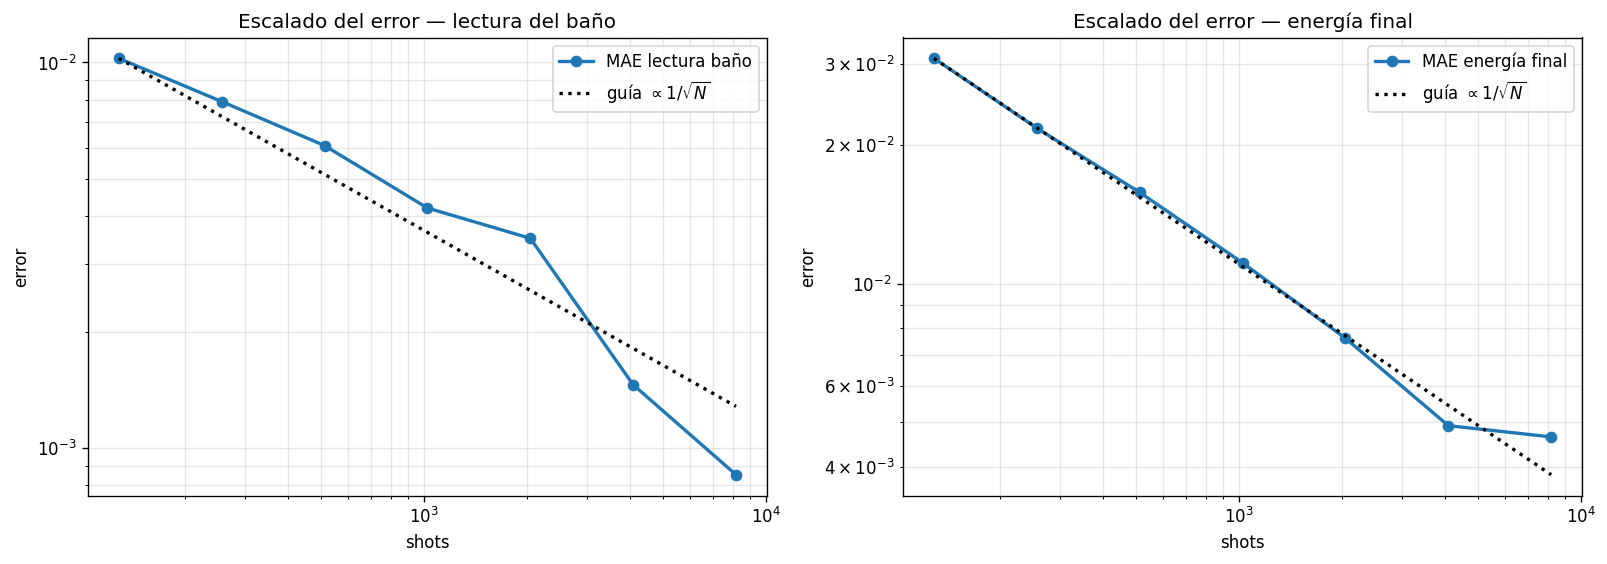

,shots,bath_MAE_mean,bath_MAE_std,energy_MAE_mean,energy_MAE_std
0,128,0.010251,0.003138,0.030791,0.002075
1,256,0.007919,0.001957,0.021731,0.001365
2,512,0.006087,0.000873,0.015765,0.001054
3,1024,0.004192,0.000854,0.011090,0.000616
4,2048,0.003498,0.000469,0.007607,0.000538
5,4096,0.001458,0.000349,0.004919,0.000229
6,8192,0.000852,0.000094,0.004649,0.000122


In [12]:
# ============================================================
# C.5 — escalado del error con shots (binomial 1/sqrt(N))
# ============================================================
max_cycles_energy_C = 100
shots_ref_C = 32768
max_cycles_scale_C = max_cycles_energy_C  # definido en C.4

ref_bath = run_isa_dynamic_shots(
    compiled_C,
    n_cycles=c_params_hw["n_cycles"],
    shots=shots_ref_C,
    init_mode="mm", final_basis="Z", sim_mode="ideal",
    seed_base=777,
)
ref_energy = run_energy_vs_cycles_shots(
    compiled_C,
    max_cycles=max_cycles_scale_C,
    shots=shots_ref_C,
    init_mode="mm", sim_mode="ideal",
    seed_base=888,
)

shots_grid_scale_C = np.array([128, 256, 512, 1024, 2048, 4096, 8192], dtype=int)
n_reps_scale_C = 12

rows_scale_C = []
for shots in shots_grid_scale_C:
    bath_maes, energy_maes = [], []
    for rep in range(n_reps_scale_C):
        res_b = run_isa_dynamic_shots(
            compiled_C,
            n_cycles=c_params_hw["n_cycles"],
            shots=int(shots),
            init_mode="mm", final_basis="Z", sim_mode="ideal",
            seed_base=3000 + 100 * rep + shots,
        )
        df_e = run_energy_vs_cycles_shots(
            compiled_C,
            max_cycles=max_cycles_scale_C,
            shots=int(shots),
            init_mode="mm", sim_mode="ideal",
            seed_base=4000 + 100 * rep + shots,
        )
        bath_maes.append(np.mean(np.abs(res_b["bath_p1"] - ref_bath["bath_p1"])))
        energy_maes.append(np.mean(np.abs(df_e["E_final"].values - ref_energy["E_final"].values)))

    rows_scale_C.append({
        "shots": int(shots),
        "bath_MAE_mean":   float(np.mean(bath_maes)),
        "bath_MAE_std":    float(np.std(bath_maes, ddof=1)),
        "energy_MAE_mean": float(np.mean(energy_maes)),
        "energy_MAE_std":  float(np.std(energy_maes, ddof=1)),
    })

df_scale_C = pd.DataFrame(rows_scale_C)

N0_bath = df_scale_C["shots"].iloc[0]
guide_bath   = df_scale_C["bath_MAE_mean"].iloc[0]   * np.sqrt(N0_bath / df_scale_C["shots"])
guide_energy = df_scale_C["energy_MAE_mean"].iloc[0] * np.sqrt(N0_bath / df_scale_C["shots"])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

axes[0].loglog(df_scale_C["shots"], df_scale_C["bath_MAE_mean"], "o-", lw=2, label="MAE lectura baño")
axes[0].loglog(df_scale_C["shots"], guide_bath, "k:", lw=2, label=r"guía $\propto 1/\sqrt{N}$")
axes[0].set_xlabel("shots"); axes[0].set_ylabel("error")
axes[0].set_title("Escalado del error — lectura del baño")
axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

axes[1].loglog(df_scale_C["shots"], df_scale_C["energy_MAE_mean"], "o-", lw=2, label="MAE energía final")
axes[1].loglog(df_scale_C["shots"], guide_energy, "k:", lw=2, label=r"guía $\propto 1/\sqrt{N}$")
axes[1].set_xlabel("shots"); axes[1].set_ylabel("error")
axes[1].set_title("Escalado del error — energía final")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()
display(df_scale_C.round(8))

## C.6 Ventana experimental shot-based: señal térmica frente a coste estadístico

Esto da una frontera experimental clara entre:
- regímenes donde el protocolo se puede resolver con shots finitos;
- y regímenes donde la señal queda enterrada.

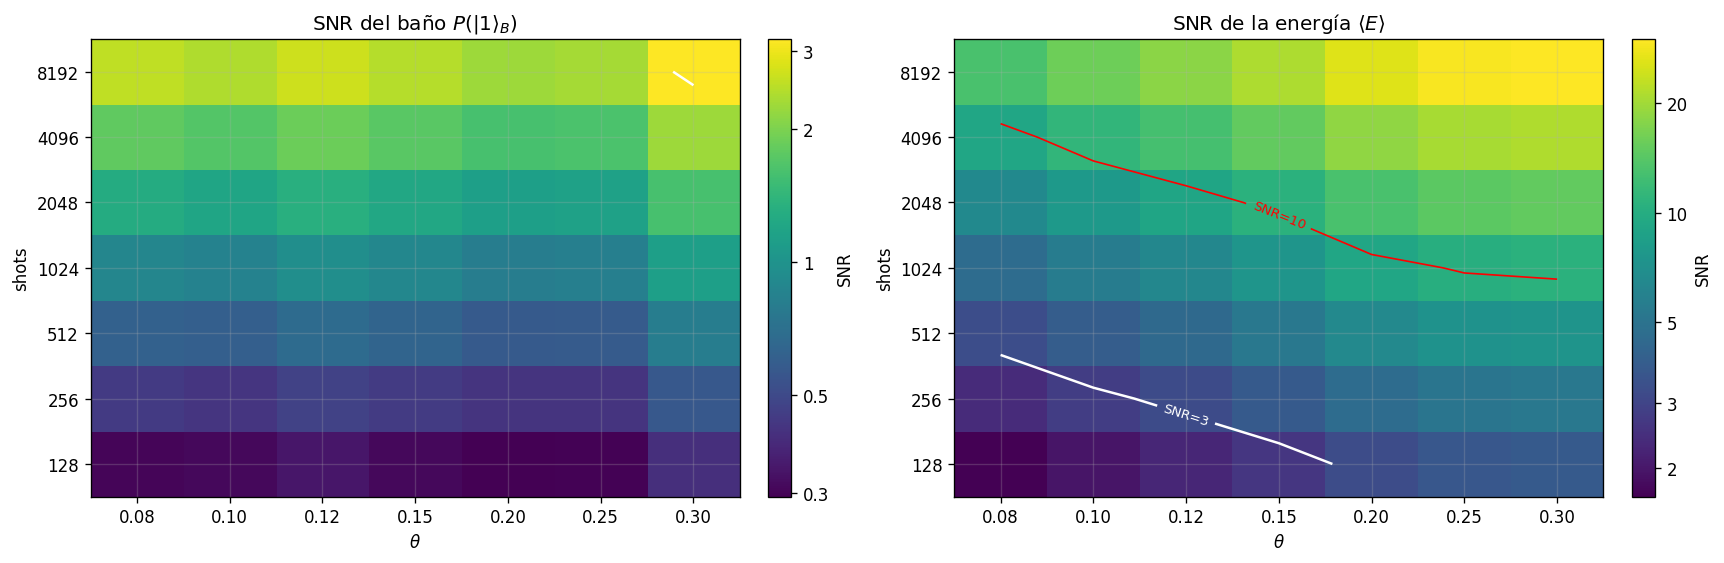


Amplitudes físicas (span entre p10 y p90):
  theta=0.08:  span_bath=0.0013   span_E=0.0294   ratio E/bath=22.1x
  theta=0.10:  span_bath=0.0016   span_E=0.0432   ratio E/bath=27.7x
  theta=0.12:  span_bath=0.0020   span_E=0.0564   ratio E/bath=27.6x
  theta=0.15:  span_bath=0.0023   span_E=0.0768   ratio E/bath=32.8x
  theta=0.20:  span_bath=0.0028   span_E=0.1098   ratio E/bath=39.1x
  theta=0.25:  span_bath=0.0035   span_E=0.1320   ratio E/bath=37.5x
  theta=0.30:  span_bath=0.0057   span_E=0.1417   ratio E/bath=24.8x


,theta,shots,span_bath,span_energy,SNR_bath,SNR_energy
0,0.08,128,0.00133,0.02943,0.30449,1.66661
1,0.08,256,0.00133,0.02943,0.43968,2.37655
2,0.08,512,0.00133,0.02943,0.61837,3.31010
3,0.08,1024,0.00133,0.02943,0.88193,4.64093
4,0.08,2048,0.00133,0.02943,1.27828,6.55758
5,0.08,4096,0.00133,0.02943,1.79263,9.23082
6,0.08,8192,0.00133,0.02943,2.54610,12.98553
7,0.10,128,0.00156,0.04321,0.30885,1.96960
8,0.10,256,0.00156,0.04321,0.42421,2.81498
9,0.10,512,0.00156,0.04321,0.60473,3.92363


In [ ]:
# ============================================================
# C.6 — mapa de detectabilidad: baño vs energía en (theta, shots)
# ============================================================
#
# Dos observables con amplitudes físicas muy distintas:
#   - P(|1>)_bath: amplitud ~ theta^2, pequeña en régimen perturbativo
#   - Energía del sistema: amplitud ~ |E_gibbs - E_0| ~ 0.5, independiente de theta
#
# Esperamos que la energía sea mucho más detectable que el baño.
# Esta figura lo cuantifica.


theta_grid_C = np.array([0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30], dtype=float)
shots_grid_map_C = np.array([128, 256, 512, 1024, 2048, 4096, 8192], dtype=int)

n_cycles_map_C   = 40
shots_ref_map_C  = 16384
n_reps_ref_C     = 4
n_reps_map_C     = 8

SNR_bath_map   = np.zeros((len(shots_grid_map_C), len(theta_grid_C)), dtype=float)
SNR_energy_map = np.zeros_like(SNR_bath_map)
span_bath_map  = np.zeros(len(theta_grid_C))
span_energy_map= np.zeros(len(theta_grid_C))

rows_map_C = []

for j, theta in enumerate(theta_grid_C):
    pars_theta = dict(c_params_hw, theta=float(theta), n_cycles=n_cycles_map_C)
    _, compiled_theta = make_compiled_single_spin(pars_theta)

    # --- referencia: baño y energía a muchos shots ---
    ref_bath = repeat_dynamic_runs(
        compiled_theta,
        n_cycles=n_cycles_map_C, shots=shots_ref_map_C,
        init_mode="mm", final_basis="Z", sim_mode="ideal",
        n_reps=n_reps_ref_C,
        seed_base=10000 + 100 * j,
    )
    span_bath = robust_signal_span(ref_bath["mean_curve"], q_low=0.10, q_high=0.90)

    ref_E = run_energy_vs_cycles_shots(
        compiled_theta,
        max_cycles=n_cycles_map_C, shots=shots_ref_map_C,
        init_mode="mm", sim_mode="ideal",
        seed_base=11000 + 100 * j,
    )
    span_E = robust_signal_span(ref_E["E_final"].values, q_low=0.10, q_high=0.90)

    span_bath_map[j]   = span_bath
    span_energy_map[j] = span_E

    for i, shots in enumerate(shots_grid_map_C):
        # --- medidas del baño a este presupuesto ---
        dat_bath = repeat_dynamic_runs(
            compiled_theta,
            n_cycles=n_cycles_map_C, shots=int(shots),
            init_mode="mm", final_basis="Z", sim_mode="ideal",
            n_reps=n_reps_map_C,
            seed_base=20000 + 1000 * i + 100 * j,
        )
        sigma_bath = np.mean([effective_sigma_from_trace(s) for s in dat_bath["sigmas"]])
        SNR_bath_map[i, j] = span_bath / max(sigma_bath, 1e-12)

        # --- medidas de la energía a este presupuesto ---
        # sigma_E típica del final de la trayectoria (estimador binomial propagado)
        df_E = run_energy_vs_cycles_shots(
            compiled_theta,
            max_cycles=n_cycles_map_C, shots=int(shots),
            init_mode="mm", sim_mode="ideal",
            seed_base=30000 + 1000 * i + 100 * j,
        )
        sigma_E_eff = float(np.sqrt(np.mean(df_E["E_sigma"].values ** 2)))
        SNR_energy_map[i, j] = span_E / max(sigma_E_eff, 1e-12)

        rows_map_C.append({
            "theta": float(theta), "shots": int(shots),
            "span_bath":   float(span_bath),
            "span_energy": float(span_E),
            "SNR_bath":    float(SNR_bath_map[i, j]),
            "SNR_energy":  float(SNR_energy_map[i, j]),
        })

df_map_C = pd.DataFrame(rows_map_C)

# ---- figura ----
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

# Usamos log para que los dos observables quepan en una escala común

norm_bath = mcolors.LogNorm(vmin=max(SNR_bath_map.min(), 0.1), vmax=SNR_bath_map.max())
norm_E    = mcolors.LogNorm(vmin=max(SNR_energy_map.min(), 0.1), vmax=SNR_energy_map.max())

im0 = axes[0].imshow(SNR_bath_map, aspect="auto", origin="lower", norm=norm_bath, cmap="viridis")
axes[0].set_title(r"SNR del baño $P(|1\rangle_B)$")

im1 = axes[1].imshow(SNR_energy_map, aspect="auto", origin="lower", norm=norm_E, cmap="viridis")
axes[1].set_title(r"SNR de la energía $\langle E\rangle$")

def nice_log_ticks(vmin, vmax):
    """Elige entre {0.3, 0.5, 1, 2, 3, 5, 10, 20, 30, 50, 100} los que caigan en [vmin, vmax]."""
    candidates = [0.3, 0.5, 1, 2, 3, 5, 10, 20, 30, 50, 100]
    return [t for t in candidates if vmin <= t <= vmax]

for ax, im, mat in zip(axes, [im0, im1], [SNR_bath_map, SNR_energy_map]):
    ax.set_xticks(range(len(theta_grid_C)))
    ax.set_xticklabels([f"{x:.2f}" for x in theta_grid_C])
    ax.set_yticks(range(len(shots_grid_map_C)))
    ax.set_yticklabels(shots_grid_map_C)
    ax.set_xlabel(r"$\theta$"); ax.set_ylabel("shots")

    cs3  = ax.contour(mat, levels=[3.0],  colors="white", linewidths=1.5)
    cs10 = ax.contour(mat, levels=[10.0], colors="red",   linewidths=1.0)
    ax.clabel(cs3,  fmt={3.0:  "SNR=3"},  inline=True, fontsize=8)
    ax.clabel(cs10, fmt={10.0: "SNR=10"}, inline=True, fontsize=8)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ticks = nice_log_ticks(mat.min(), mat.max())
    cbar.ax.yaxis.set_major_locator(FixedLocator(ticks))
    cbar.ax.yaxis.set_minor_locator(FixedLocator([]))   # quita minors molestos
    cbar.ax.yaxis.set_major_formatter(FixedFormatter([f"{t:g}" for t in ticks]))
    cbar.set_label("SNR")

plt.tight_layout(); plt.show()

# Tabla resumen con amplitudes físicas
print("\nAmplitudes físicas (span entre p10 y p90):")
for j, theta in enumerate(theta_grid_C):
    ratio = span_energy_map[j] / span_bath_map[j]
    print(f"  theta={theta:.2f}:  span_bath={span_bath_map[j]:.4f}   "
          f"span_E={span_energy_map[j]:.4f}   ratio E/bath={ratio:.1f}x")

display(df_map_C.round(5))

### C.7 Conclusión de la capa shot-based ISA

La capa shot-based ISA añade tres elementos que no estaban presentes en la validación ideal:

1. una compilación físicamente realista para un backend concreto;
2. una adquisición puramente shot-based con circuitos dinámicos, mid-circuit measurement y reset;
3. una caracterización operativa de la detectabilidad del protocolo en función del acoplo \(\theta\) y del presupuesto de shots.

El resultado principal es que la energía del sistema es el observable shot-based más robusto, mientras que la señal del baño, aunque físicamente informativa, es más débil y exige mayores recursos estadísticos.

# D. Qiskit con ruido: backend calibrado y stress-test artificial

## D.1 Ruido calibrado del backend

Primero usamos el modelo de ruido extraído del backend falso. Este bloque sirve para comprobar si la señal ideal sobrevive a un nivel de ruido realista y asociado a una arquitectura concreta.

Así estudiamos cómo las **calibraciones concretas** del dispositivo (errores de 1q y 2q, errores de lectura, tiempos de coherencia) degradan el protocolo. A diferencia de un ruido genérico, aquí el patrón de errores corresponde a un chip real de IBM a través del snapshot `FakeSherbrooke`.

In [19]:
# ============================================================
# D.0 — resumen del modelo de ruido calibrado
# ============================================================

print("Backend de referencia:", HW_BACKEND_LABEL)
print("Noise model generado a partir del backend.")

try:
    print("Basis gates del noise model:", noise_model_backend.basis_gates)
except Exception:
    pass

# Intento de resumen compacto
try:
    nm_dict = noise_model_backend.to_dict()
    print("Número de errores cuánticos en el modelo:", len(nm_dict.get("errors", [])))
except Exception:
    print("No se pudo serializar el noise model, pero se ha construido correctamente.")

Backend de referencia: FakeSherbrooke (snapshot calibraciones reales)
Noise model generado a partir del backend.
Basis gates del noise model: ['delay', 'ecr', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Número de errores cuánticos en el modelo: 779


### D.1.1 Trayectorias ideales frente a ruido calibrado

Primero comparamos directamente la dinámica ideal y la dinámica ruidosa del mismo protocolo.

Usamos dos observables:

- la energía del sistema;
- la lectura del baño antes del reset.

Esto permite distinguir entre:
- la física ideal del protocolo;
- y su degradación al introducir las calibraciones ruidosas del backend.

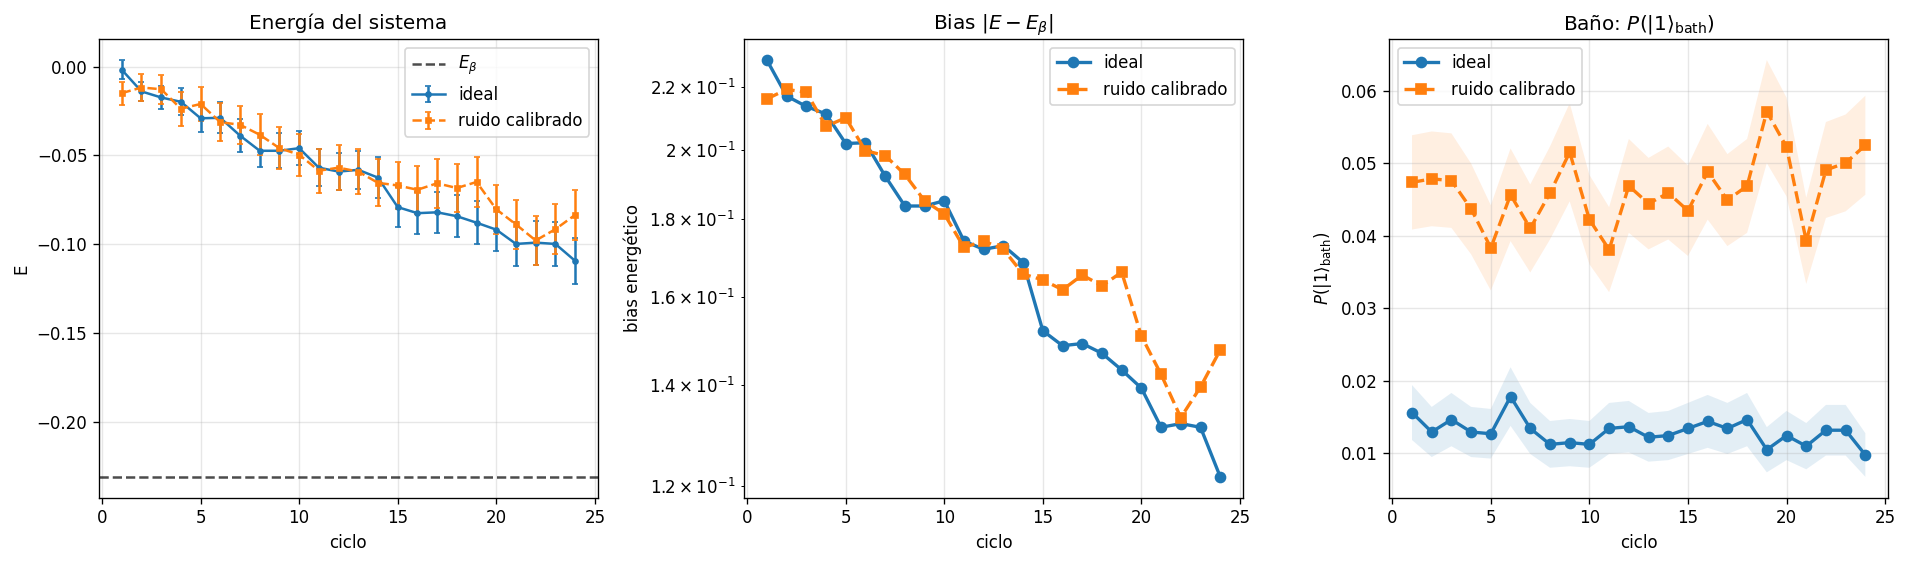

,cycle,E_ideal,E_noisy,bias_ideal,bias_noisy,bath_ideal,bath_noisy
0,1,-0.001709,-0.014893,0.229350,0.216166,0.015625,0.047363
1,2,-0.013916,-0.011719,0.217143,0.219340,0.012939,0.047852
2,3,-0.017334,-0.012695,0.213725,0.218363,0.014648,0.047607
3,4,-0.019775,-0.023682,0.211283,0.207377,0.012939,0.043701
4,5,-0.029053,-0.020996,0.202006,0.210062,0.012695,0.038330
5,6,-0.028809,-0.031250,0.202250,0.199809,0.017822,0.045654
6,7,-0.038818,-0.032715,0.192240,0.198344,0.013428,0.041016
7,8,-0.047363,-0.038330,0.183695,0.192729,0.011230,0.045898
8,9,-0.047363,-0.045898,0.183695,0.185160,0.011475,0.051514
9,10,-0.045898,-0.049561,0.185160,0.181498,0.011230,0.042236


In [20]:
# ============================================================
# D.1 — trayectorias ideal vs ruido calibrado
# ============================================================

d_params = dict(
    qk_params_good,
    theta=0.20,
    MT=15,
    n_cycles=24,
    randomize=False,
    rewind=False,
)

_, compiled_D = make_compiled_single_spin(d_params)

shots_D = 4096
cycles_D = np.arange(1, d_params["n_cycles"] + 1)

# Señal del baño con un circuito largo
bath_ideal_D = run_isa_dynamic_shots(
    compiled_D,
    n_cycles=d_params["n_cycles"],
    shots=shots_D,
    init_mode="mm",
    final_basis="Z",
    sim_mode="ideal",
    seed_base=123,
)
bath_noisy_D = run_isa_dynamic_shots(
    compiled_D,
    n_cycles=d_params["n_cycles"],
    shots=shots_D,
    init_mode="mm",
    final_basis="Z",
    sim_mode="noisy",
    seed_base=456,
)

# Energía por ciclos truncando el circuito
energy_ideal_D = run_energy_vs_cycles_shots(
    compiled_D,
    max_cycles=d_params["n_cycles"],
    shots=shots_D,
    init_mode="mm",
    sim_mode="ideal",
    seed_base=2000,
)
energy_noisy_D = run_energy_vs_cycles_shots(
    compiled_D,
    max_cycles=d_params["n_cycles"],
    shots=shots_D,
    init_mode="mm",
    sim_mode="noisy",
    seed_base=3000,
)

rho_g_D = gibbs_state(compiled_D["Hs_mat"], d_params["beta"])
E_gibbs_D = float(np.real(np.trace(rho_g_D @ compiled_D["Hs_mat"])))

energy_ideal_D["bias"] = np.abs(energy_ideal_D["E_final"] - E_gibbs_D)
energy_noisy_D["bias"] = np.abs(energy_noisy_D["E_final"] - E_gibbs_D)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Energía
axes[0].errorbar(
    energy_ideal_D["cycle"], energy_ideal_D["E_final"], yerr=1.96 * energy_ideal_D["E_sigma"],
    fmt="o-", ms=3, capsize=2, lw=1.5, label="ideal"
)
axes[0].errorbar(
    energy_noisy_D["cycle"], energy_noisy_D["E_final"], yerr=1.96 * energy_noisy_D["E_sigma"],
    fmt="s--", ms=3, capsize=2, lw=1.5, label="ruido calibrado"
)
axes[0].axhline(E_gibbs_D, ls="--", color="k", alpha=0.7, label=r"$E_\beta$")
axes[0].set_title("Energía del sistema")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel("E")
axes[0].legend()

# Bias energético
axes[1].plot(energy_ideal_D["cycle"], energy_ideal_D["bias"], "o-", lw=2, label="ideal")
axes[1].plot(energy_noisy_D["cycle"], energy_noisy_D["bias"], "s--", lw=2, label="ruido calibrado")
axes[1].set_title(r"Bias $|E - E_\beta|$")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel("bias energético")
axes[1].set_yscale("log")
axes[1].legend()

# Baño
axes[2].plot(cycles_D, bath_ideal_D["bath_p1"], "o-", lw=2, label="ideal")
axes[2].plot(cycles_D, bath_noisy_D["bath_p1"], "s--", lw=2, label="ruido calibrado")
axes[2].fill_between(cycles_D, bath_ideal_D["bath_lo95"], bath_ideal_D["bath_hi95"], alpha=0.12)
axes[2].fill_between(cycles_D, bath_noisy_D["bath_lo95"], bath_noisy_D["bath_hi95"], alpha=0.12)
axes[2].set_title(r"Baño: $P(|1\rangle_{\rm bath})$")
axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$P(|1\rangle_{\rm bath})$")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

df_D_traj = pd.DataFrame({
    "cycle": energy_ideal_D["cycle"],
    "E_ideal": energy_ideal_D["E_final"],
    "E_noisy": energy_noisy_D["E_final"],
    "bias_ideal": energy_ideal_D["bias"],
    "bias_noisy": energy_noisy_D["bias"],
    "bath_ideal": bath_ideal_D["bath_p1"],
    "bath_noisy": bath_noisy_D["bath_p1"],
})
display(df_D_traj.round(6))

La señal del baño $P_r(|1\rangle_B)$ mide el flujo de energía en ese ciclo, no el estado acumulado: el baño parte en $|0\rangle$, interacciona con el sistema durante el ciclo y se mide antes del reset, así que sube cuanto más caliente esté el sistema y se aplana cuando este se acerca a Gibbs.

Bajo el ruido calibrado de `FakeSherbrooke` (panel derecho), los errores de puerta y readout introducen un suelo en $P_r(|1\rangle_B)$ mayor que la propia señal física del cooling. El baño deja de ser un observable interpretable; la energía del sistema, en cambio, sí resiste, porque es una medida final acumulada y no un flujo por ciclo.


### D.1.2 Mapa operativo: sesgo ideal frente a ruido calibrado

Resumimos el efecto del ruido en el plano $(\theta, r)$, donde $r$ es el número de ciclos. Para cada $\theta$ computamos:

- el **bias energético ideal**, $|E^{\rm ideal}_r - E_\beta|$;
- el **bias con ruido calibrado**, $|E^{\rm noisy}_r - E_\beta|$;
- y su **ratio**, que mide cuánto peor rinde el protocolo con el ruido del backend.

La región útil queda definida por ratio cercano a 1. Cuando el ratio crece indefinidamente, el ruido domina y el protocolo deja de mejorar al añadir ciclos.

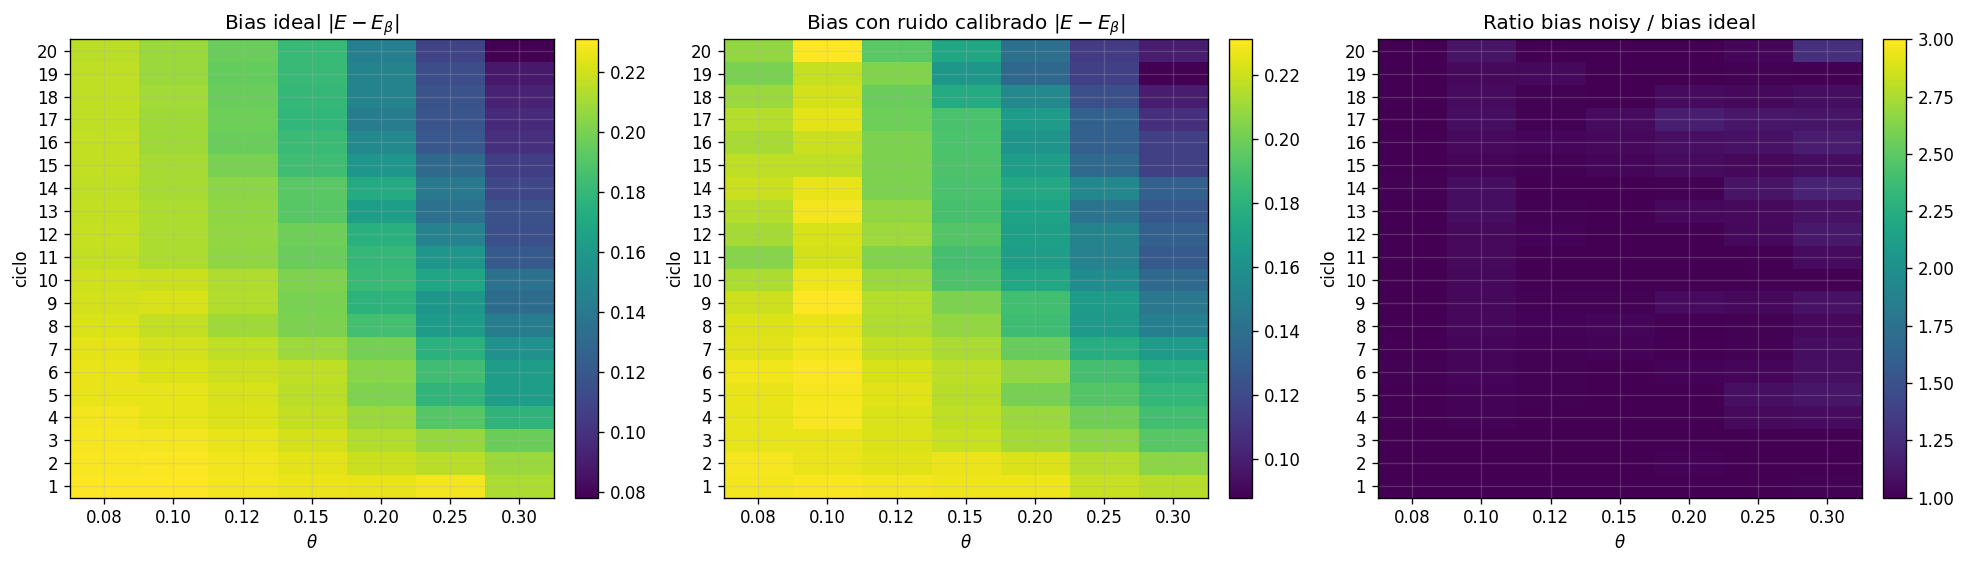

,theta,best_cycle_ideal,best_bias_ideal,best_cycle_noisy,best_bias_noisy,ratio_at_best_noisy
0,0.08,20,0.215189,19,0.202494,0.935696
1,0.10,19,0.207865,15,0.217631,1.030043
2,0.12,19,0.195170,20,0.194437,0.992523
3,0.15,17,0.179545,19,0.163920,0.901937
4,0.20,17,0.142191,19,0.136576,0.933268
5,0.25,20,0.109721,20,0.113627,1.035602
6,0.30,20,0.078227,19,0.087992,0.991745


In [21]:
# ============================================================
# DA.2 — mapa operativo con ruido calibrado (bias energético)
# ============================================================
# Para cada theta y cada ciclo computamos el bias |E - E_beta| en 
# ideal y en ruido calibrado. El ratio bias_noisy / bias_ideal mide 
# cuánto rendimiento pierde el protocolo al añadir el ruido del backend.

theta_grid_D = np.array([0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30], dtype=float)
max_cycles_D_map = 20
shots_D_map = 4096

BiasIdeal_map_D = np.zeros((max_cycles_D_map, len(theta_grid_D)), dtype=float)
BiasNoisy_map_D = np.zeros_like(BiasIdeal_map_D)
Ratio_map_D    = np.zeros_like(BiasIdeal_map_D)

rows_D_map = []

for j, theta in enumerate(theta_grid_D):
    pars_theta = dict(d_params, theta=float(theta), n_cycles=max_cycles_D_map)
    _, compiled_theta = make_compiled_single_spin(pars_theta)

    rho_g = gibbs_state(compiled_theta["Hs_mat"], pars_theta["beta"])
    E_g = float(np.real(np.trace(rho_g @ compiled_theta["Hs_mat"])))

    df_ideal = run_energy_vs_cycles_shots(
        compiled_theta, max_cycles=max_cycles_D_map, shots=shots_D_map,
        init_mode="mm", sim_mode="ideal",
        seed_base=1000 + 10 * j,
    )
    df_noisy = run_energy_vs_cycles_shots(
        compiled_theta, max_cycles=max_cycles_D_map, shots=shots_D_map,
        init_mode="mm", sim_mode="noisy",
        seed_base=5000 + 10 * j,
    )

    bias_ideal = np.abs(df_ideal["E_final"].values - E_g)
    bias_noisy = np.abs(df_noisy["E_final"].values - E_g)

    # floor pequeño para evitar explosiones artificiales del ratio
    floor = 5e-3
    ratio = bias_noisy / np.maximum(bias_ideal, floor)

    BiasIdeal_map_D[:, j] = bias_ideal
    BiasNoisy_map_D[:, j] = bias_noisy
    Ratio_map_D[:, j]     = ratio

    idx_best_ideal = int(np.argmin(bias_ideal))
    idx_best_noisy = int(np.argmin(bias_noisy))

    rows_D_map.append({
        "theta":              float(theta),
        "best_cycle_ideal":   idx_best_ideal + 1,
        "best_bias_ideal":    float(bias_ideal[idx_best_ideal]),
        "best_cycle_noisy":   idx_best_noisy + 1,
        "best_bias_noisy":    float(bias_noisy[idx_best_noisy]),
        "ratio_at_best_noisy": float(ratio[idx_best_noisy]),
    })

df_D_map = pd.DataFrame(rows_D_map)

# ---- figura: tres paneles (bias ideal, bias noisy, ratio) ----
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

im0 = axes[0].imshow(BiasIdeal_map_D, aspect="auto", origin="lower")
axes[0].set_title(r"Bias ideal $|E - E_\beta|$")

im1 = axes[1].imshow(BiasNoisy_map_D, aspect="auto", origin="lower")
axes[1].set_title(r"Bias con ruido calibrado $|E - E_\beta|$")

# vmax acotado: ratios > 3 se saturan para que el gradiente útil se vea
im2 = axes[2].imshow(Ratio_map_D, aspect="auto", origin="lower", vmin=1, vmax=3)
axes[2].set_title(r"Ratio bias noisy / bias ideal")

for ax, im in zip(axes, [im0, im1, im2]):
    ax.set_xticks(range(len(theta_grid_D)))
    ax.set_xticklabels([f"{x:.2f}" for x in theta_grid_D])
    ax.set_yticks(range(max_cycles_D_map))
    ax.set_yticklabels(range(1, max_cycles_D_map + 1))
    ax.set_xlabel(r"$\theta$"); ax.set_ylabel("ciclo")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

display(df_D_map.round(6))

## D.2 Ruido artificial controlado

El ruido calibrado es realista, pero no permite variar de forma independiente la intensidad del error. Por eso añadimos un stress-test artificial con tres niveles de ruido: mild, mid y high. Este bloque no pretende modelar un dispositivo concreto, sino identificar hasta qué nivel de ruido la señal térmica sigue siendo visible.

### D.2.1 Definición de los modelos mild, mid y high

En este bloque sustituimos el ruido calibrado del backend por modelos depolarizantes artificiales. Esto permite variar la intensidad del error de forma controlada y separar dos preguntas:

1. si el protocolo ideal tiene una señal térmica suficientemente clara;
2. hasta qué nivel de ruido instrumental esa señal sigue siendo visible.

Usamos tres niveles:

- `mild`: ruido débil, pensado como perturbación pequeña del circuito ideal;
- `mid`: ruido intermedio, donde la degradación debería ser visible pero no necesariamente destructiva;
- `high`: ruido fuerte, usado como stress-test.

Estos modelos no representan un dispositivo concreto. Su función es operativa: comprobar la robustez de la señal frente a degradación creciente.

### D.2.2 Trayectorias bajo ruido artificial

Para cada nivel de ruido comparamos la evolución de la energía, la distancia traza a Gibbs y la penalización relativa respecto al circuito ideal. La comparación se hace con los mismos parámetros físicos y el mismo número de ciclos, cambiando únicamente el modelo de ruido.

La magnitud más importante no es solo el valor final, sino si la trayectoria conserva la dirección correcta de enfriamiento y si existe una ventana de ciclos antes de que el ruido domine.

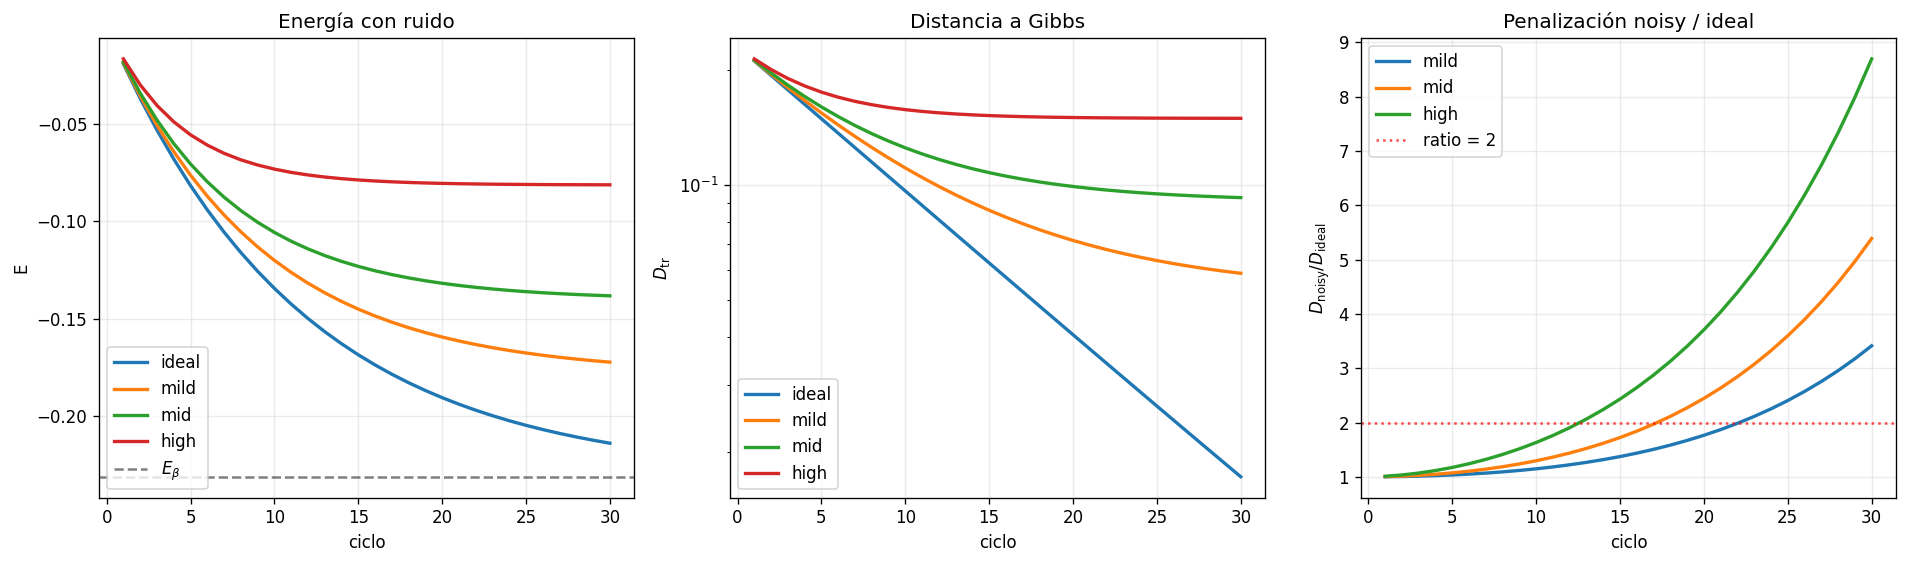

,noise_level,E_final,D_final,D_min,cycle_best
0,ideal,-0.213836,0.017222,0.017222,30
1,mild,-0.172272,0.058787,0.058787,30
2,mid,-0.138257,0.092802,0.092802,30
3,high,-0.081326,0.149733,0.149733,30


In [50]:
# ============================================================
# D.1 — trayectorias con ruido
# ============================================================

noise_configs = {
    "ideal": None,
    "mild": make_depol_noise(0.001, 0.01),
    "mid":  make_depol_noise(0.003, 0.02),
    "high": make_depol_noise(0.010, 0.05),
}

noise_runs = {}
rows_noise = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for label, noise_model in noise_configs.items():
    summary = noisy_run_summary(
        qk_params_noise,
        rho0=maximally_mixed(1),
        noise_model=noise_model,
    )
    noise_runs[label] = summary

    cycles = np.arange(1, len(summary["energies"]) + 1)
    axes[0].plot(cycles, summary["energies"], lw=2, label=label)
    axes[1].plot(cycles, summary["trace_dists"], lw=2, label=label)

    rows_noise.append({
        "noise_level": label,
        "E_final": summary["E_final"],
        "D_final": summary["D_final"],
        "D_min": summary["D_min"],
        "cycle_best": summary["cycle_best"],
    })

ideal_D = noise_runs["ideal"]["trace_dists"]
for label in ["mild", "mid", "high"]:
    ratio = noise_runs[label]["trace_dists"] / np.maximum(ideal_D, 1e-6)
    axes[2].plot(np.arange(1, len(ratio) + 1), ratio, lw=2, label=label)

axes[0].axhline(noise_runs["ideal"]["E_gibbs"], ls="--", color="k", alpha=0.5, label=r"$E_\beta$")
axes[0].set_title("Energía con ruido")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel("E")
axes[0].legend()

axes[1].set_title("Distancia a Gibbs")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}$")
axes[1].set_yscale("log")
axes[1].legend()

axes[2].axhline(2.0, ls=":", color="red", alpha=0.7, label="ratio = 2")
axes[2].set_title("Penalización noisy / ideal")
axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$D_{\rm noisy}/D_{\rm ideal}$")
axes[2].legend()

plt.tight_layout()
plt.show()

df_noise_summary = pd.DataFrame(rows_noise)
display(df_noise_summary.round(8))


El ruido artificial confirma la jerarquía esperada. En el régimen `mild`, la dinámica sigue cerca del caso ideal y la señal térmica permanece interpretable. En el régimen `mid`, la preparación se degrada pero todavía puede existir una ventana útil de ciclos. En el régimen `high`, la penalización respecto al caso ideal crece y el ruido empieza a competir directamente con la señal de enfriamiento.

La conclusión no es que el protocolo sea robusto a cualquier ruido, sino que existe una ventana operativa: para ruido moderado y número de ciclos no excesivo, la dirección de thermalización sigue siendo visible. Esto complementa el ruido calibrado de D.1, porque aquí la intensidad del error se controla explícitamente.

## D.3 Conclusiones de la capa con ruido

El ruido calibrado muestra el comportamiento esperable en un backend realista, mientras que el ruido artificial permite separar robustez física y degradación instrumental. En ambos casos, el objetivo no es obtener una preparación perfecta, sino comprobar si la dirección de enfriamiento y la señal térmica siguen siendo distinguibles frente al ruido.